# Test Counterfactual performance

In this notebook, we test CLUE's performance for 3 different setups of a Bayesian last-layer MNIST classifier. 

We allow a choice between:
- Classifier dominated backbone 
- Joint training backbone
- Autoencoder dominated backbone

## Setup


In [1]:
inDrive = False

In [2]:
import sys
import os

if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks')

# Get current directory and parent directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Add parent directory to path if not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Import libraries

In [3]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

import models.BLL
import models.mnist_classifier_BLL
import train
import sampler
import models.regene_models


Set the configuration

In [4]:
# 1. Configuration
class Config:
    # Data
    batch_size = 512
    latent_dim = 256

    # Hardware
    device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'

    train=False

cfg = Config()

In [49]:
models_dir = '../model_saves/new_regene_models'
results_dir = '../results/new_regene_models'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

## Backbone
We'll start with the backbone loading. Options are either classifier_dominated, joint_training, or autoencoder_dominated.

In [6]:
classifier_dominated = False
joint_training = True
autoencoder_dominated = False

### Load chosen model

Load model

In [7]:
importlib.reload(models.regene_models)

models_dir = "../model_saves/new_regene_models"

decoder = models.regene_models.Decoder(latent_dim=cfg.latent_dim, device=cfg.device)
backbone = models.regene_models.Classifier(latent_dim=cfg.latent_dim, num_classes=10, device=cfg.device)

if classifier_dominated:
    backbone.load(models_dir + '/classifier_dominated_classifier_256.pt')
    decoder.load(models_dir + '/classifier_dominated_decoder_256.pt')
    name = 'classifier_dominated'
    bll_name = 'BLL_VI_classifier_dominated_first_256.pt'
elif joint_training:
    backbone.load(os.path.join(models_dir, 'joint_classifier_256.pt'))
    decoder.load(os.path.join(models_dir, 'joint_decoder_256.pt'))
    name = 'joint_training'
    bll_name = 'BLL_VI_joint_training_first_256.pt'
elif autoencoder_dominated:
    backbone.load(models_dir + '/autoencoder_dominated_classifier_full_256.pt')
    decoder.load(models_dir + '/autoencoder_dominated_decoder_256.pt')
    name = 'autoencoder_dominated'
    bll_name = 'BLL_VI_autoencoder_dominated_first_256.pt'

Loaded classifier model from: ../model_saves/new_regene_models/joint_classifier_256.pt
Loaded decoder model from: ../model_saves/new_regene_models/joint_decoder_256.pt


Load the Datasets

In [8]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Split training set into train and validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

Create a models and results directory if it doesn't exist

## Bayesian Last Layer - VI
Next we'll train a variational inference version of the Bayesian last layer using the chosen backbone.


In [9]:
if inDrive: 
    %pip install torchbnn 

### Load the model

In [50]:
from models.BLL_VI import BayesianLastLayerVI
importlib.reload(models.BLL_VI)

import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

bll_vi = BayesianLastLayerVI(
    backbone=backbone,
    input_dim=cfg.latent_dim,  # Matches backbone's encoder output
    output_dim=10,  # MNIST classes
    device=cfg.device
)

# Verify all model components are on the correct device
print(f"Backbone device: {next(bll_vi.backbone.parameters()).device}")
print(f"Last layer device: {next(bll_vi.last_layer.parameters()).device}")

bll_vi.load_checkpoint(os.path.join(models_dir, bll_name))

Backbone device: mps:0
Last layer device: mps:0
 [load_checkpoint] Loaded checkpoint from ../model_saves/new_regene_models/BLL_VI_joint_training_first_256.pt


### Test the model
To check for Bayesian behaviour, we find an uncertain prediction and visualize multiple samples from the posterior.


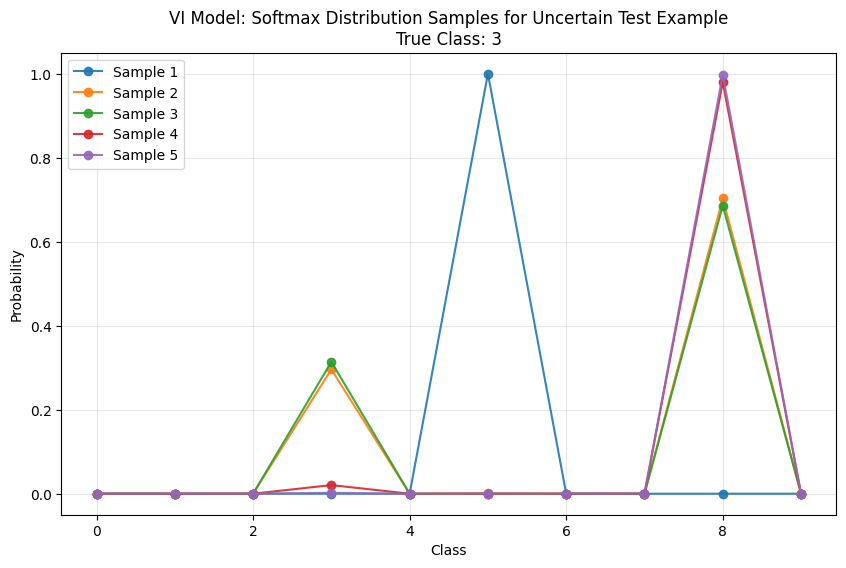

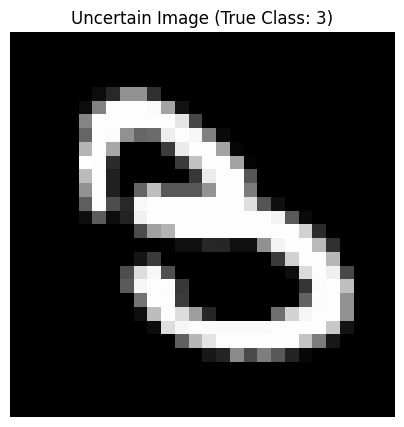

In [11]:
import torch.nn.functional as F

# Search for an uncertain prediction and visualize multiple samples
test_iter = iter(testloader)
found_uncertain = False
max_tries = 100
num_samples = 5

try:
    while not found_uncertain:
        x, y = next(test_iter)
        # Look at each example in the batch
        for i in range(len(x)):
            x_single = x[i:i+1]
            y_single = y[i:i+1]

            # Get multiple predictions for this single example
            outputs = []
            with torch.no_grad():  # Add no_grad context
                for _ in range(num_samples):
                    logits = bll_vi(x_single)
                    probs = F.softmax(logits, dim=1)
                    outputs.append(probs)

            # Stack predictions
            probs = torch.stack(outputs)  # Shape: [num_samples, 1, num_classes]
            probs = probs.squeeze(1)  # Remove batch dimension -> [num_samples, num_classes]

            # Check if predictions are not all highly confident
            max_probs = probs.max(dim=1)[0]
            if max_probs.mean() < 0.9:  # If average confidence is less than 60%
                found_uncertain = True
                break

except StopIteration:
    if not found_uncertain:
        print("Could not find uncertain prediction in entire test set")

# Plot the softmax distributions
plt.figure(figsize=(10, 6))
x_axis = range(probs.shape[1])  # Range over number of classes

for i in range(num_samples):
    plt.plot(x_axis, probs[i].detach().cpu().numpy(), 'o-', alpha=0.9, label=f'Sample {i+1}')

plt.xlabel('Class')
plt.ylabel('Probability')
plt.title(f'VI Model: Softmax Distribution Samples for Uncertain Test Example\nTrue Class: {y_single.item()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display the uncertain image
plt.figure(figsize=(5, 5))
img = x_single.squeeze().cpu()
if img.shape[0] == 1:  # If grayscale, remove channel dimension
    img = img.squeeze(0)
plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
plt.axis('off')
plt.title(f'Uncertain Image (True Class: {y_single.item()})')
plt.show()

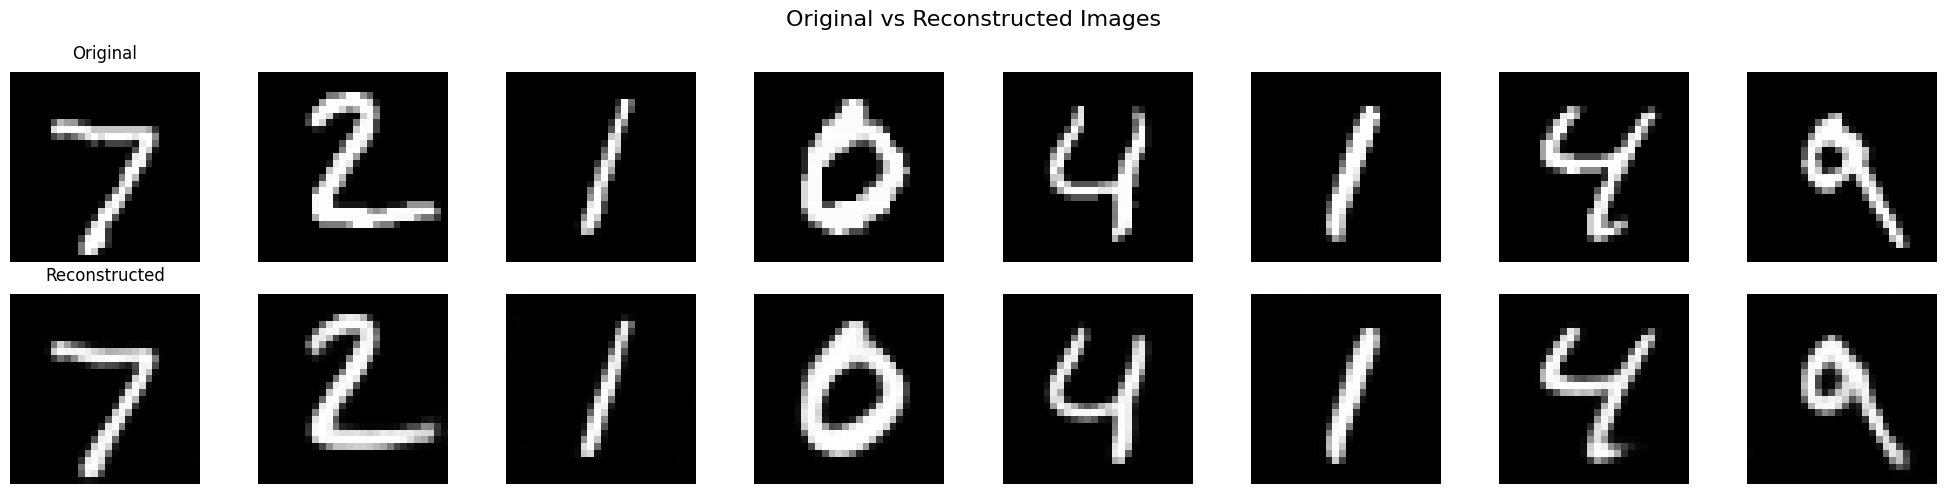

Reconstruction MSE: 0.0035


In [12]:
# Get test images
test_images, test_labels = next(iter(testloader))
test_images = test_images.to(cfg.device)

# Get reconstructions using the classifier and decoder
with torch.no_grad():
    # Get latent representations from classifier
    latent_reps, _ = backbone(test_images)  # Returns (latent_rep, logits)
    # Reconstruct using decoder
    reconstructions = decoder(latent_reps)

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Original vs Reconstructed Images', fontsize=16)

# Plot original images
for i in range(8):
    axes[0,i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')
    if i == 0:
        axes[0,i].set_title('Original', pad=10)

# Plot reconstructions
for i in range(8):
    axes[1,i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')
    if i == 0:
        axes[1,i].set_title('Reconstructed', pad=10)

plt.tight_layout()
plt.show()

# Optionally, calculate reconstruction error
mse = nn.MSELoss()
recon_error = mse(reconstructions, test_images)
print(f'Reconstruction MSE: {recon_error.item():.4f}')

## Load autoencoder

In [13]:
from models.mnist_conv_autoencoder import MNISTConvAutoencoder
importlib.reload(models.mnist_conv_autoencoder)

<module 'models.mnist_conv_autoencoder' from '/Users/conor/Documents/College terms/College/Thesis/ReportsAndCode/Bayesian-CE/MyImplementation/models/mnist_conv_autoencoder.py'>

In [14]:
autoencoder_save_path = os.path.join("../model_saves/new_regene_models", 'mnist_conv_autoencoder.pth')
print(autoencoder_save_path)
autoencoder = MNISTConvAutoencoder(device=cfg.device, model_save_path=autoencoder_save_path)

../model_saves/new_regene_models/mnist_conv_autoencoder.pth


In [15]:
if cfg.train:
    autoencoder.train_model(
        train_loader=trainloader,
        val_loader=valloader,
    num_epochs=20,
    lr=1e-3,
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

In [16]:
autoencoder.load_model()

Model loaded from ../model_saves/new_regene_models/mnist_conv_autoencoder.pth


MNISTConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=256, bias=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_dense): Sequential(
    (0): Linear(in_features=256, out_features=6272, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    

### Test autoencoder

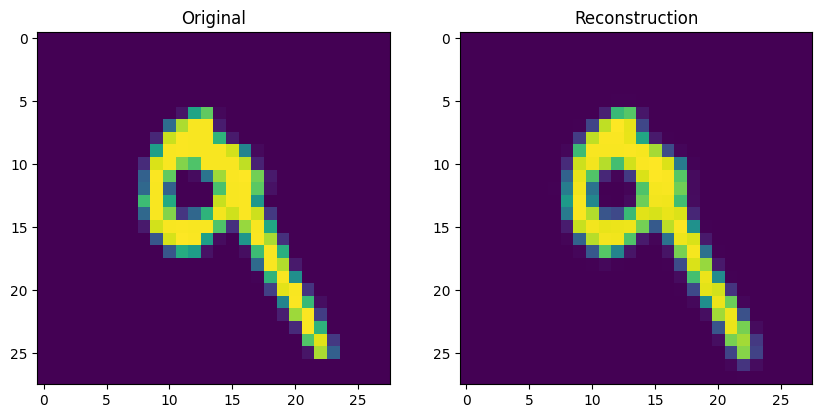

In [17]:
test_img, test_label = testloader.dataset[7]

with torch.no_grad():
    test_img = test_img.unsqueeze(0).to(cfg.device)
    z = autoencoder.encode(test_img)
    recon = autoencoder.decode(z)
    
    # Plot original vs reconstruction
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_img[0].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(recon[0].cpu().permute(1, 2, 0))
    plt.title("Reconstruction")
    plt.show()

## Evaluate CLUE

### Load the VAE

In [18]:
from models.VAE_likelihood import ConvVAELikelihoodEstimator

vae = ConvVAELikelihoodEstimator(latent_dim=20, device=cfg.device)

vae.load_state_dict(torch.load(os.path.join(models_dir, 'vae_likelihood_estimator_20.pt'), map_location=cfg.device))


<All keys matched successfully>

### Get Uncertain Images

In [34]:
import importlib
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_clue_counterfactuals, find_uncertain_images, visualize_counterfactual_results, evaluate_single_counterfactual

In [21]:
uncertain_images, uncertain_indices = find_uncertain_images(bll_vi, testloader, n=50, device=cfg.device)

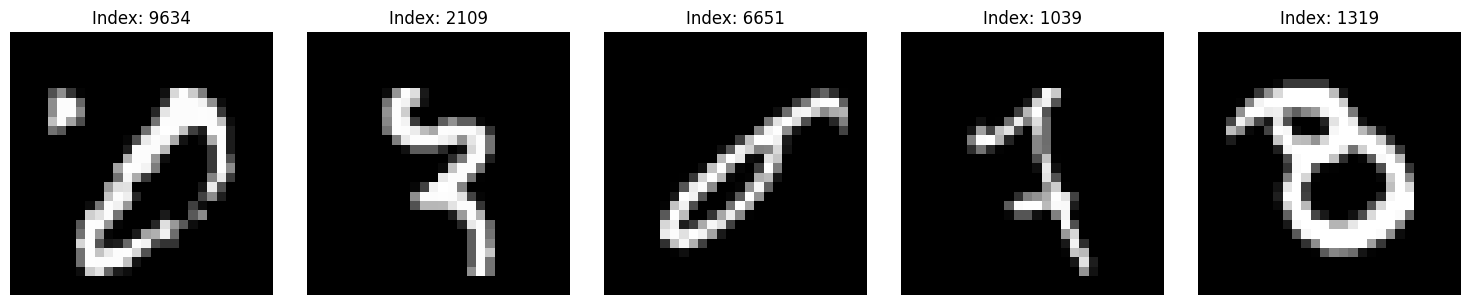

Uncertainty indices of these images: [9634, 2109, 6651, 1039, 1319]


In [22]:
# Plot the first 5 uncertain images
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(uncertain_images[i, 0].cpu(), cmap='gray')
    plt.title(f"Index: {uncertain_indices[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Uncertainty indices of these images:", uncertain_indices[:5].tolist())

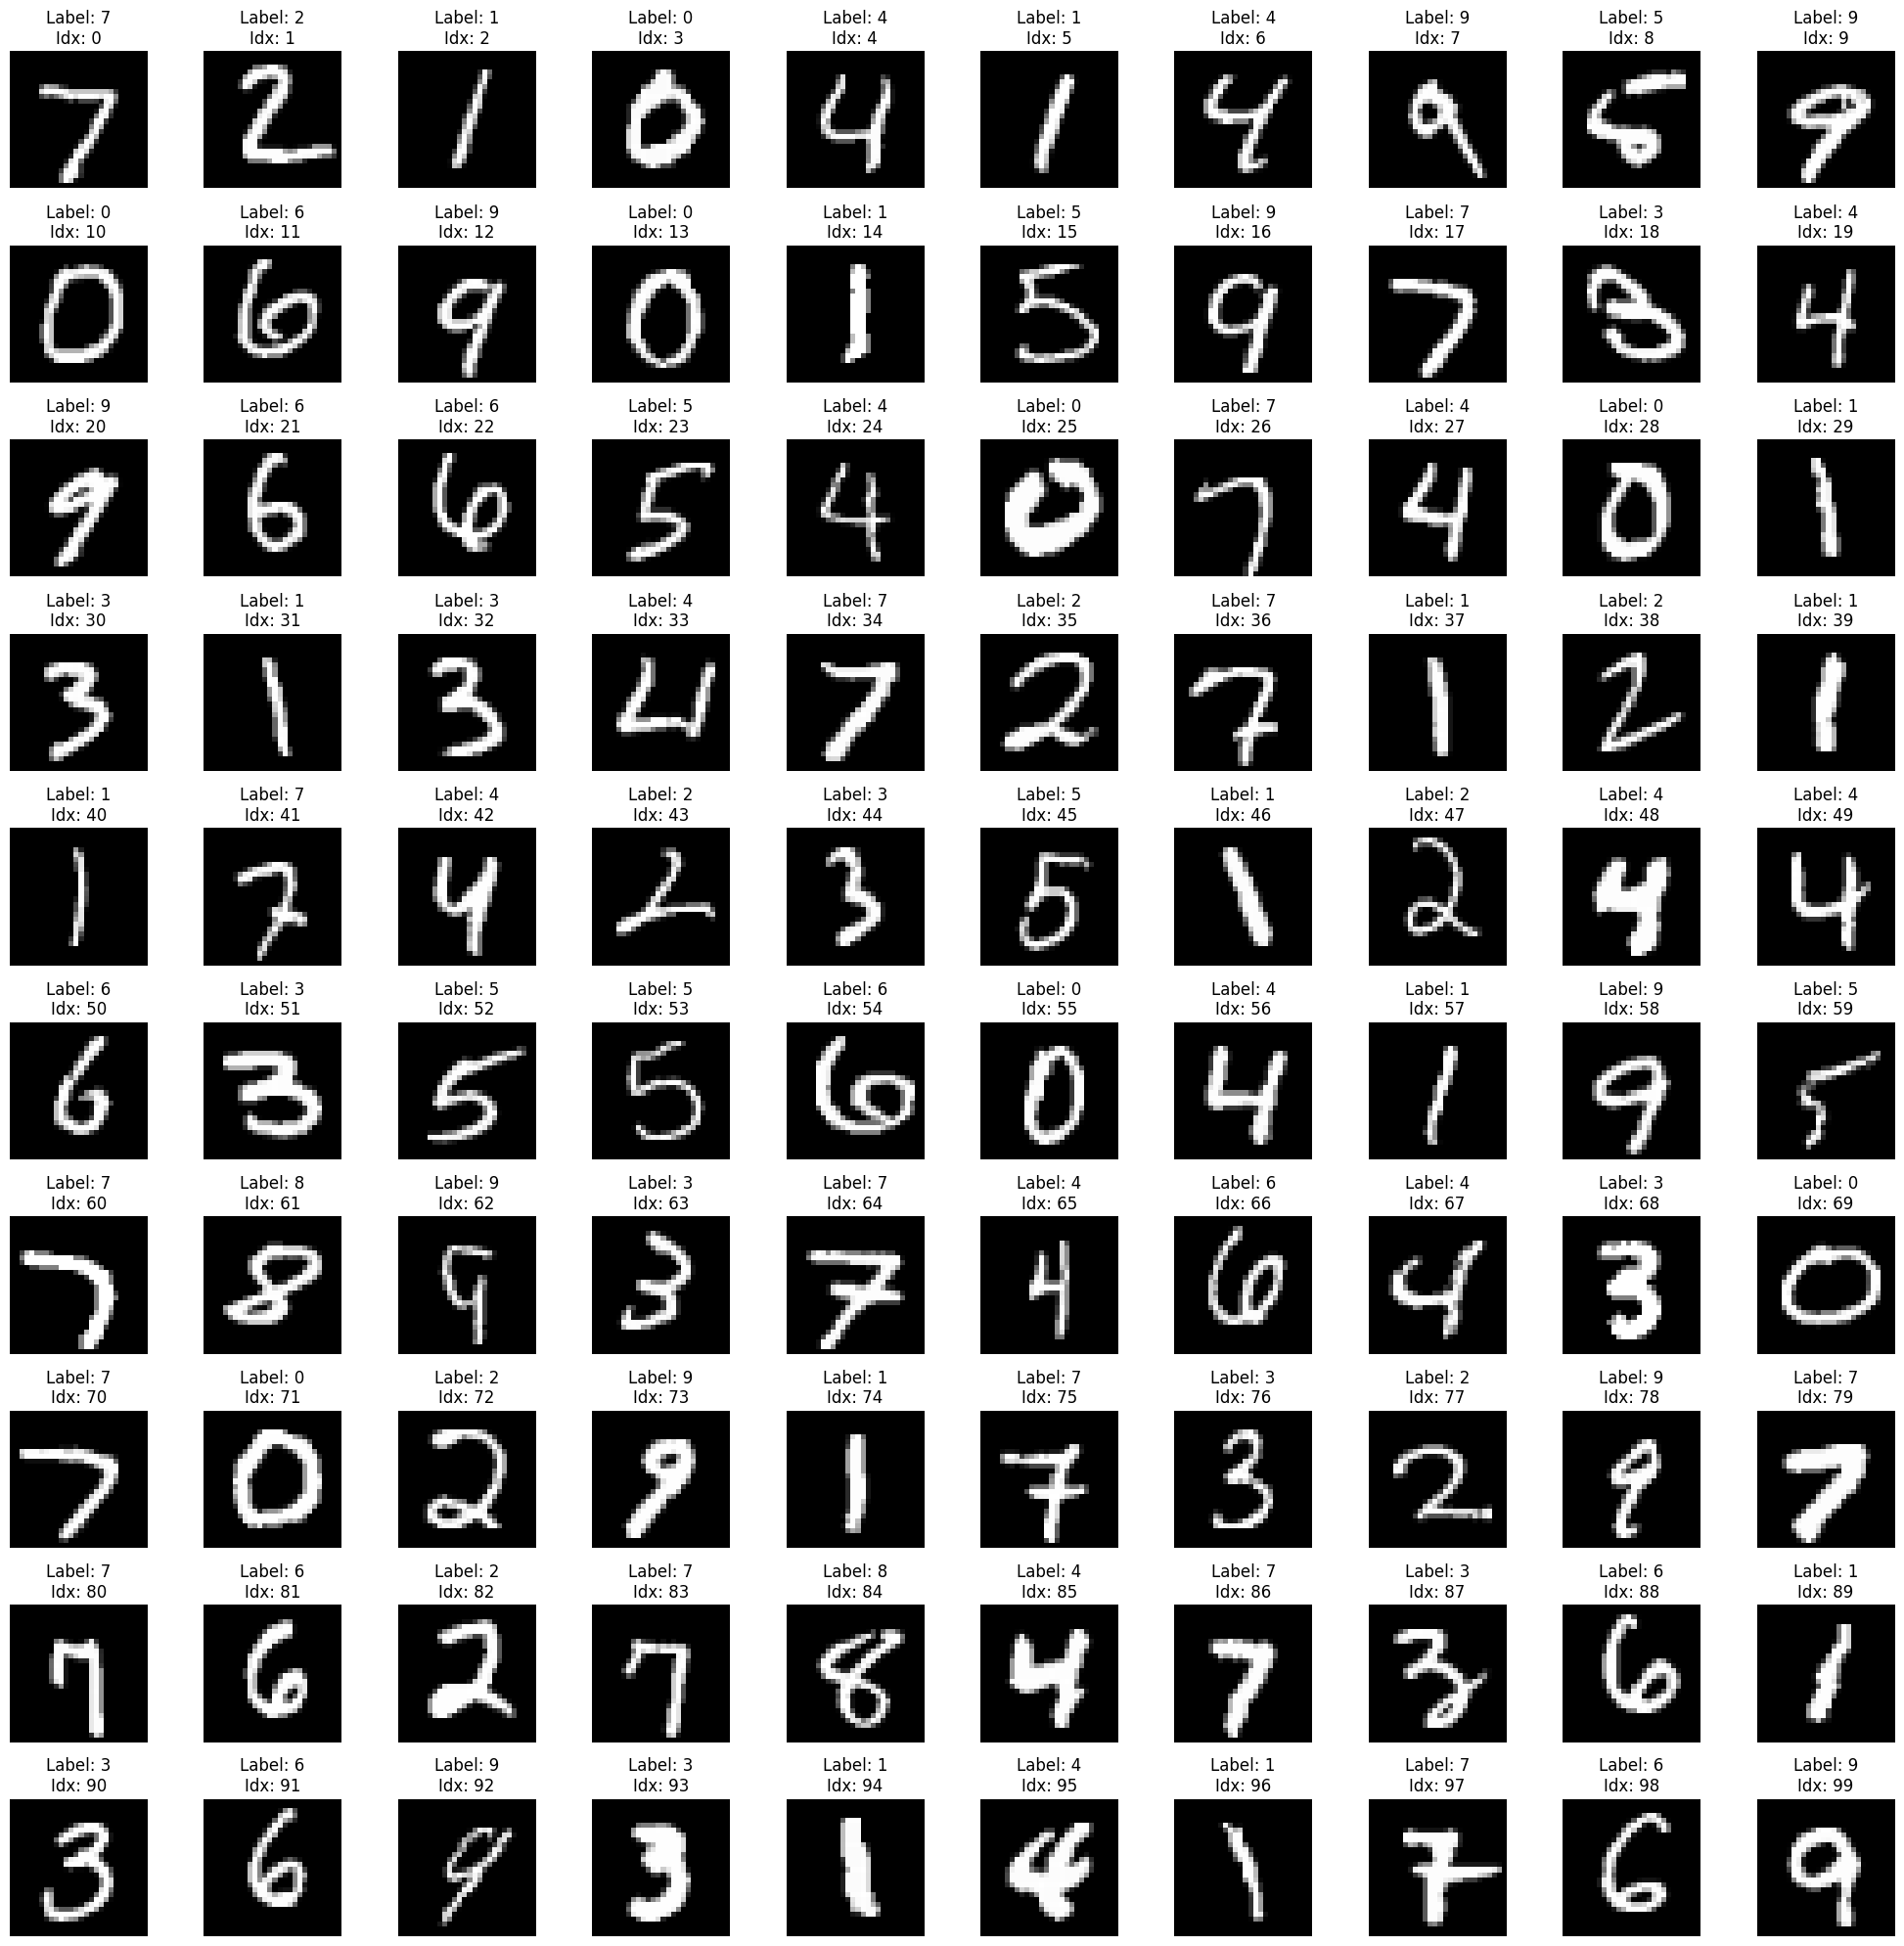

Displayed 100 images from the MNIST test dataset with their indices


In [45]:
# Show 100 images from the testset with their index
import matplotlib.pyplot as plt
import numpy as np
import torch

# Get 100 images from the testloader
images = []
labels = []
indices = []
count = 0

# Get a batch of images from the testloader
dataiter = iter(testloader)
batch_idx = 0
while count < 100:
    data, target = next(dataiter)
    batch_size = data.shape[0]
    num_to_take = min(batch_size, 100-count)
    images.append(data[:num_to_take])
    labels.append(target[:num_to_take])
    # Calculate the actual indices in the test set
    batch_indices = torch.arange(batch_idx * batch_size, batch_idx * batch_size + num_to_take)
    indices.append(batch_indices)
    count += num_to_take
    batch_idx += 1

# Concatenate all batches
images = torch.cat(images, dim=0)
labels = torch.cat(labels, dim=0)
indices = torch.cat(indices, dim=0)

# Create a grid of images
plt.figure(figsize=(20, 20))
for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.imshow(images[i, 0].cpu(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}\nIdx: {indices[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Displayed 100 images from the MNIST test dataset with their indices")


### Test a single image

Step 00: Loss: 20.6582, Target Class Prob: 0.0000, Distance: 0.0000
Step 01: Loss: 23.0261, Target Class Prob: 0.0000, Distance: 3.2000
Step 02: Loss: 22.9077, Target Class Prob: 0.0000, Distance: 5.3437
Step 03: Loss: 16.0147, Target Class Prob: 0.0000, Distance: 7.0090
Step 04: Loss: 23.0256, Target Class Prob: 0.0000, Distance: 8.2913
Step 05: Loss: 22.8608, Target Class Prob: 0.0000, Distance: 9.4942
Step 06: Loss: 21.3338, Target Class Prob: 0.0000, Distance: 10.6084
Step 07: Loss: 12.6312, Target Class Prob: 0.0000, Distance: 11.7696
Step 08: Loss: 16.9809, Target Class Prob: 0.0000, Distance: 12.8981
Step 09: Loss: 6.6351, Target Class Prob: 0.0013, Distance: 14.0710
Step 10: Loss: 8.5726, Target Class Prob: 0.0002, Distance: 15.3353
Step 11: Loss: 13.6548, Target Class Prob: 0.0000, Distance: 16.6232
Step 12: Loss: 11.1361, Target Class Prob: 0.0000, Distance: 17.9122
Step 13: Loss: 5.7444, Target Class Prob: 0.0032, Distance: 19.2496
Step 14: Loss: 9.3999, Target Class Prob: 0

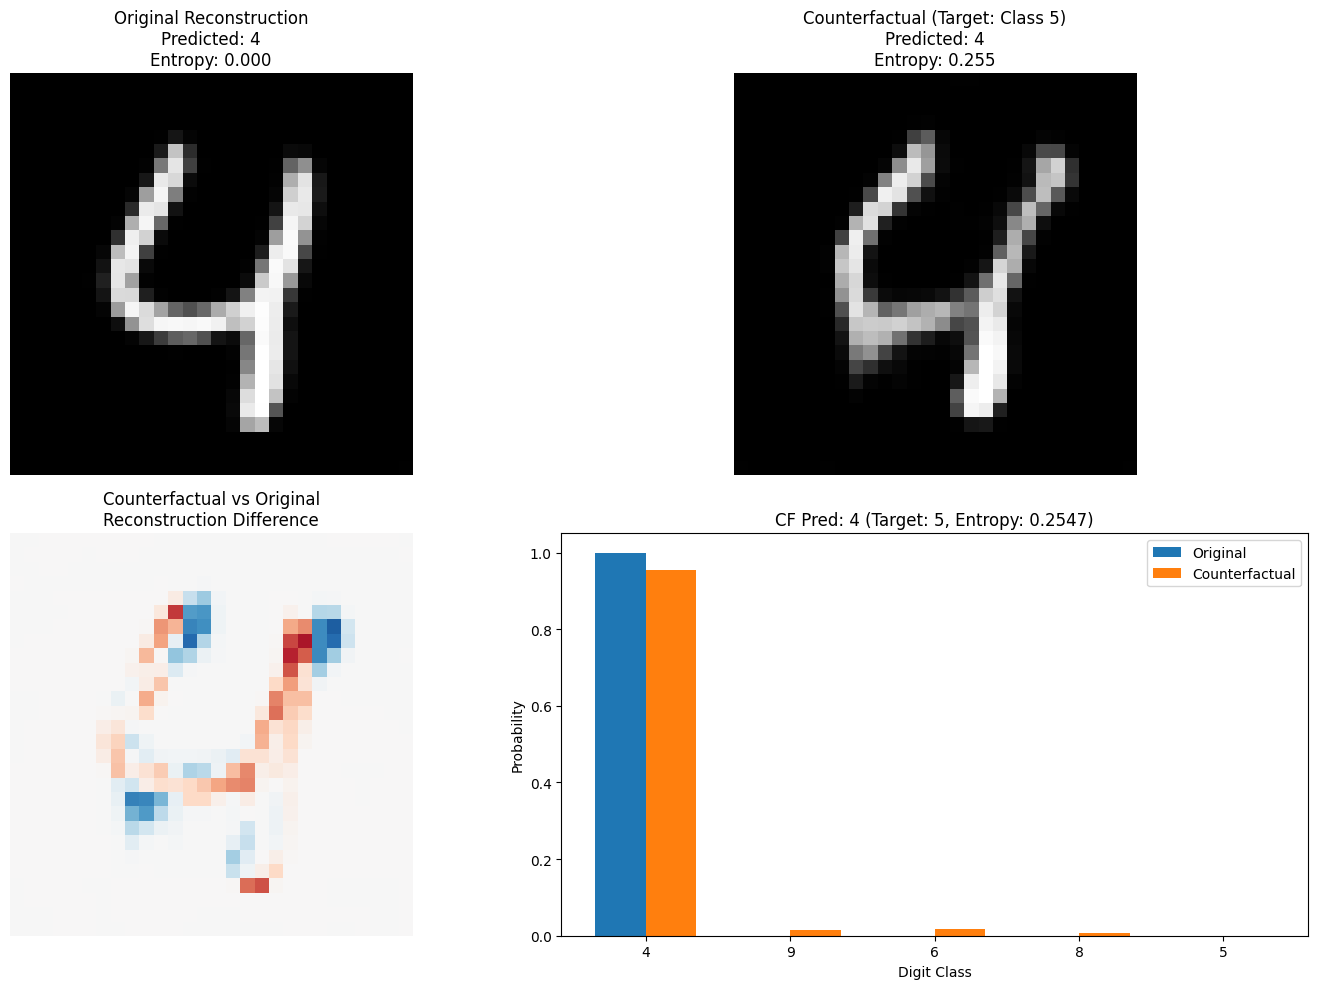


CLUE Counterfactual Results:
Latent Distance: 54.404
Latent Entropy Reduction: -0.189
Reconstruction Entropy Reduction: -0.255

Class probabilities:
Original (Predicted: 4): [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Counterfactual (Predicted: 4, Target: 5): [0.    0.004 0.005 0.    0.954 0.    0.017 0.    0.007 0.014]

Likelihood metrics:
Original log-likelihood: -89.00
Reconstruction log-likelihood: -93.21
Counterfactual log-likelihood: -122.47
Log-likelihood difference (original vs CF): 33.46
Log-likelihood difference (recon vs CF): 29.26
Likelihood ratio (CF/original): 0.00x
Likelihood ratio (CF/recon): 0.00x
Original realism score: 0.985
Reconstruction realism score: 0.984
Counterfactual realism score: 0.972
Realism score difference (original vs CF): 0.013
Realism score difference (recon vs CF): 0.012


In [51]:
import clue.counterfactual_optimizer
importlib.reload(clue.counterfactual_optimizer)

bayesian = True

if bayesian:
    model = bll_vi
else:
    model = backbone

image, label = testloader.dataset[4]

results, figure = evaluate_single_counterfactual(   
    image,
    model,
    decoder,
    vae,
    device=cfg.device,
    verbose=True,
    steps=200,
    distance_weight=0.0001,
    lr=0.2,
    target_class=5,
    bayesian=bayesian,
    ReconstructionOnly=True
)

### Get average metrics

In [ ]:
results = evaluate_clue_counterfactuals(
    uncertain_images[10:20],
    bll_vi,
    decoder,
    vae,
    device=cfg.device,
    steps=200,
    lr=0.05,
    distance_weight=0.005,
)

KeyboardInterrupt: 


Aggregate Results over 10 images:
Average latent entropy reduction: 1.360
Average reconstruction entropy reduction: 0.739
Average latent distance: 25.202
Average log likelihood difference: 9.543
Average realism score difference: 0.003


Example 1 (Image Index: 7):
Latent entropy reduction: 1.583
Latent distance: 31.666
Log likelihood difference: -14.819
Original class prediction: 9
Counterfactual class prediction: 9

Example 2 (Image Index: 2):
Latent entropy reduction: 1.475
Latent distance: 30.338
Log likelihood difference: 4.699
Original class prediction: 1
Counterfactual class prediction: 1

Example 3 (Image Index: 8):
Latent entropy reduction: 1.414
Latent distance: 25.127
Log likelihood difference: 20.361
Original class prediction: 9
Counterfactual class prediction: 9

Example 4 (Image Index: 1):
Latent entropy reduction: 1.394
Latent distance: 20.476
Log likelihood difference: 26.466
Original class prediction: 5
Counterfactual class prediction: 5

Example 5 (Image Index: 9):
La

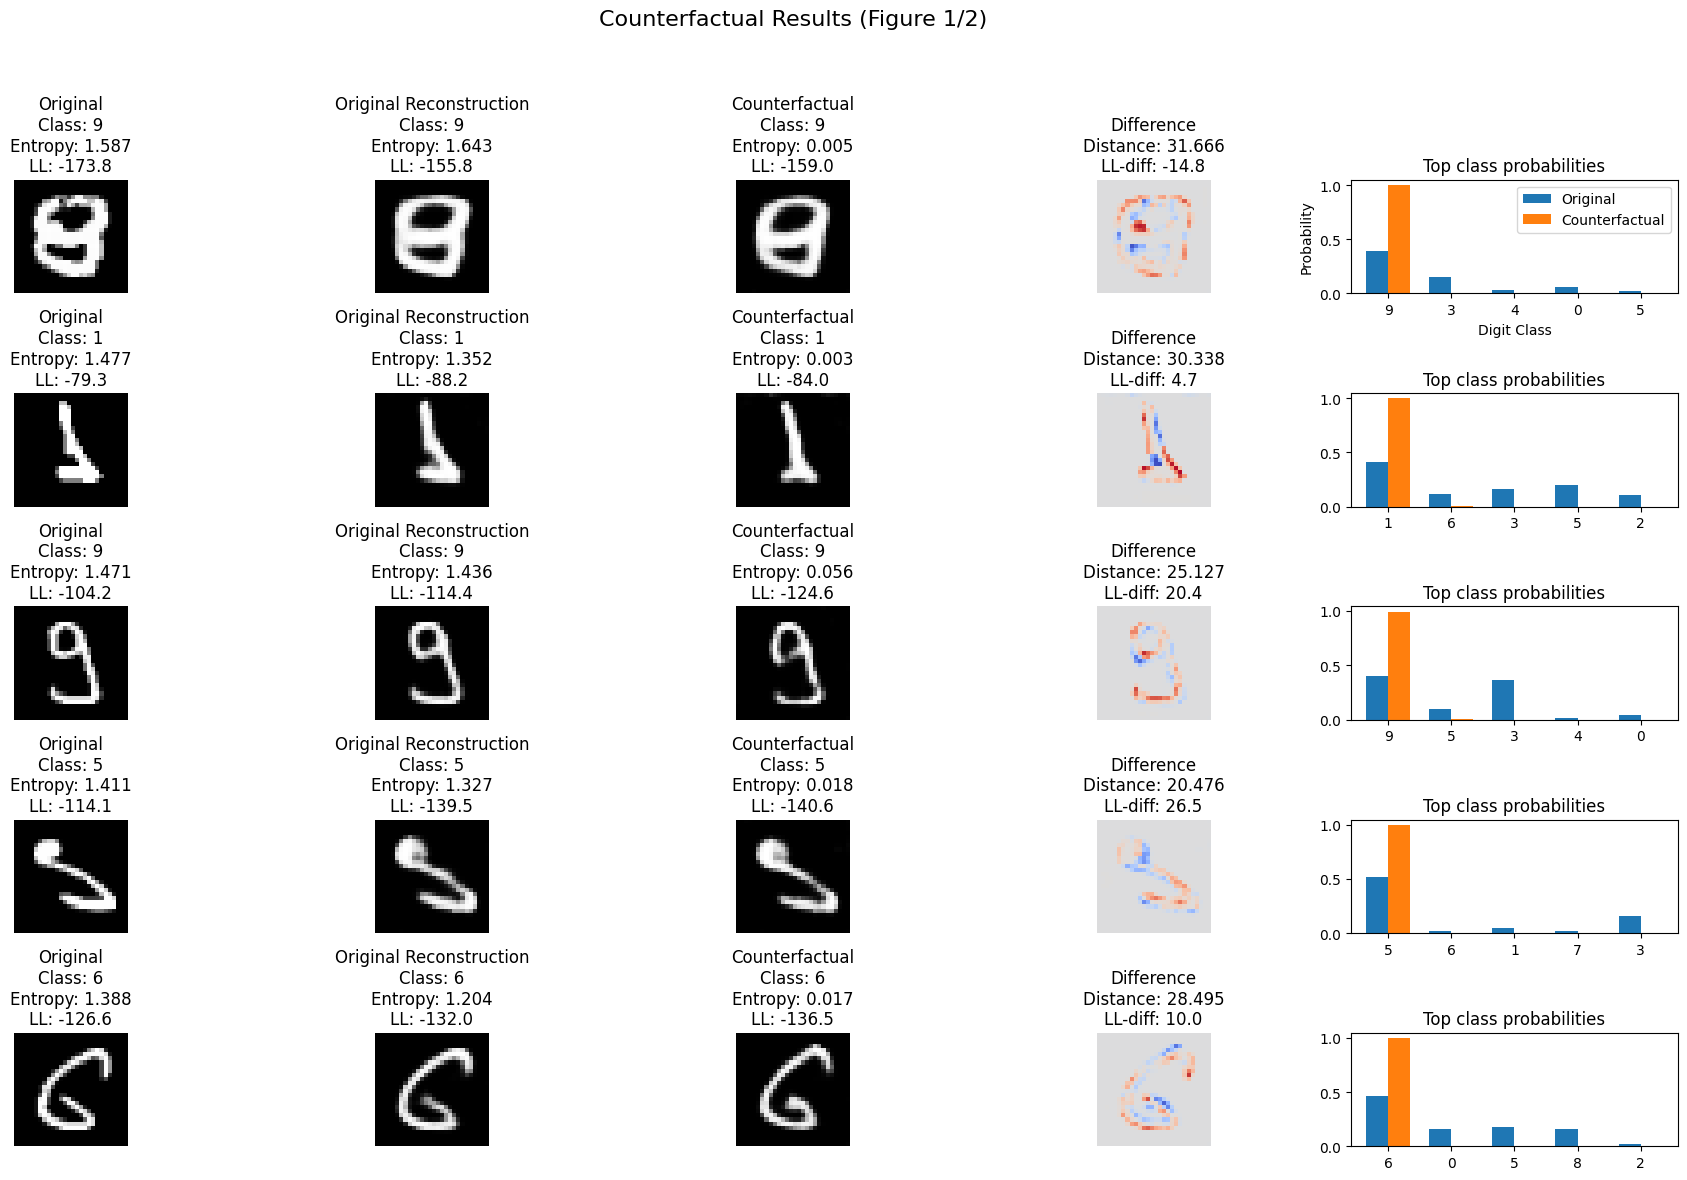

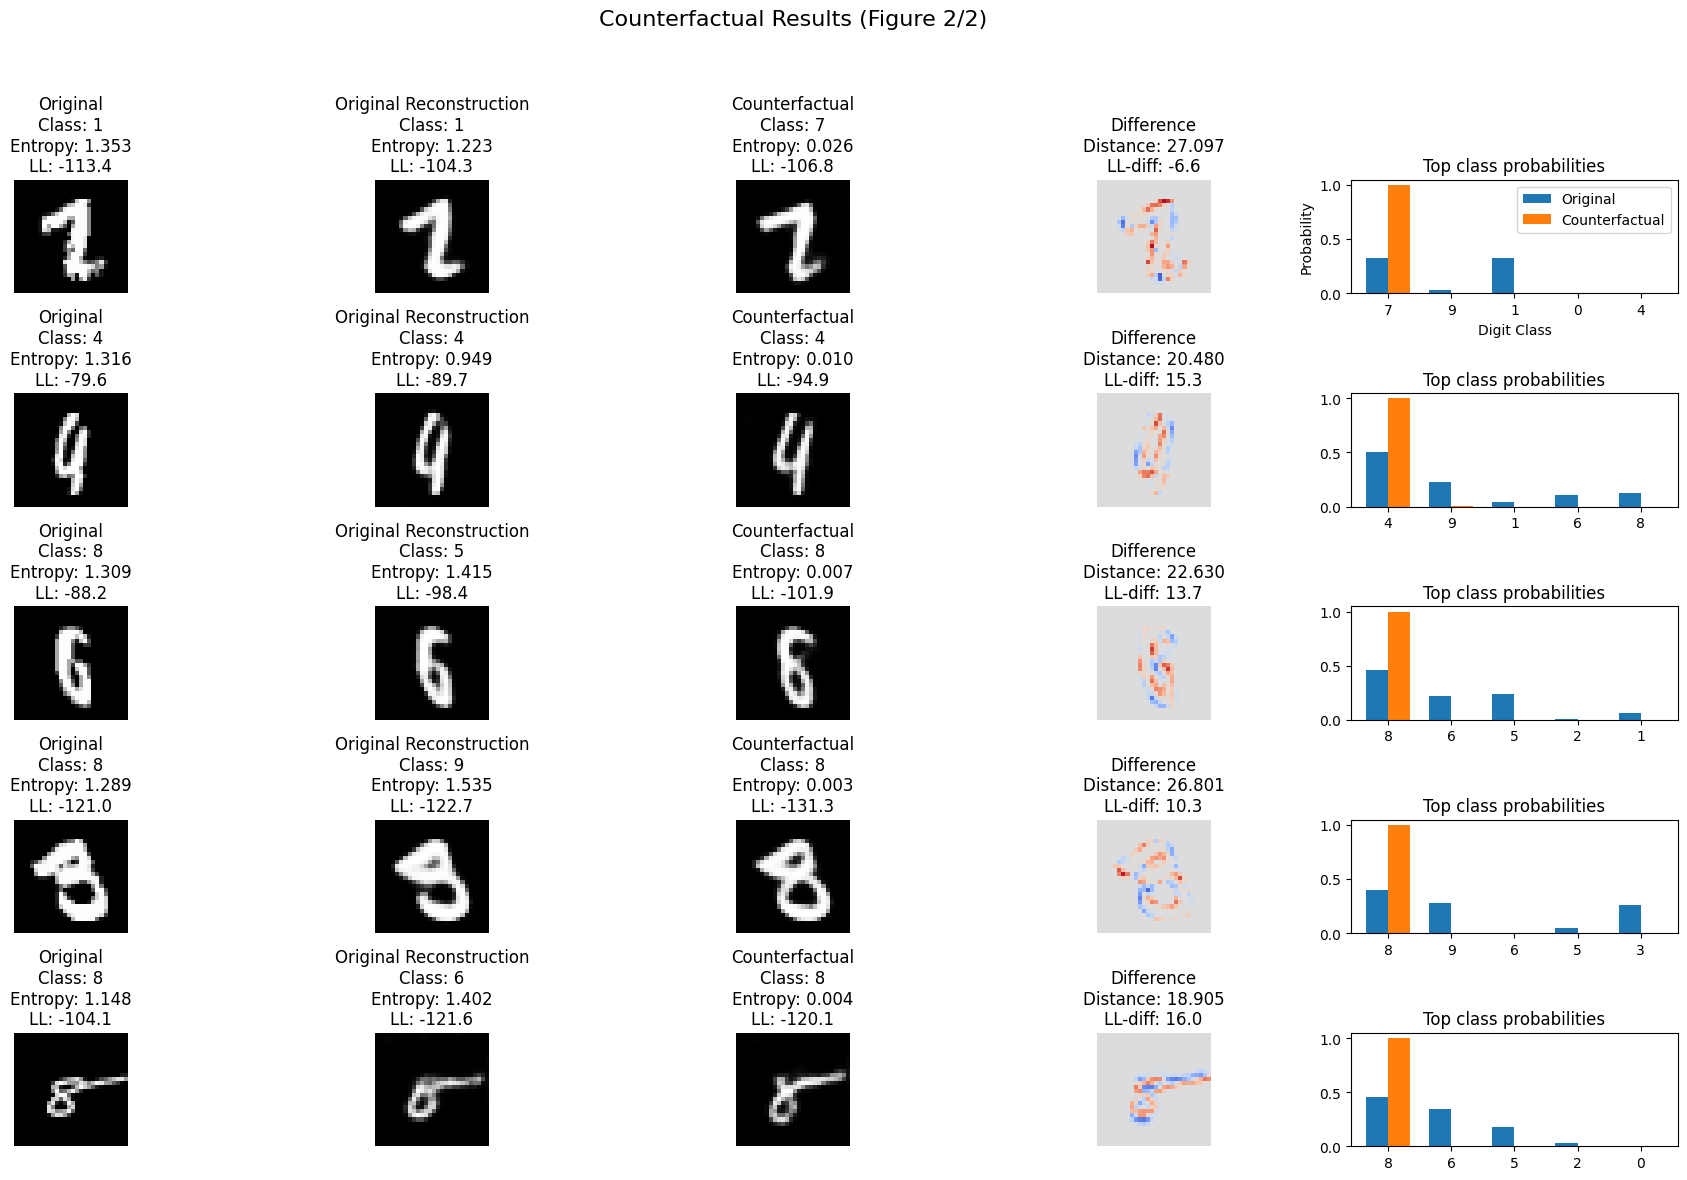

In [ ]:
visualize_counterfactual_results(results, n=10)

In [ ]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import save_counterfactual_results_to_csv

results_directory= models_dir + '/CLUE_results'

save_counterfactual_results_to_csv(results, output_dir=results_directory, suffix='joint_model_256_few_samples')

Individual results saved to: ../model_saves/new_regene_models/CLUE_results/joint_model_256_few_samples_2025-03-08_11-44-58/individual_results.csv
Aggregate results saved to: ../model_saves/new_regene_models/CLUE_results/joint_model_256_few_samples_2025-03-08_11-44-58/aggregate_results.csv


('../model_saves/new_regene_models/CLUE_results/joint_model_256_few_samples_2025-03-08_11-44-58/individual_results.csv',
 '../model_saves/new_regene_models/CLUE_results/joint_model_256_few_samples_2025-03-08_11-44-58/aggregate_results.csv')

## Evaluate CLUE (Deterministic)

### Load the VAE

In [20]:
from models.VAE_likelihood import ConvVAELikelihoodEstimator

vae = ConvVAELikelihoodEstimator(latent_dim=20, device=cfg.device)

vae.load_state_dict(torch.load(os.path.join(models_dir, 'vae_likelihood_estimator_20.pt'), map_location=cfg.device))


<All keys matched successfully>

### Get Uncertain Images

In [21]:
import importlib
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_clue_counterfactuals, find_uncertain_images, visualize_counterfactual_results, evaluate_single_clue_counterfactual

In [22]:
uncertain_images, uncertain_indices = find_uncertain_images(backbone, testloader, n=50, device=cfg.device, bayesian=False)

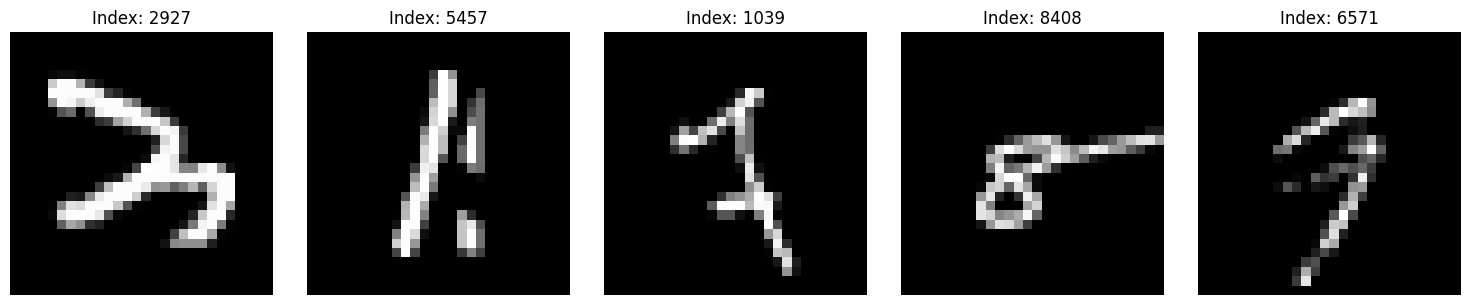

Uncertainty indices of these images: [2927, 5457, 1039, 8408, 6571]


In [23]:
# Plot the first 5 uncertain images
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(uncertain_images[i, 0].cpu(), cmap='gray')
    plt.title(f"Index: {uncertain_indices[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Uncertainty indices of these images:", uncertain_indices[:5].tolist())

### Test a single image

Step 00: Loss: 0.4461, Total Entropy: 0.4461, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.4461, Distance: 0.0000
Step 01: Loss: 0.2758, Total Entropy: 0.2718, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.2718, Distance: 0.8000
Step 02: Loss: 0.1695, Total Entropy: 0.1617, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.1617, Distance: 1.5629
Step 03: Loss: 0.1083, Total Entropy: 0.0969, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.0969, Distance: 2.2772
Step 04: Loss: 0.0743, Total Entropy: 0.0597, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.0597, Distance: 2.9321
Step 05: Loss: 0.0557, Total Entropy: 0.0380, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.0380, Distance: 3.5239
Step 06: Loss: 0.0455, Total Entropy: 0.0252, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.0252, Distance: 4.0540
Step 07: Loss: 0.0400, Total Entropy: 0.0173, Epistemic Entropy: 0.0000, Aleatoric Entropy: 0.0173, Distance: 4.5261
Step 08: Loss: 0.0371, Total Entropy: 0.0124, Epistemic Entropy:

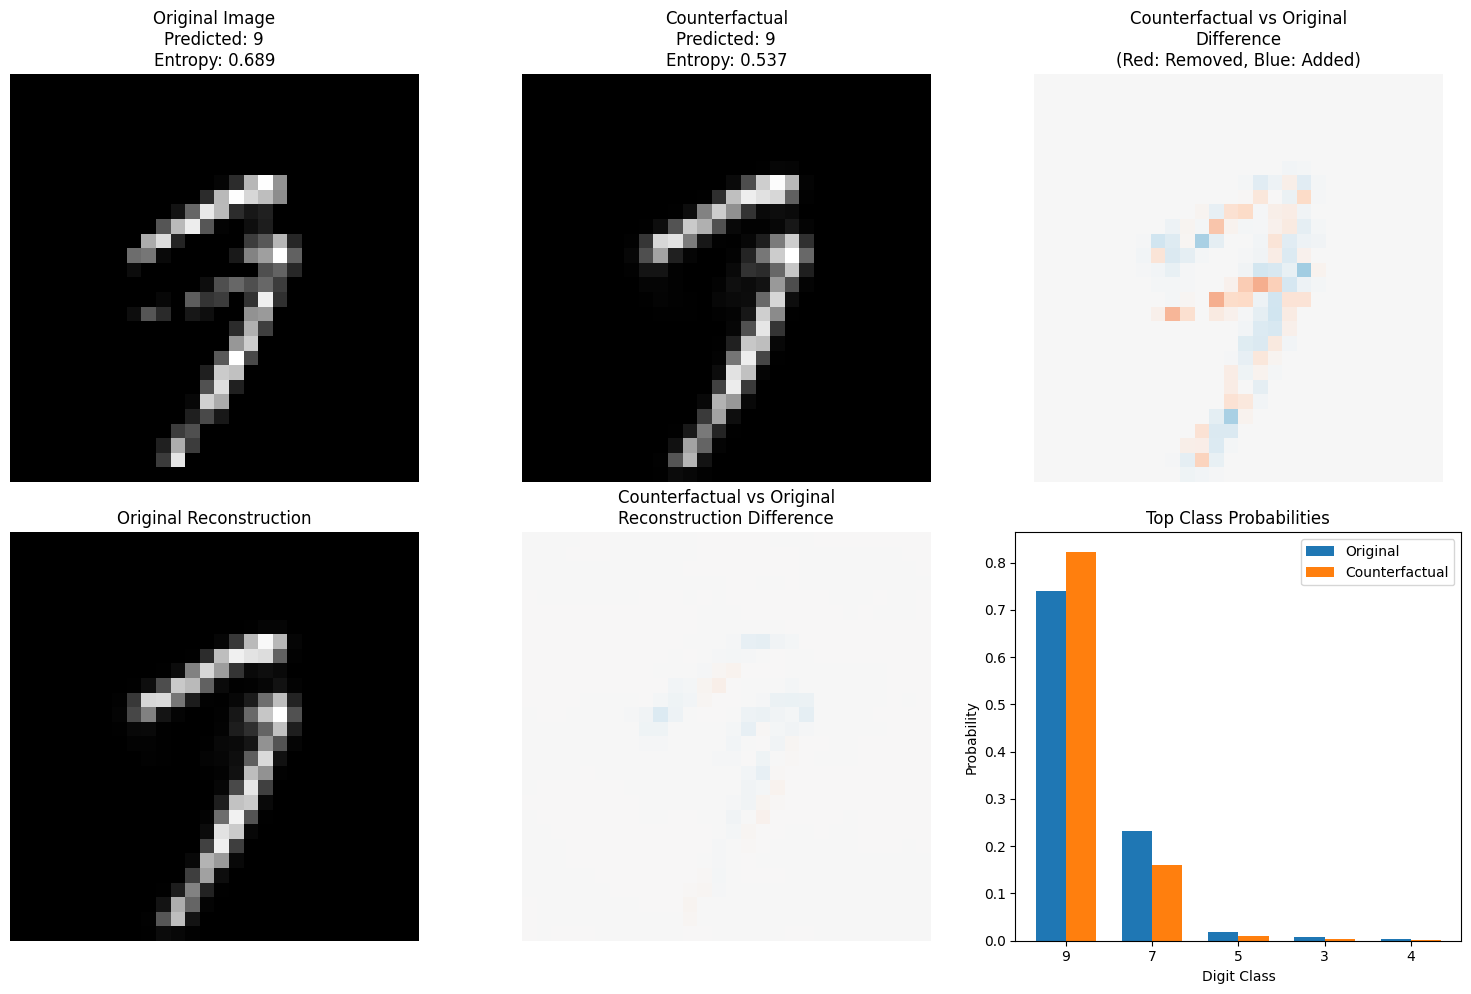


CLUE Counterfactual Results:
Latent Distance: 4.590
Latent Entropy Reduction: 0.441
Reconstruction Entropy Reduction: 0.152

Class probabilities:
Original (Predicted: 9): [0.    0.    0.    0.008 0.003 0.018 0.    0.231 0.    0.74 ]
Counterfactual (Predicted: 9): [0.    0.    0.    0.004 0.002 0.01  0.    0.161 0.    0.823]

Likelihood metrics:
Original log-likelihood: -85.17
Counterfactual log-likelihood: -84.48
Log-likelihood difference: -0.69
Likelihood ratio: 2.00x more likely
Original realism score: 0.987
Counterfactual realism score: 0.987
Realism score difference: -0.000


In [136]:
results, figure = evaluate_single_clue_counterfactual(
    uncertain_images[3],
    backbone,
    decoder,
    vae,
    device=cfg.device,
    verbose=True,
    steps=200,
    distance_weight=0.005,
    lr=0.05,
    bayesian=False
)

### Get average metrics

In [137]:
results = evaluate_clue_counterfactuals(
    uncertain_images,
    backbone,
    decoder,
    vae,
    device=cfg.device,
    steps=200,
    lr=0.05,
    distance_weight=0.005,
    bayesian=False
)


Aggregate Results over 50 images:
Average latent entropy reduction: 0.691
Average reconstruction entropy reduction: 0.225
Average latent distance: 4.789
Average log likelihood difference: 3.419
Average realism score difference: 0.001


Example 1 (Image Index: 10):
Latent entropy reduction: 1.406
Latent distance: 6.549
Log likelihood difference: 1.142
Original class prediction: 9
Counterfactual class prediction: 9

Example 2 (Image Index: 21):
Latent entropy reduction: 1.363
Latent distance: 5.727
Log likelihood difference: 4.273
Original class prediction: 4
Counterfactual class prediction: 4

Example 3 (Image Index: 44):
Latent entropy reduction: 1.309
Latent distance: 5.510
Log likelihood difference: 2.906
Original class prediction: 1
Counterfactual class prediction: 1

Example 4 (Image Index: 1):
Latent entropy reduction: 1.272
Latent distance: 6.221
Log likelihood difference: 3.992
Original class prediction: 9
Counterfactual class prediction: 9

Example 5 (Image Index: 16):
Latent 

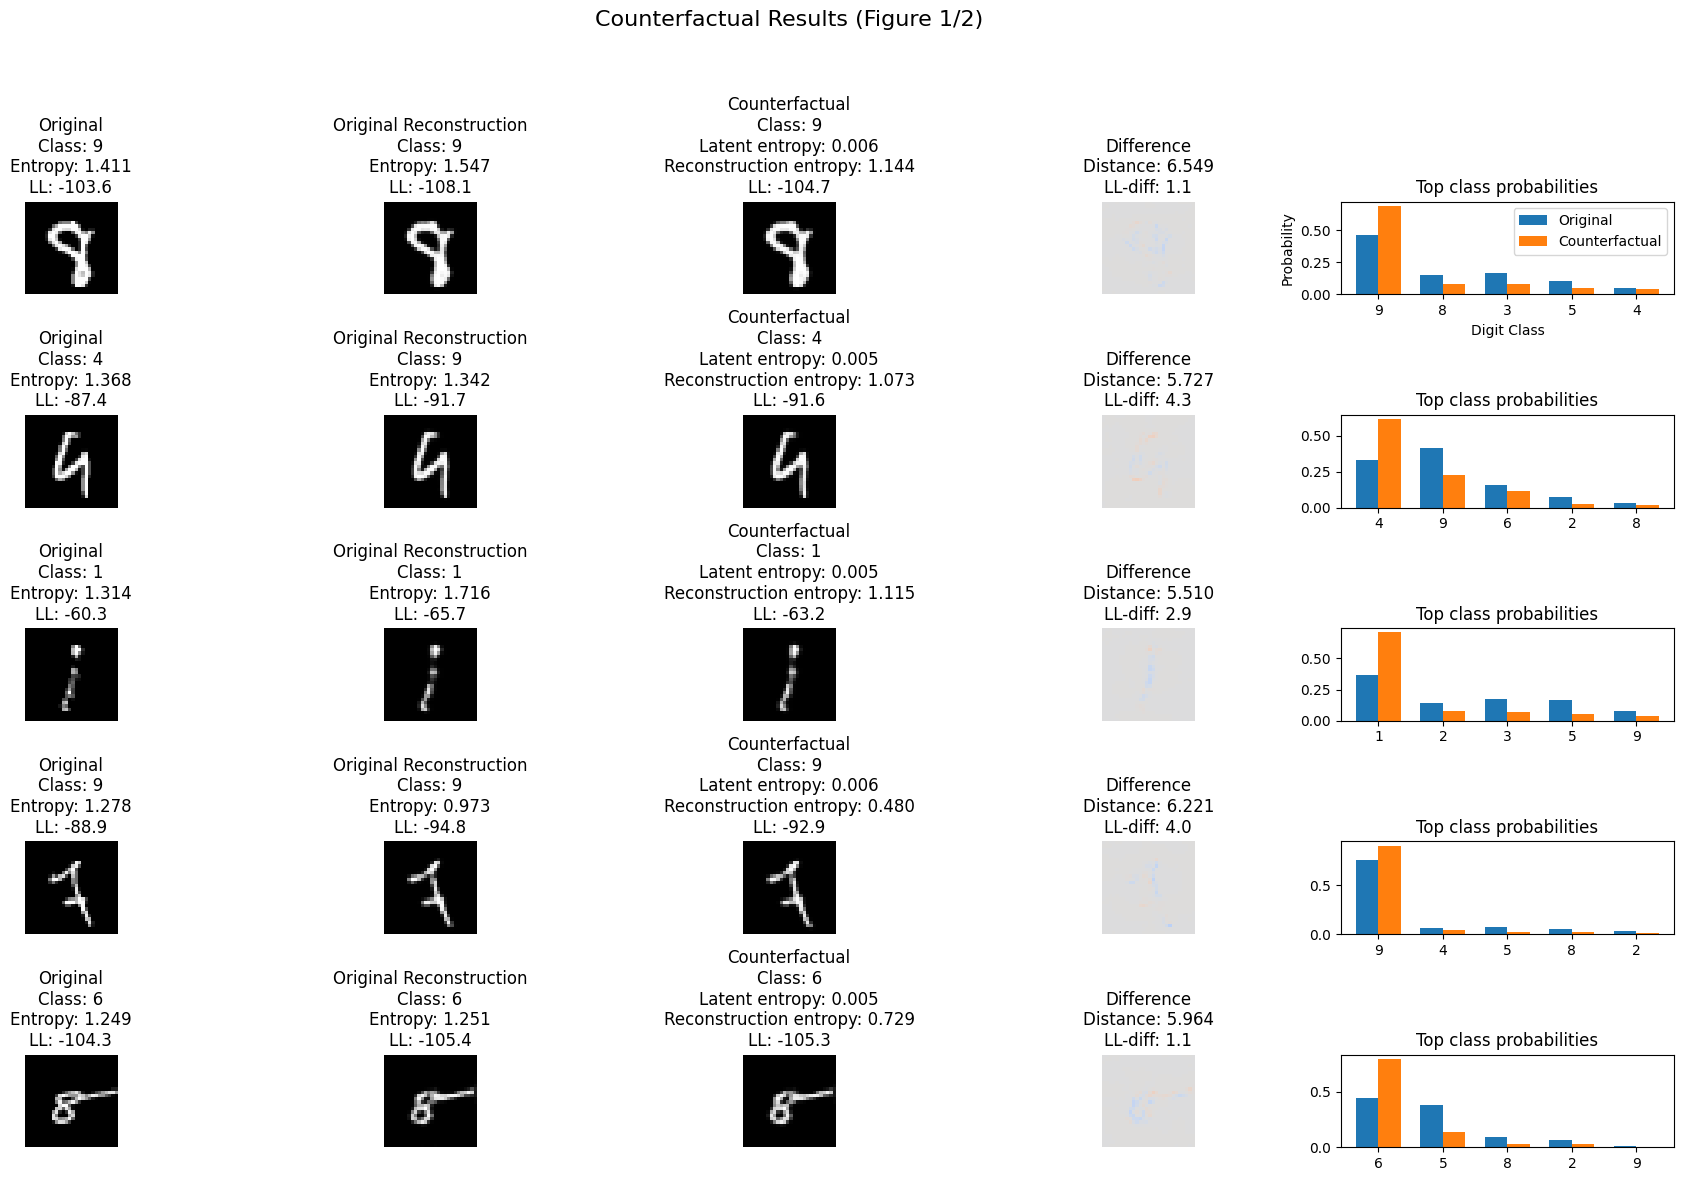

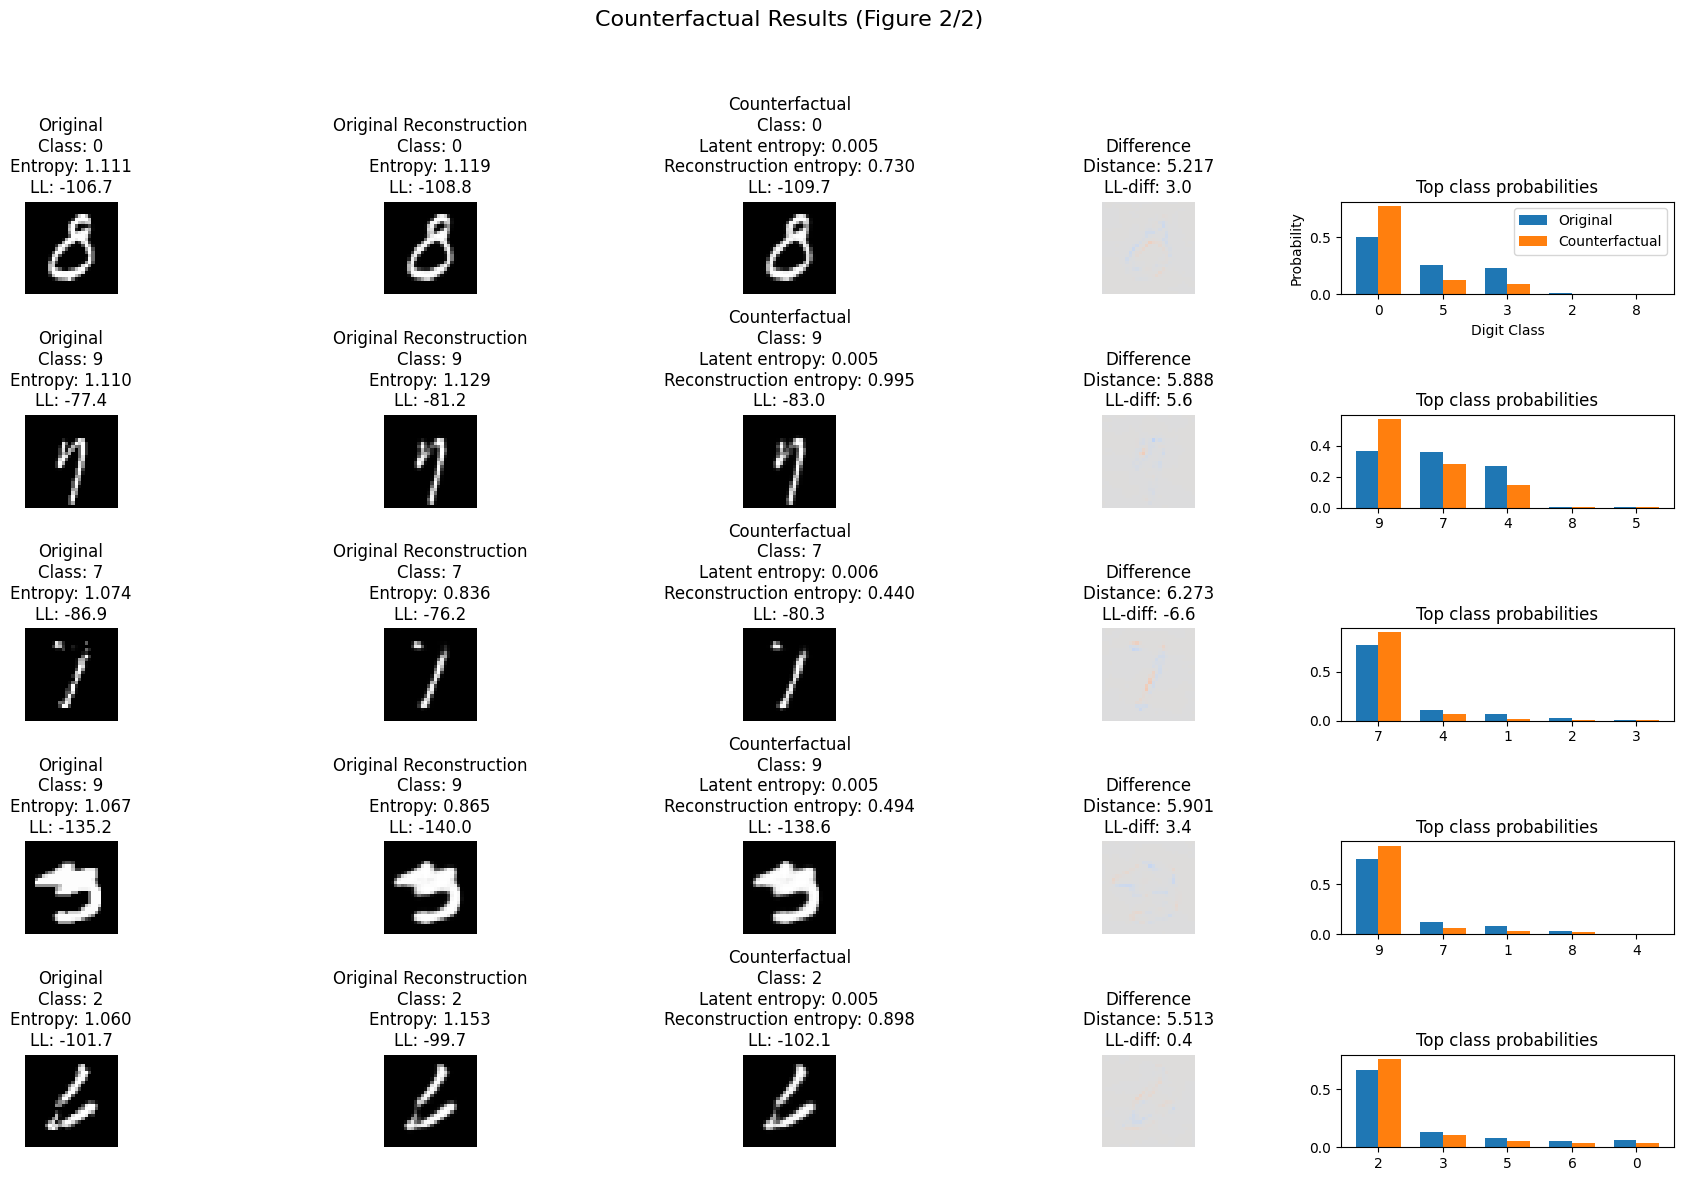

In [138]:
visualize_counterfactual_results(results, n=10)

In [139]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import save_counterfactual_results_to_csv

results_directory= models_dir + '/CLUE_results'

save_counterfactual_results_to_csv(results, output_dir=results_directory, suffix='DETERMINISTIC_autoencoder_dominated_model_256_50_samples')

Individual results saved to: ../model_saves/new_regene_models/CLUE_results/DETERMINISTIC_autoencoder_dominated_model_256_50_samples_2025-03-08_12-45-41/individual_results.csv
Aggregate results saved to: ../model_saves/new_regene_models/CLUE_results/DETERMINISTIC_autoencoder_dominated_model_256_50_samples_2025-03-08_12-45-41/aggregate_results.csv


('../model_saves/new_regene_models/CLUE_results/DETERMINISTIC_autoencoder_dominated_model_256_50_samples_2025-03-08_12-45-41/individual_results.csv',
 '../model_saves/new_regene_models/CLUE_results/DETERMINISTIC_autoencoder_dominated_model_256_50_samples_2025-03-08_12-45-41/aggregate_results.csv')

## Test Counterfactual - Specify Class

In [24]:
import importlib
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_clue_counterfactuals, find_uncertain_images, visualize_counterfactual_results, evaluate_single_clue_counterfactual

Test a single image

Step 00: Loss: 11.4920, Target Class Prob: 0.0000, Distance: 0.0000
Step 01: Loss: 8.4039, Target Class Prob: 0.0002, Distance: 1.6000
Step 02: Loss: 9.1730, Target Class Prob: 0.0001, Distance: 2.6296
Step 03: Loss: 10.1059, Target Class Prob: 0.0000, Distance: 3.4943
Step 04: Loss: 7.1660, Target Class Prob: 0.0008, Distance: 4.3201
Step 05: Loss: 5.9365, Target Class Prob: 0.0027, Distance: 5.1265
Step 06: Loss: 7.3986, Target Class Prob: 0.0006, Distance: 5.9261
Step 07: Loss: 4.7325, Target Class Prob: 0.0089, Distance: 6.6963
Step 08: Loss: 4.0628, Target Class Prob: 0.0173, Distance: 7.4455
Step 09: Loss: 3.9149, Target Class Prob: 0.0201, Distance: 8.1382
Step 10: Loss: 3.6183, Target Class Prob: 0.0271, Distance: 8.7866
Step 11: Loss: 4.3426, Target Class Prob: 0.0131, Distance: 9.4066
Step 12: Loss: 3.7793, Target Class Prob: 0.0231, Distance: 9.9933
Step 13: Loss: 3.4834, Target Class Prob: 0.0310, Distance: 10.5485
Step 14: Loss: 3.1201, Target Class Prob: 0.0446, Distance:

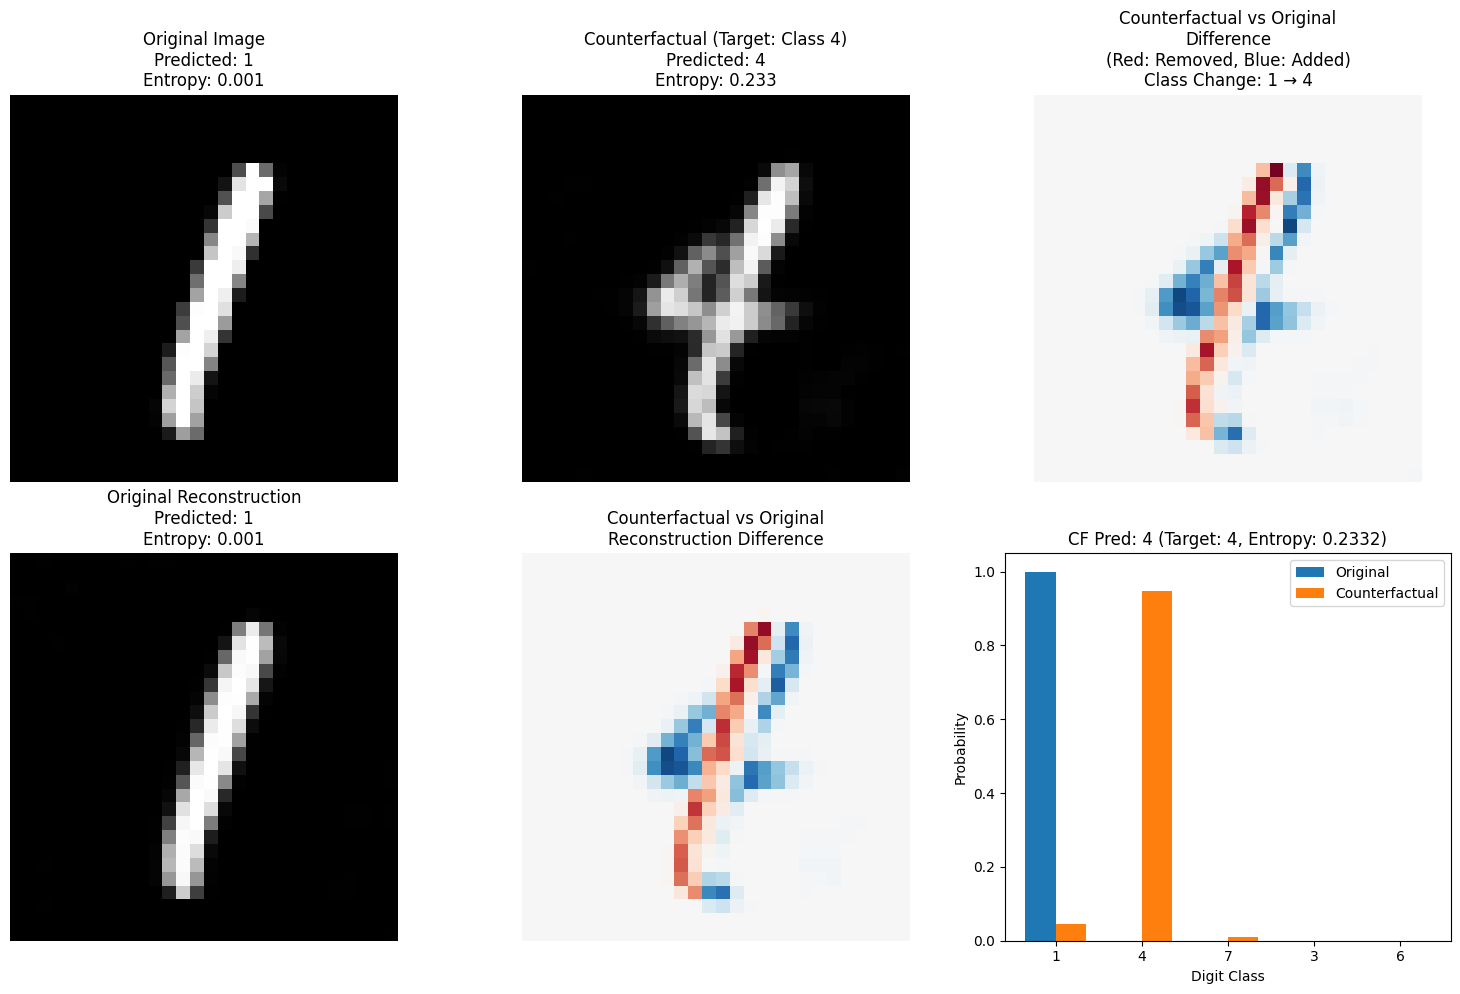


CLUE Counterfactual Results:
Latent Distance: 34.180
Latent Entropy Reduction: -0.048
Reconstruction Entropy Reduction: -0.233

Class probabilities:
Original (Predicted: 1): [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Counterfactual (Predicted: 4, Target: 4): [0.    0.044 0.    0.    0.947 0.    0.    0.009 0.    0.   ]


In [77]:
bayesian = True

if bayesian:
    model = bll_vi
else:
    model = backbone

image, label = testloader.dataset[5]
target_class = 4

results, figure = evaluate_single_clue_counterfactual(
    image,
    model,
    decoder,
    device=cfg.device,
    verbose=True,
    steps=200,
    distance_weight=0.001,
    lr=0.1,
    bayesian=bayesian,
    target_class=target_class
)

Visualise the latent space trajectory

Extracting embeddings:  20%|██        | 4/20 [00:02<00:09,  1.66it/s]


Running t-SNE on 2051 samples with 256 dimensions...


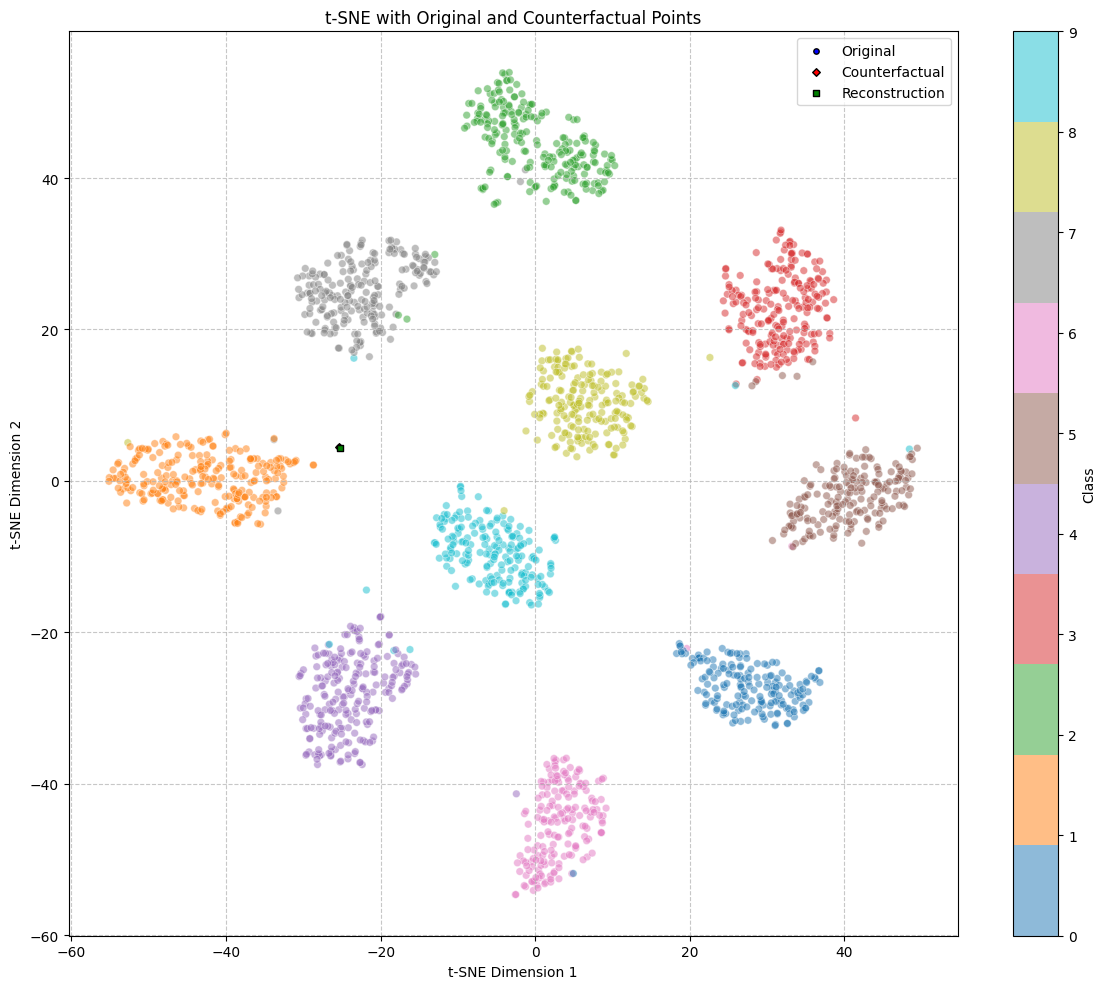

In [115]:
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import visualize_latent_space_with_special_points

# Use the function with your data
tsne, fig, ax, coords = visualize_latent_space_with_special_points(
    dataloader=testloader,
    model=bll_vi,
    original_latent=results['original_latent'],
    counterfactual_latent=results['counterfactual_latent'],
    reconstruction_latent=bll_vi.extract_features(results['counterfactual_image']),  # Optional, include if you have it
    batch_size=2000,  # Use a subset of the data for faster computation
    device=cfg.device,
    title="t-SNE with Original and Counterfactual Points"
)

Extracting embeddings:  30%|███       | 6/20 [00:03<00:07,  1.81it/s]


Running PCA on 3075 samples with 256 dimensions...


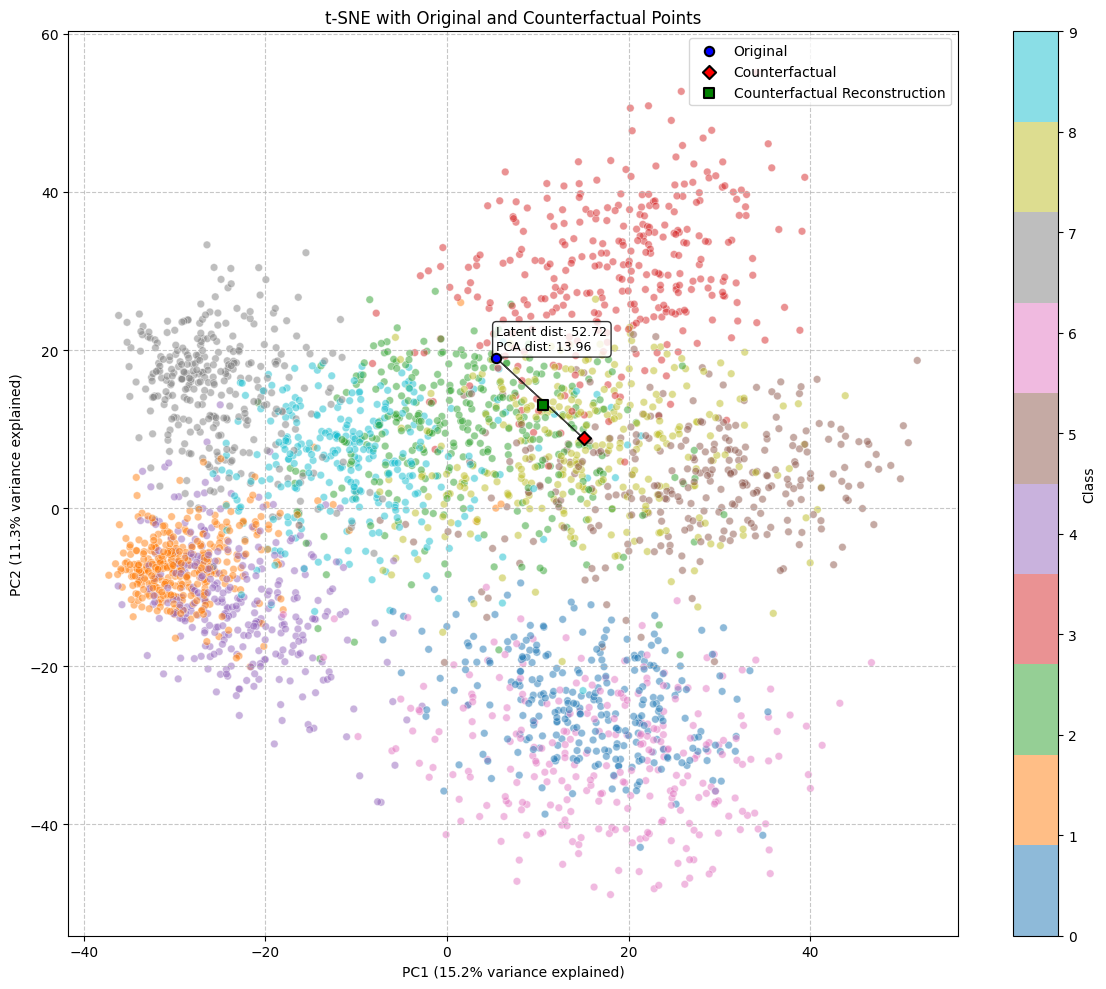

In [54]:
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import visualize_latent_space_with_pca

# Use the function with your data
tsne, fig, ax, coords = visualize_latent_space_with_pca(
    dataloader=testloader,
    model=bll_vi,
    original_latent=results['original_latent'],
    counterfactual_latent=results['counterfactual_latent'],
    reconstruction_latent=bll_vi.extract_features(results['counterfactual_image']),  # Optional, include if you have it
    batch_size=3000,  # Use a subset of the data for faster computation
    device=cfg.device,
    title="t-SNE with Original and Counterfactual Points"
)

Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Extracting embeddings:  30%|███       | 6/20 [00:02<00:06,  2.25it/s]


Running PCA on 3075 samples with 256 dimensions...


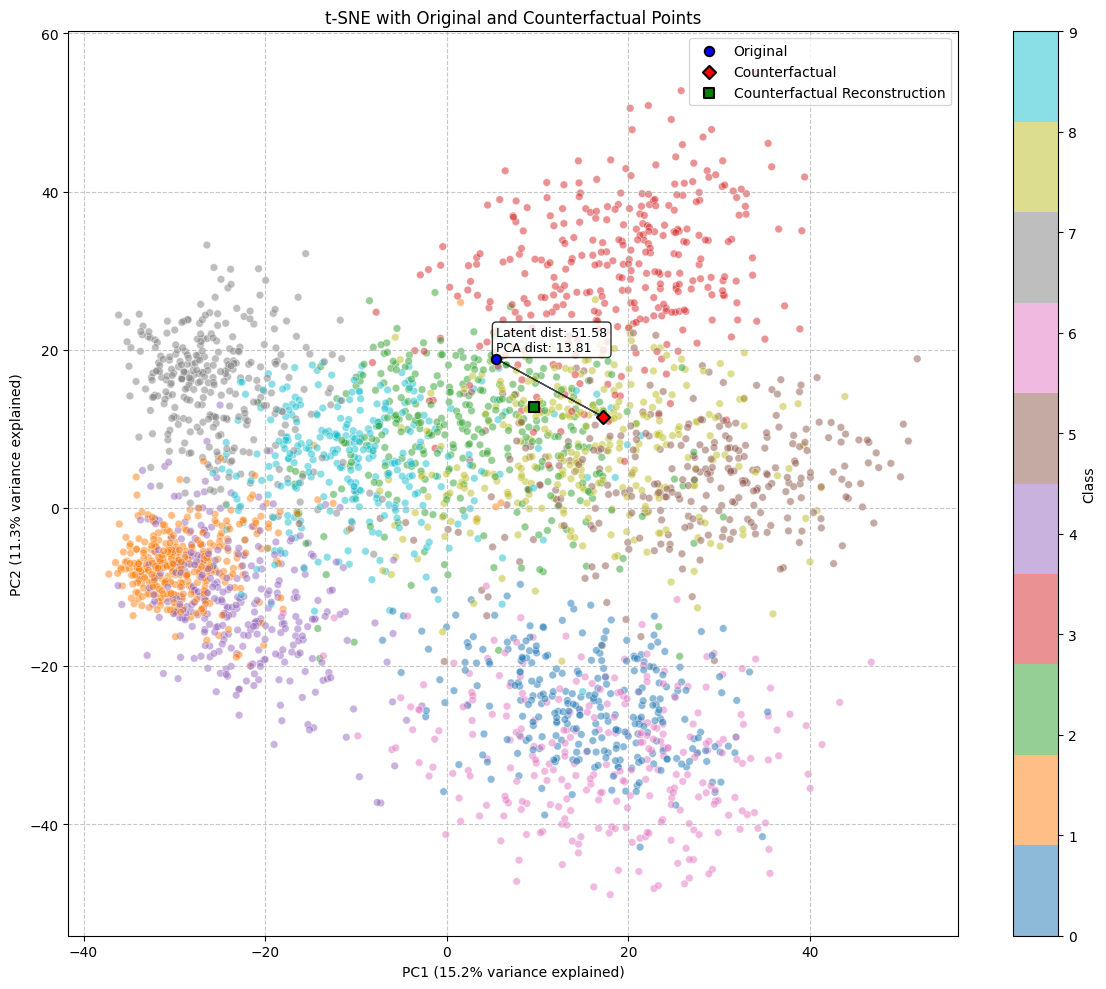

In [52]:
import clue.evaluate_CLUE
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import visualize_latent_space_with_pca

# Use the function with your data
tsne, fig, ax, coords = visualize_latent_space_with_pca(
    dataloader=testloader,
    model=bll_vi,
    original_latent=results['original_latent'],
    counterfactual_latent=results['counterfactual_latent'],
    reconstruction_latent=bll_vi.extract_features(results['counterfactual_image']),  # Optional, include if you have it
    batch_size=3000,  # Use a subset of the data for faster computation
    device=cfg.device,
    title="t-SNE with Original and Counterfactual Points"
)

## Test auxiliary autoencoder

In [40]:
# Import the counterfactual scorer
import models.counterfactual_scorer
importlib.reload(models.counterfactual_scorer)
from models.counterfactual_scorer import MNISTClassAutoencoders

# Initialize the class autoencoders with the correct model path
models_dir = '../model_saves/im1_autoencoders'
class_autoencoders = MNISTClassAutoencoders(latent_dim=32, device=cfg.device, models_dir=models_dir)

# Load the pre-trained models
try:
    class_autoencoders.load_models()
    print("Class-specific autoencoder models loaded successfully from", models_dir)
except Exception as e:
    print(f"Error loading class autoencoder models: {e}")
    print("Some models may not be initialized")

Loading autoencoder for digit 0...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Loading autoencoder for digit 1...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_1.pth
Loading autoencoder for digit 2...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_2.pth
Loading autoencoder for digit 3...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_3.pth
Loading autoencoder for digit 4...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_4.pth
Loading autoencoder for digit 5...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_5.pth
Loading autoencoder for digit 6...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_6.pth
Loading autoencoder for digit 7...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Loading autoencoder for digit 8...
Model loaded from ../model_saves/im1_autoenco

### Test autoencoder

Final target class probability: 0.9998, Distance: 57.2161


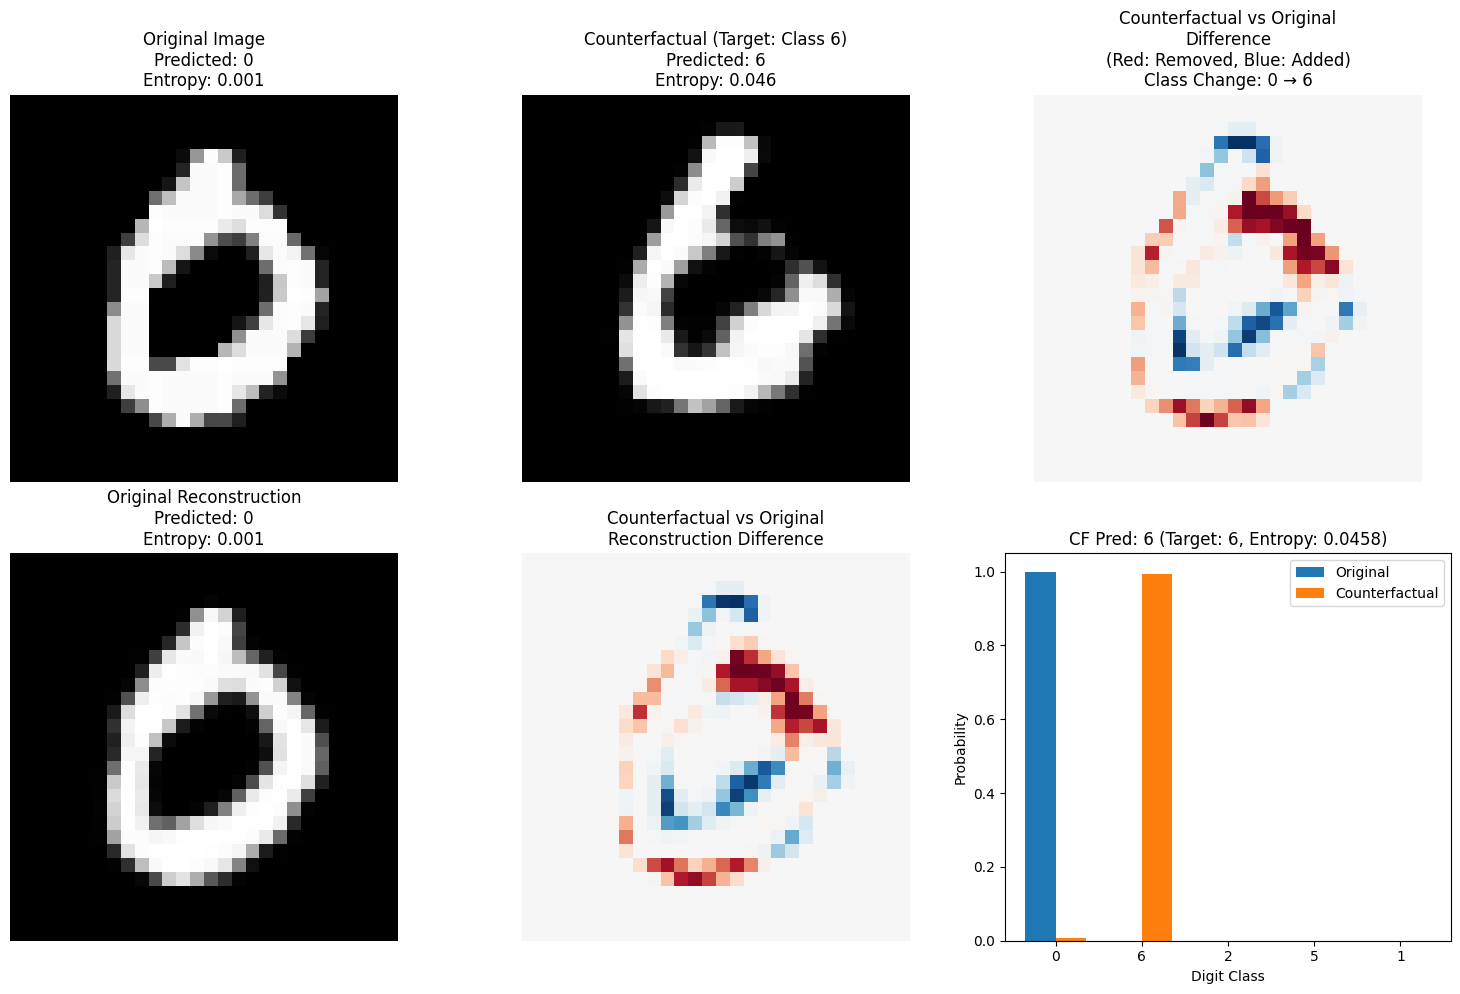

Final target class probability: 0.9787, Distance: 48.0746


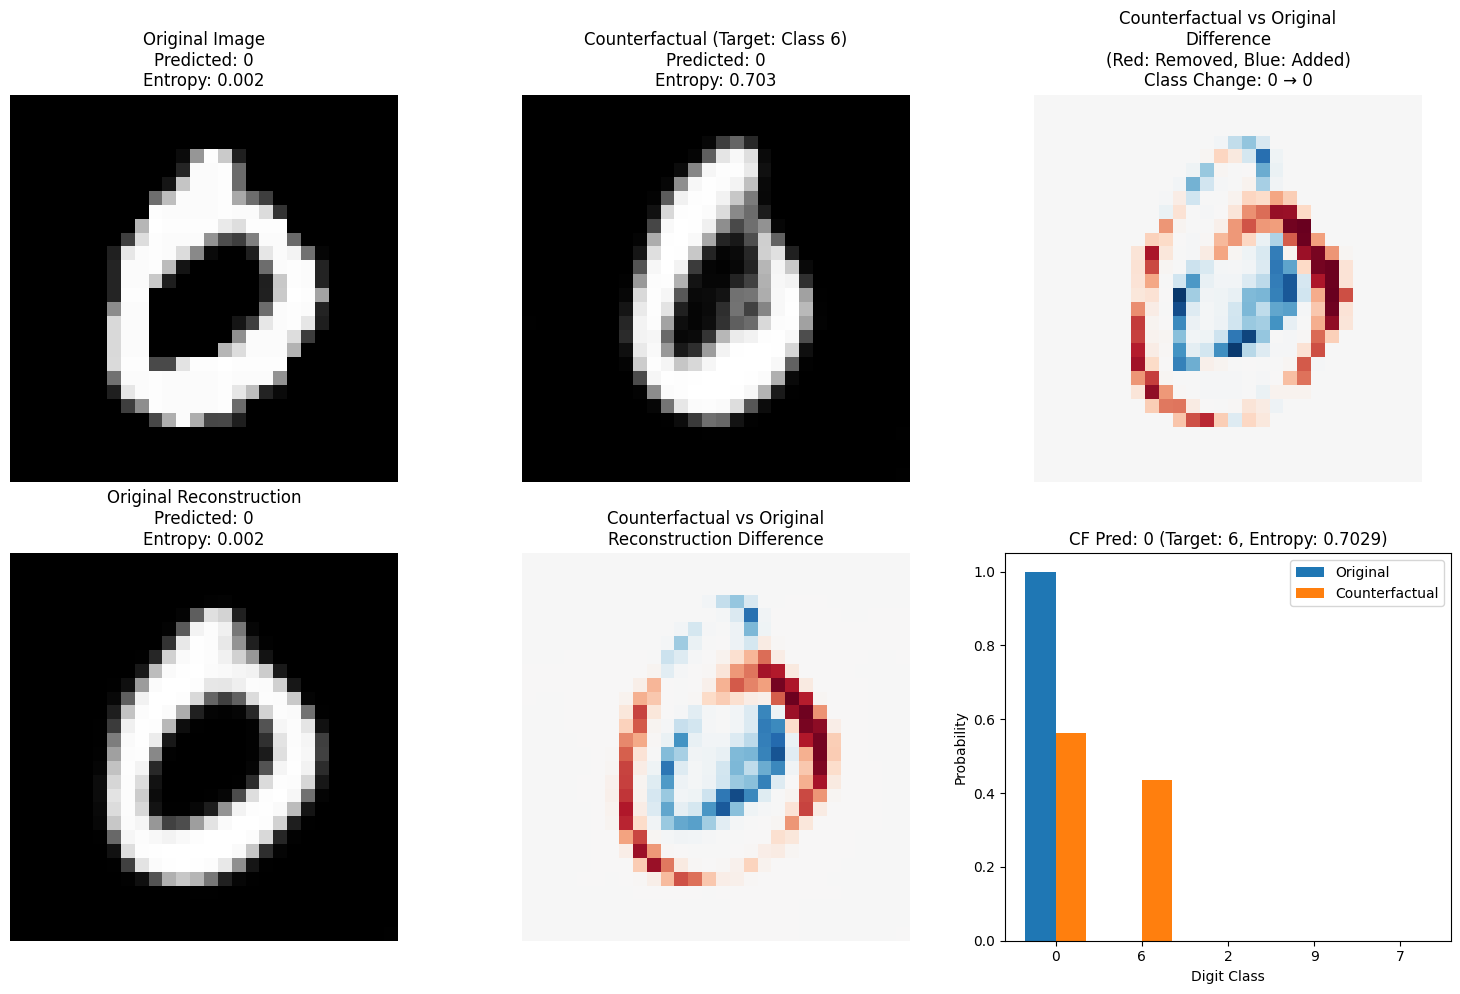

In [58]:


from clue.evaluate_CLUE import evaluate_single_auxiliary_clue_counterfactual, evaluate_single_clue_counterfactual
importlib.reload(clue.evaluate_CLUE)
import clue.new_CLUE
importlib.reload(clue.new_CLUE)
import models.BLL_VI
importlib.reload(models.BLL_VI)

bayesian = True

if bayesian:
    model = bll_vi
else:
    model = backbone

image, label = testloader.dataset[3]
target_class = 6

unsupervised_results, unsupervised_figure = evaluate_single_auxiliary_clue_counterfactual(
    image,
    model,
    autoencoder,
    device=cfg.device,
    verbose=False,
    steps=200,
    distance_weight=0.001,
    lr=0.2,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

supervised_results, supervised_figure = evaluate_single_clue_counterfactual(
    image,
    model,
    decoder,
    device=cfg.device,
    verbose=False,
    steps=200,
    distance_weight=0.001,
    lr=0.2,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

Loaded backbone from: ../model_saves/big_test/joint_classifier_256.pth
Loaded decoder from: ../model_saves/big_test/joint_decoder_256.pth
 [load_checkpoint] Loaded checkpoint from ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_256.pt
Loaded BLL_VI model from: ../model_saves/big_test/BLL_VI/BLL_VI_joint_training_BLL_256.pt
Image 5 - Label: 1, Backbone pred: 1, BLL_VI pred: 1
Image 10 - Label: 0, Backbone pred: 0, BLL_VI pred: 0
Image 15 - Label: 5, Backbone pred: 5, BLL_VI pred: 5
Image 20 - Label: 9, Backbone pred: 9, BLL_VI pred: 9
Image 25 - Label: 0, Backbone pred: 0, BLL_VI pred: 0


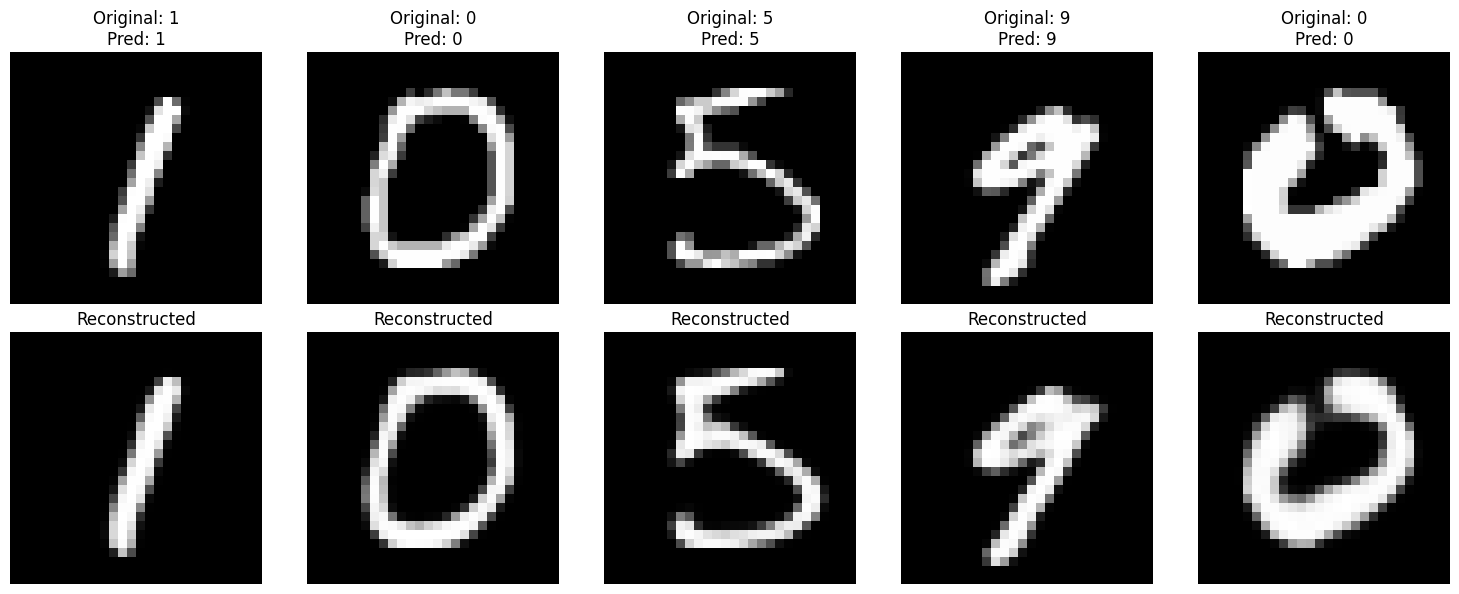

In [27]:
latent_dim = 256

second_models_dir = '../model_saves/big_test'
second_decoder = models.regene_models.Decoder(latent_dim=latent_dim, device=cfg.device)
second_backbone = models.regene_models.Classifier(latent_dim=latent_dim, num_classes=10, device=cfg.device)

# Load the models
second_backbone_path = os.path.join(second_models_dir, f'joint_classifier_{latent_dim}.pth')
second_decoder_path = os.path.join(second_models_dir, f'joint_decoder_{latent_dim}.pth')

# Check if files exist before loading
if os.path.exists(second_backbone_path):
    second_backbone.load_state_dict(torch.load(second_backbone_path, map_location=cfg.device))
    print(f"Loaded backbone from: {second_backbone_path}")
else:
    print(f"Warning: Backbone model file not found at {second_backbone_path}")

if os.path.exists(second_decoder_path):
    second_decoder.load_state_dict(torch.load(second_decoder_path, map_location=cfg.device))
    print(f"Loaded decoder from: {second_decoder_path}")
else:
    print(f"Warning: Decoder model file not found at {second_decoder_path}")

# Create BLL_VI model
second_bll_vi = models.BLL_VI.BayesianLastLayerVI(
    backbone=second_backbone,
    input_dim=latent_dim,  # Matches backbone's encoder output
    output_dim=10,  # MNIST classes
    device=cfg.device
)

# Load the BLL_VI model from checkpoint
bll_vi_path = os.path.join(second_models_dir, 'BLL_VI', f'BLL_VI_joint_training_BLL_{latent_dim}.pt')
if os.path.exists(bll_vi_path):
    second_bll_vi.load_checkpoint(bll_vi_path)
    print(f"Loaded BLL_VI model from: {bll_vi_path}")
else:
    print(f"Warning: BLL_VI model file not found at {bll_vi_path}")

# Test the models with multiple sample images
test_indices = [5, 10, 15, 20, 25]  # Test with 5 different images
plt.figure(figsize=(15, 6))

for i, idx in enumerate(test_indices):
    test_image, test_label = testloader.dataset[idx]
    test_image_tensor = test_image.unsqueeze(0).to(cfg.device)

    # Test backbone prediction
    with torch.no_grad():
        # For backbone
        second_backbone.eval()
        z, backbone_logits = second_backbone(test_image_tensor)
        backbone_pred = torch.argmax(backbone_logits, dim=1).item()
        
        # For BLL_VI
        second_bll_vi.eval()
        bll_logits = second_bll_vi(test_image_tensor)
        bll_pred = torch.argmax(bll_logits, dim=1).item()
        
        # Test reconstruction
        reconstructed = second_decoder(z)
    
    # Plot original and reconstructed images
    plt.subplot(2, 5, i+1)
    plt.imshow(test_image.squeeze().numpy(), cmap='gray')
    plt.title(f"Original: {test_label}\nPred: {bll_pred}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(reconstructed.squeeze().cpu().detach().numpy(), cmap='gray')
    plt.title(f"Reconstructed")
    plt.axis('off')

    print(f"Image {idx} - Label: {test_label}, Backbone pred: {backbone_pred}, BLL_VI pred: {bll_pred}")

plt.tight_layout()
plt.show()


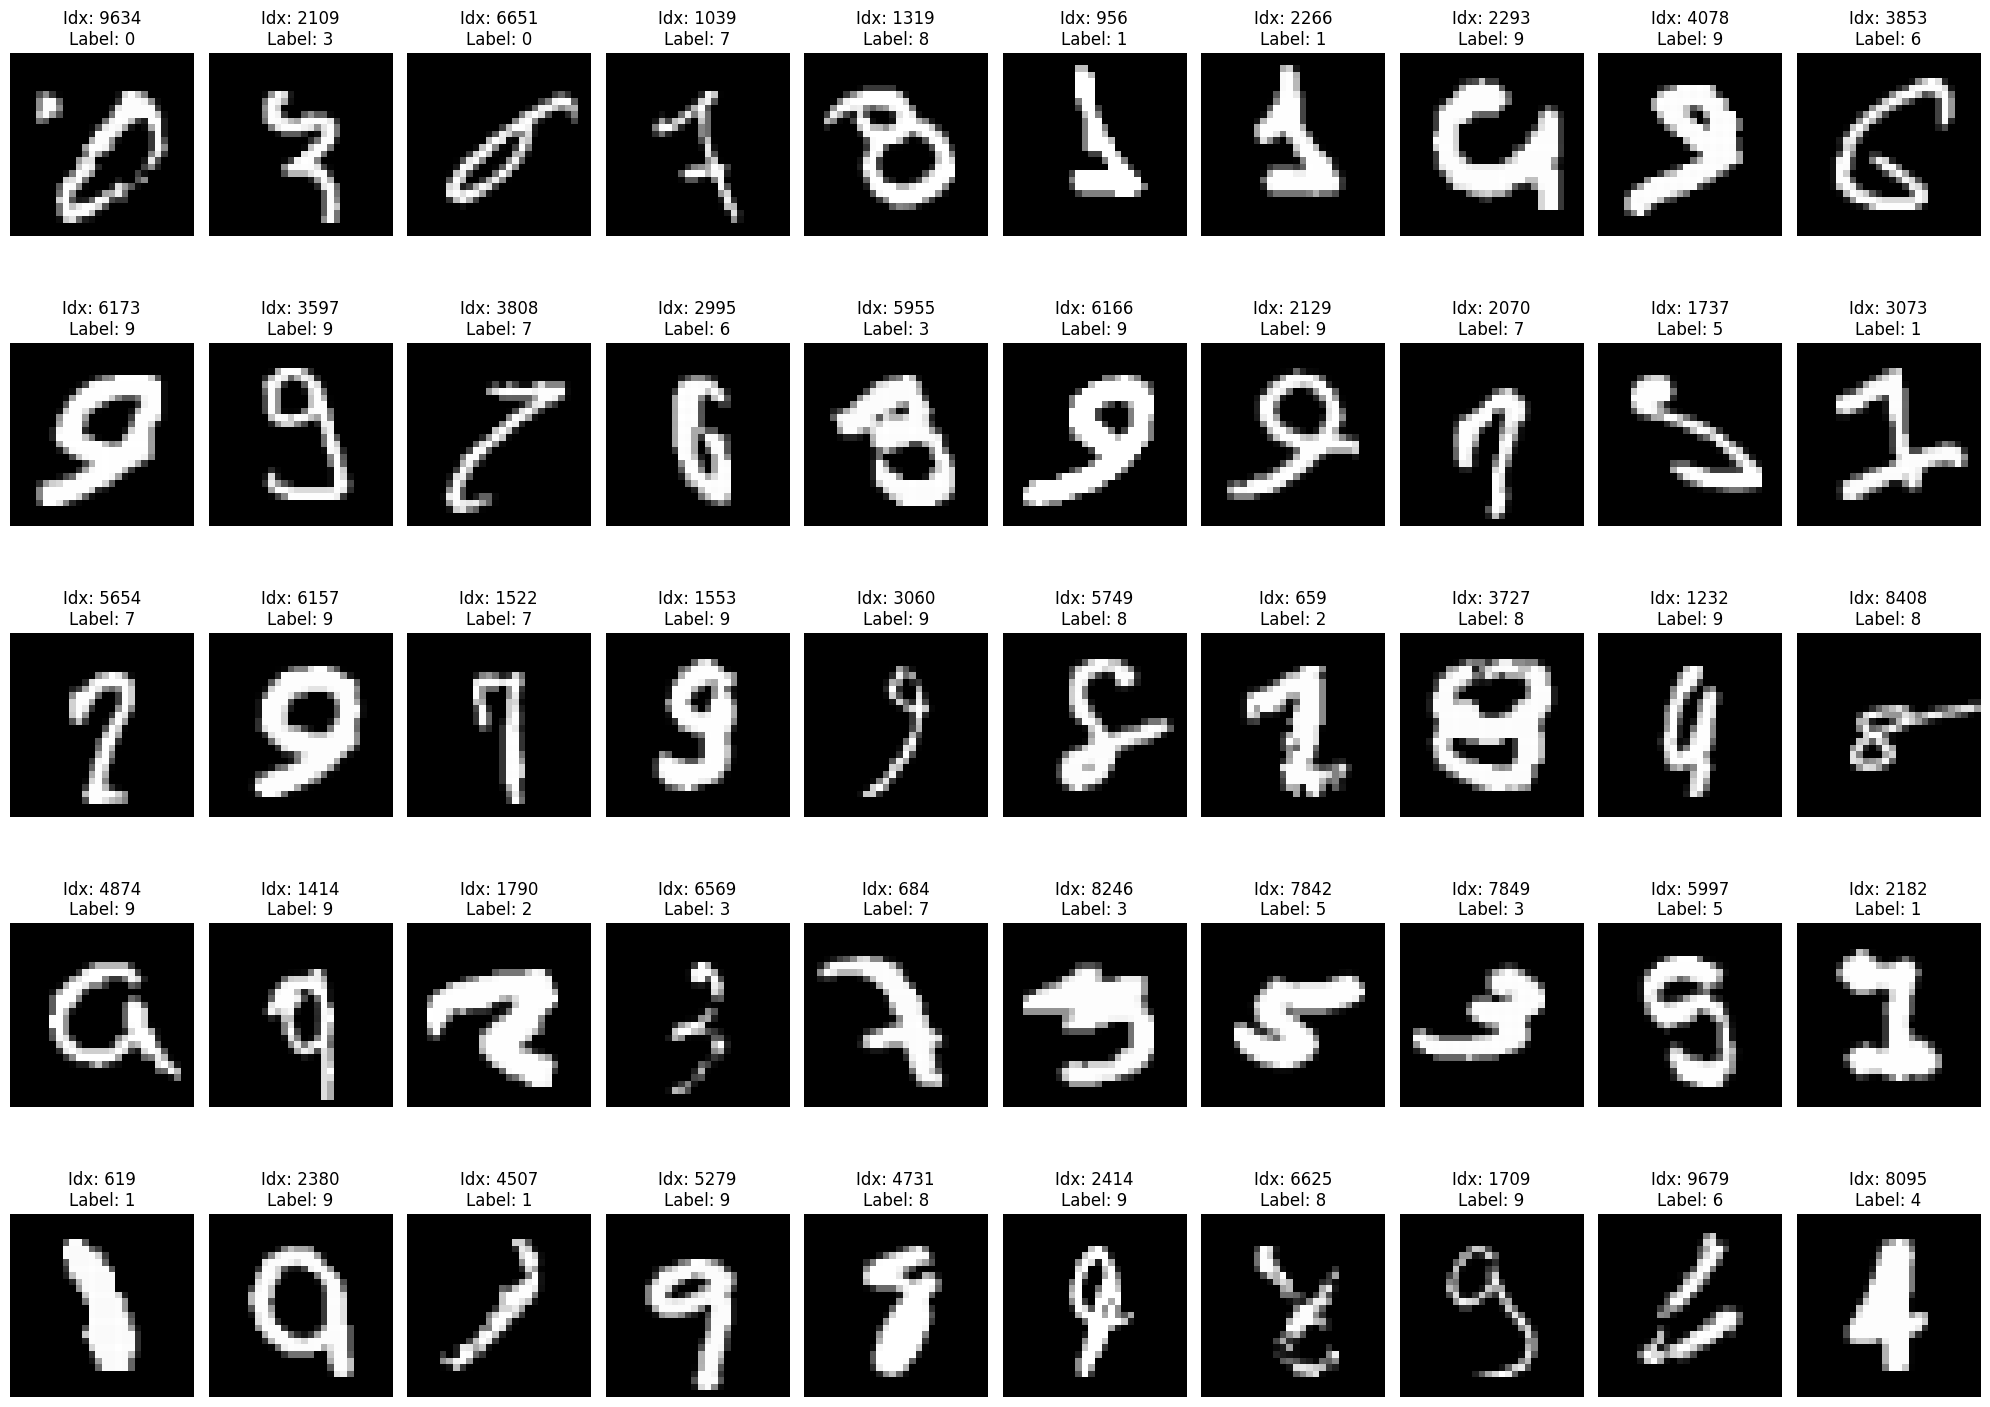

Retrieved 50 uncertain images with indices: [9634, 2109, 6651, 1039, 1319, 956, 2266, 2293, 4078, 3853, 6173, 3597, 3808, 2995, 5955, 6166, 2129, 2070, 1737, 3073, 5654, 6157, 1522, 1553, 3060, 5749, 659, 3727, 1232, 8408, 4874, 1414, 1790, 6569, 684, 8246, 7842, 7849, 5997, 2182, 619, 2380, 4507, 5279, 4731, 2414, 6625, 1709, 9679, 8095]


In [37]:
# Get uncertain images from the test dataset
import matplotlib.pyplot as plt

# Display the 50 uncertain images
plt.figure(figsize=(20, 15))
for i in range(50):
    plt.subplot(5, 10, i+1)
    img = uncertain_images[i].squeeze().cpu().numpy()
    label = testloader.dataset[uncertain_indices[i]][1]
    plt.imshow(img, cmap='gray')
    plt.title(f"Idx: {uncertain_indices[i]}\nLabel: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Retrieved {len(uncertain_images)} uncertain images with indices: {uncertain_indices.tolist()}")


Evaluating Supervised Deterministic...
Final target class probability: 1.0000, Distance: 44.9526
Evaluating Unsupervised Deterministic...
Final target class probability: 1.0000, Distance: 42.8644
Evaluating Supervised Bayesian...
Final target class probability: 1.0000, Distance: 37.6798
Evaluating Unsupervised Bayesian...
Final target class probability: 0.9999, Distance: 32.4602


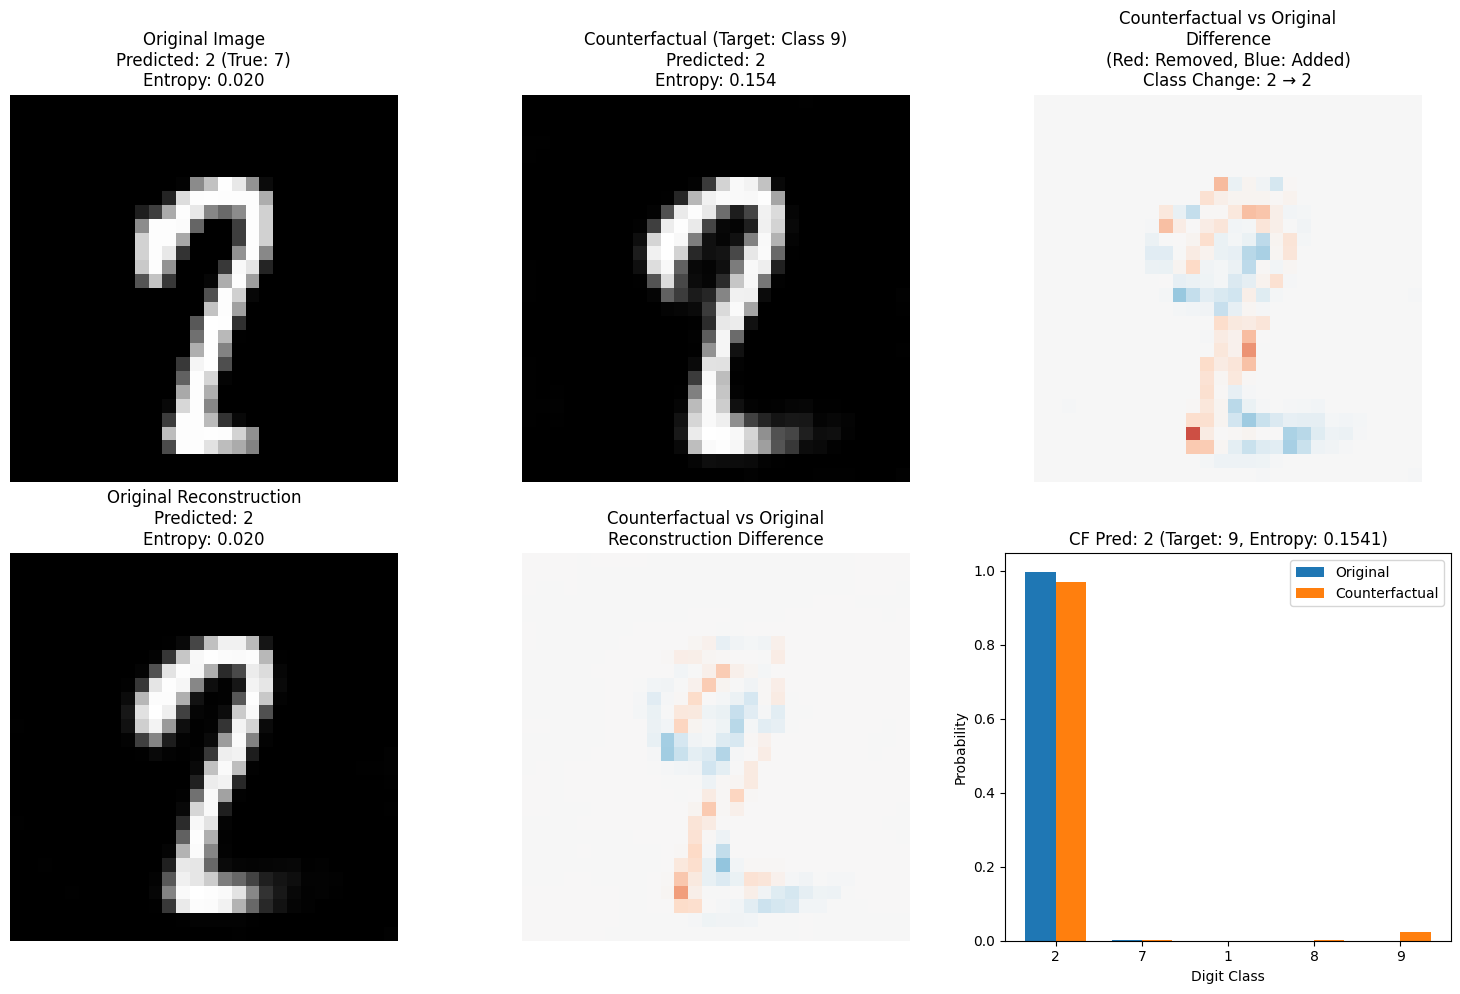

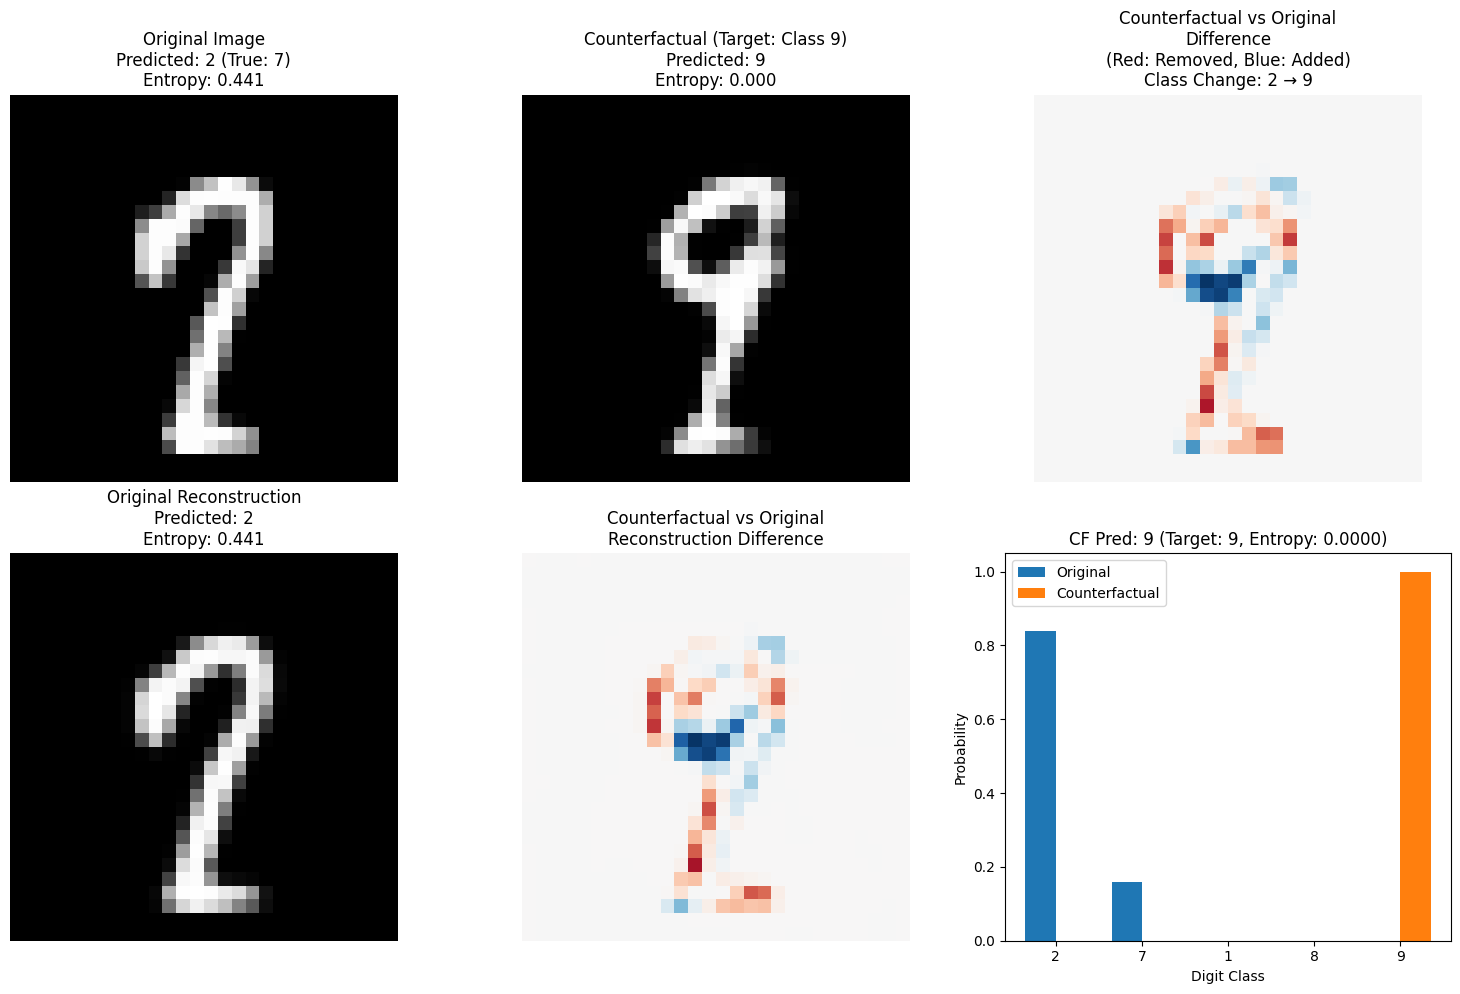

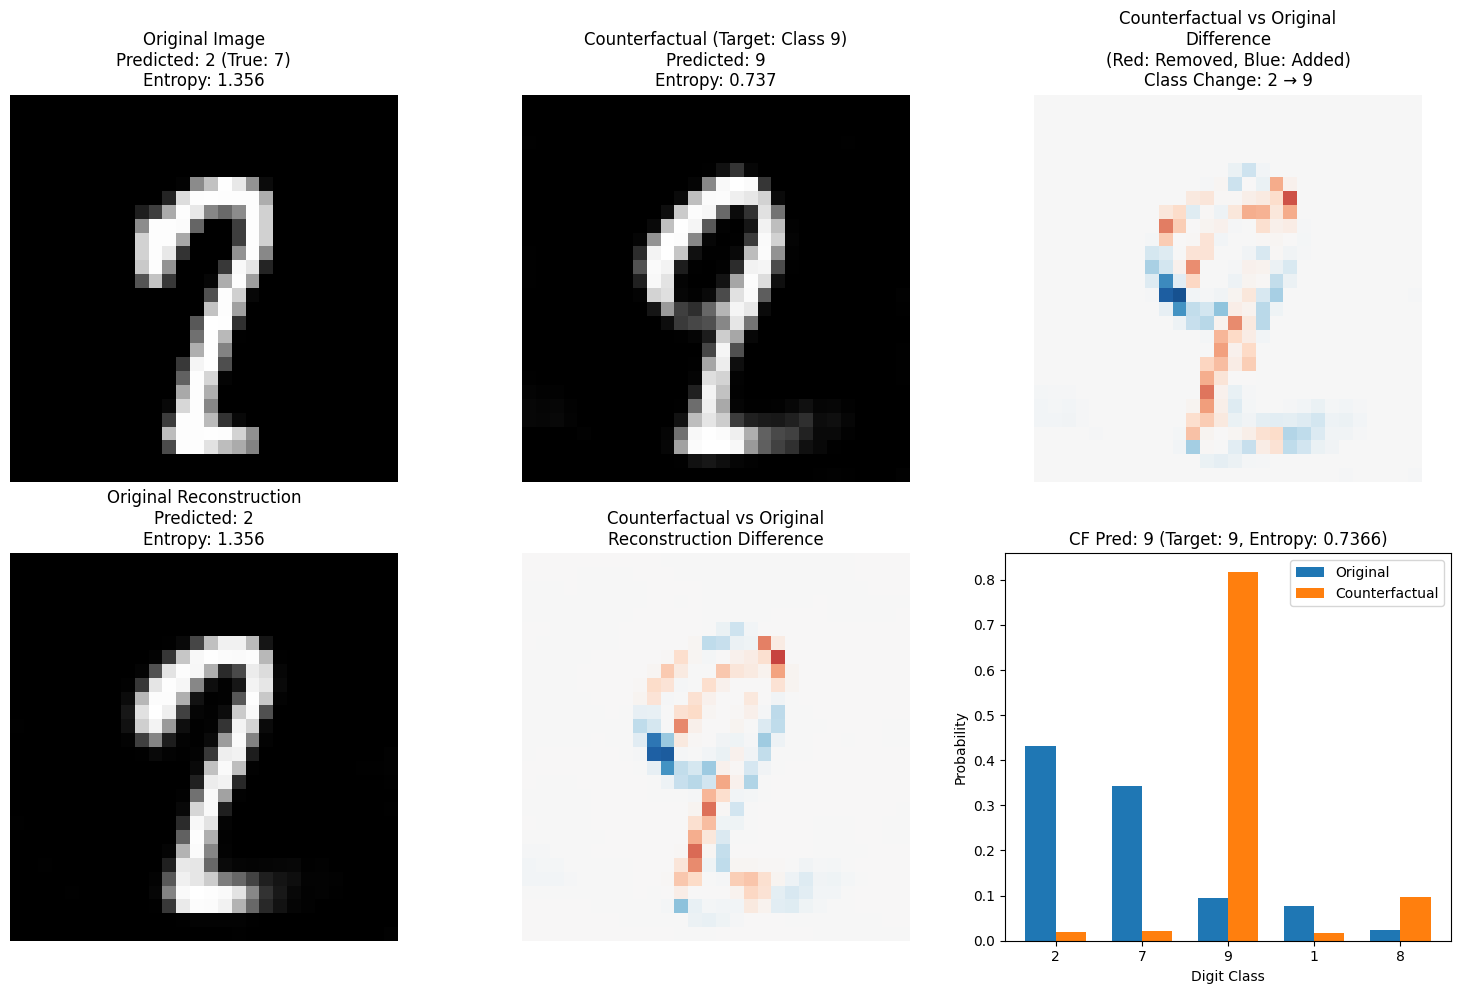

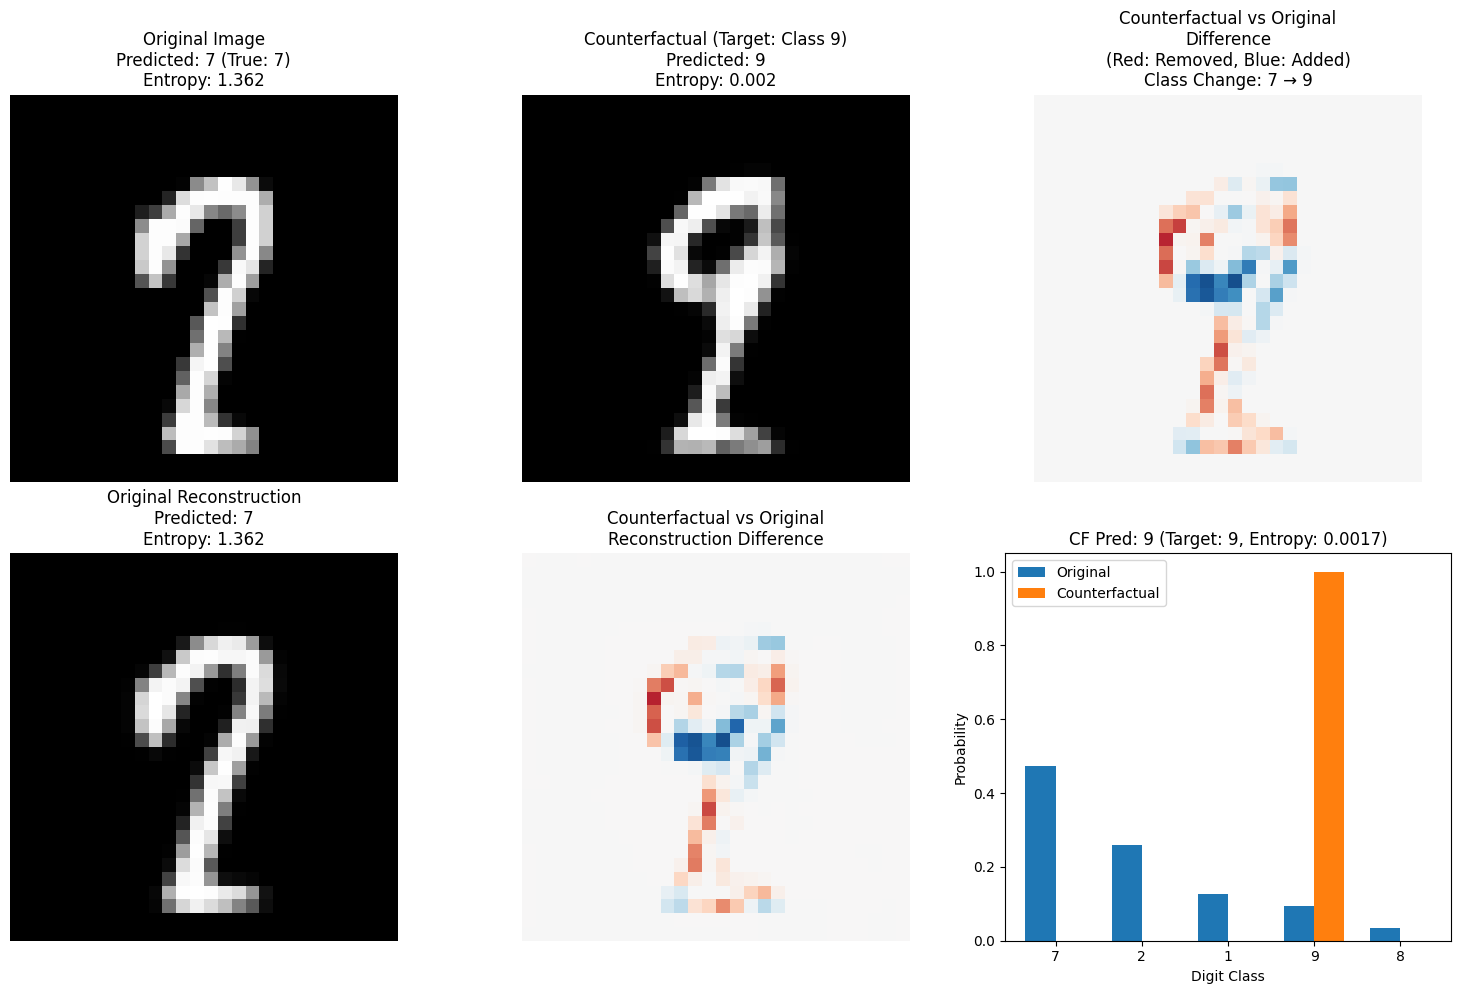

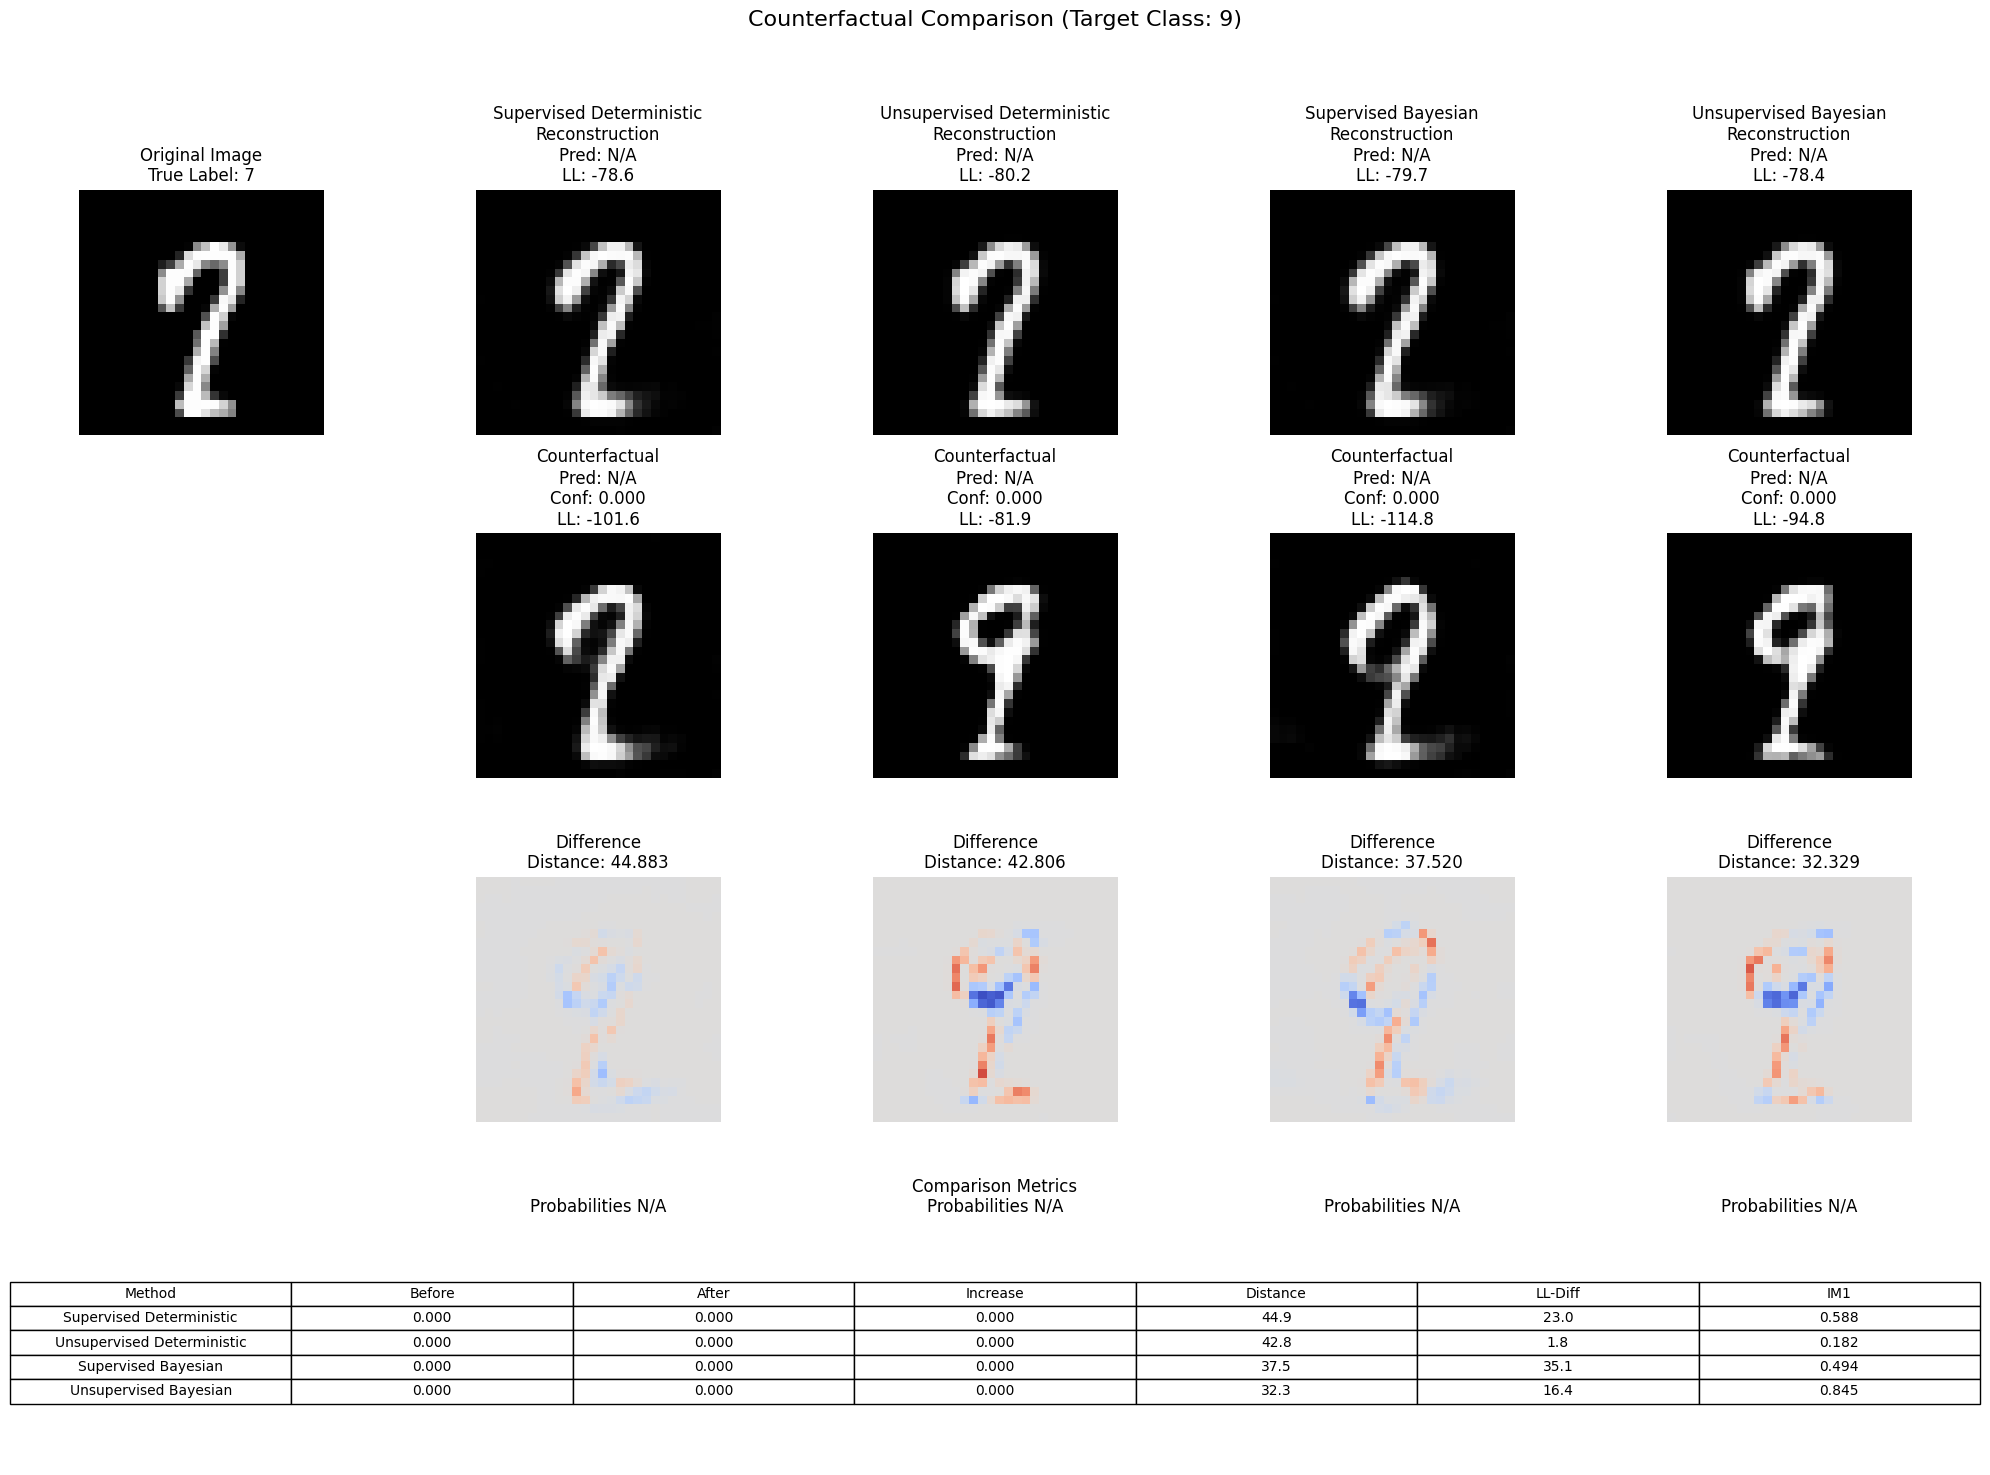

In [43]:
from clue.evaluate_CLUE import evaluate_multiple_counterfactual_methods
importlib.reload(clue.evaluate_CLUE)

image, label = testloader.dataset[5654]
target_class = 9

all_results, comparison_figure = evaluate_multiple_counterfactual_methods(
    image,
    bayesian_model=bll_vi,  # Bayesian model
    deterministic_model=backbone,  # Deterministic model
    decoder=decoder,  # Decoder for supervised
    autoencoder=autoencoder,  # Autoencoder for unsupervised
    device=cfg.device,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders,
    true_label=label
)

Final target class probability: 0.9994, Distance: 60.4737


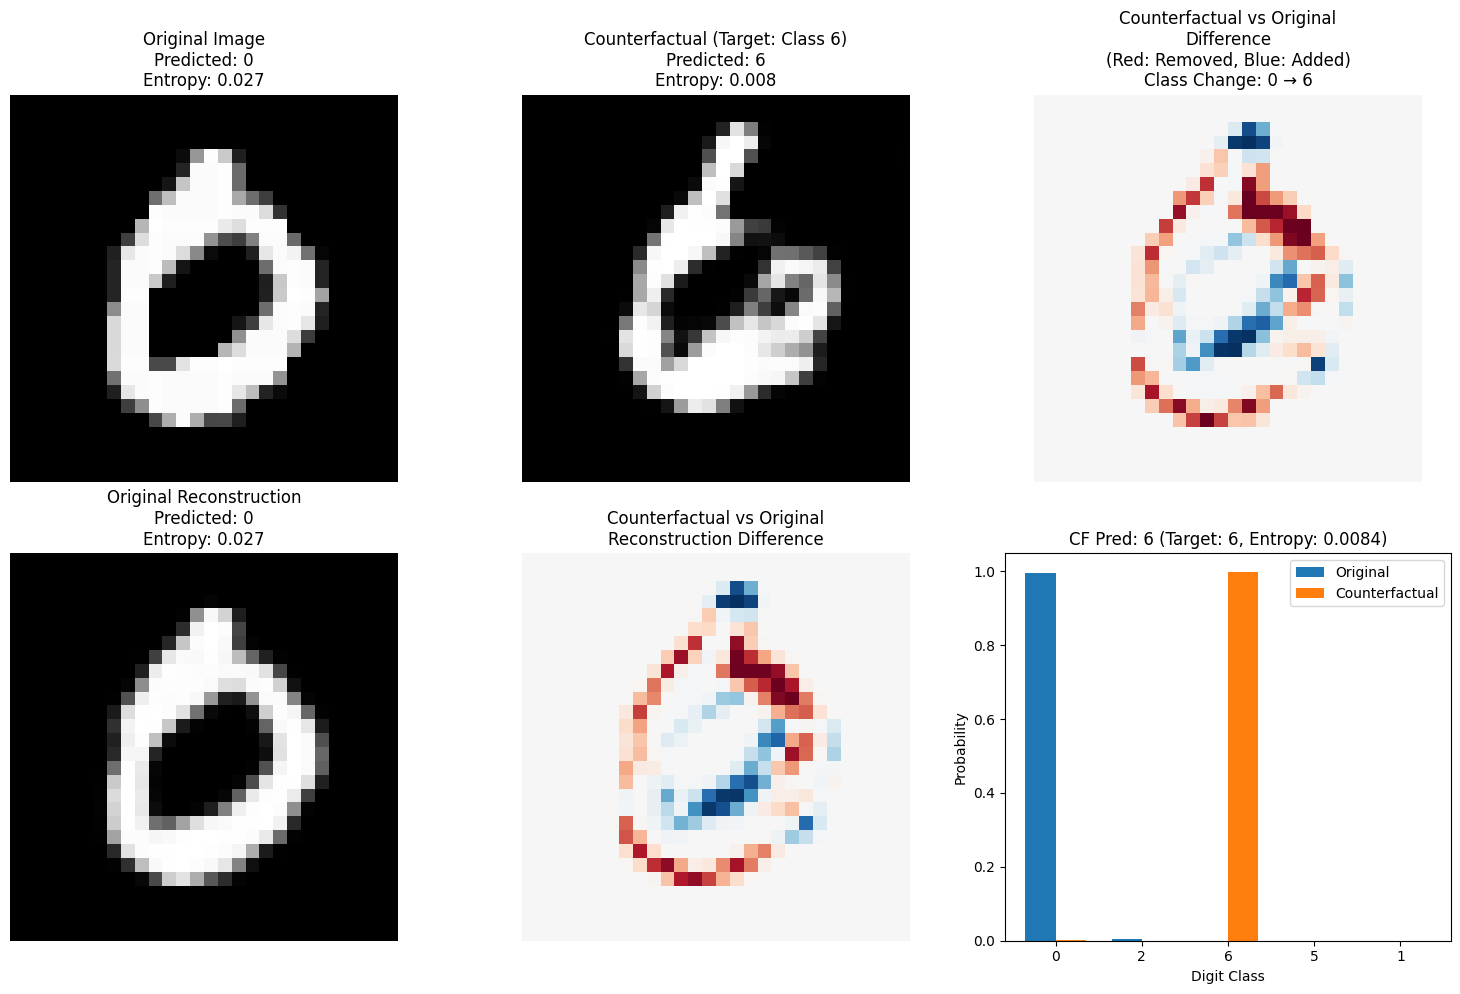

Final target class probability: 0.9998, Distance: 54.5862


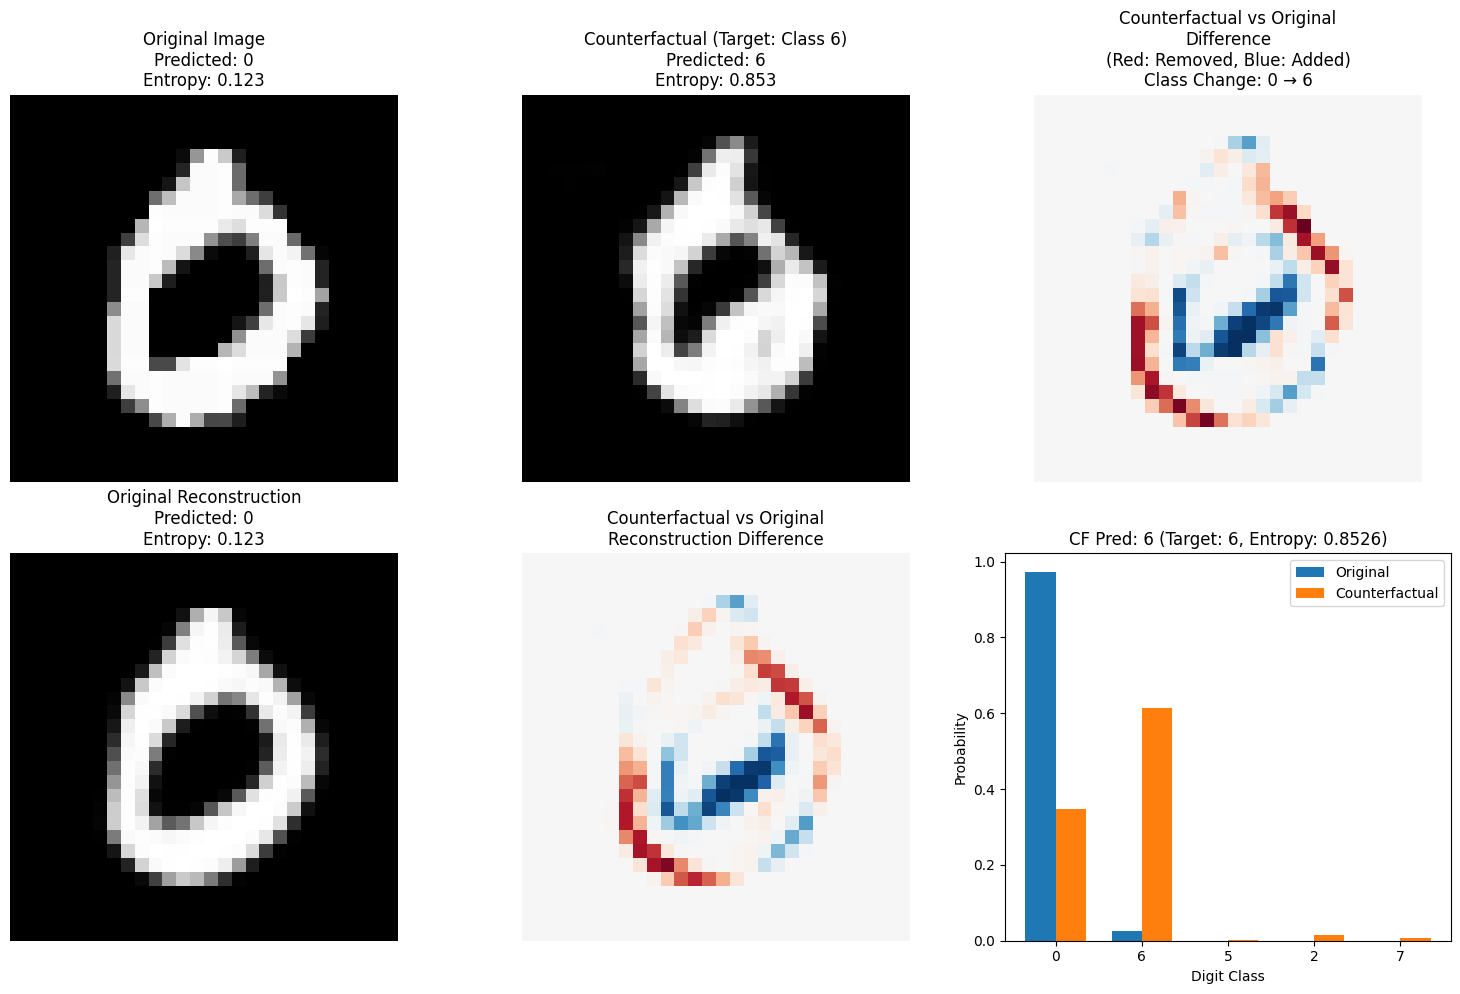

In [62]:


from clue.evaluate_CLUE import evaluate_single_auxiliary_clue_counterfactual, evaluate_single_clue_counterfactual
importlib.reload(clue.evaluate_CLUE)
import clue.new_CLUE
importlib.reload(clue.new_CLUE)
import models.BLL_VI
importlib.reload(models.BLL_VI)

bayesian = True

if bayesian:
    model = second_bll_vi
else:
    model = second_backbone

image, label = testloader.dataset[3]
target_class = 6

unsupervised_results, unsupervised_figure = evaluate_single_auxiliary_clue_counterfactual(
    image,
    model,
    autoencoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

supervised_results, supervised_figure = evaluate_single_clue_counterfactual(
    image,
    model,
    second_decoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

In [1]:


from clue.evaluate_CLUE import evaluate_single_auxiliary_clue_counterfactual, evaluate_single_clue_counterfactual
importlib.reload(clue.evaluate_CLUE)
import clue.new_CLUE
importlib.reload(clue.new_CLUE)
import models.BLL_VI
importlib.reload(models.BLL_VI)

bayesian = False 

if bayesian:
    model = second_bll_vi
else:
    model = second_backbone

image, label = testloader.dataset[3]
target_class = 6

unsupervised_results_deterministic, unsupervised_figure_deterministic = evaluate_single_auxiliary_clue_counterfactual(
    image,
    model,
    autoencoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

supervised_results_deterministic, supervised_figure_deterministic = evaluate_single_clue_counterfactual(
    image,
    model,
    second_decoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

bayesian = True 

if bayesian:
    model = second_bll_vi
else:
    model = second_backbone

unsupervised_results_bayesian, unsupervised_figure_bayesian = evaluate_single_auxiliary_clue_counterfactual(
    image,
    model,
    autoencoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

supervised_results_bayesian, supervised_figure_bayesian = evaluate_single_clue_counterfactual(
    image,
    model,
    second_decoder,
    device=cfg.device,
    verbose=False,
    steps=150,
    distance_weight=0.001,
    lr=0.4,
    bayesian=bayesian,
    target_class=target_class,
    vae=vae,
    counterfactual_scorer=class_autoencoders
)

ModuleNotFoundError: No module named 'clue'

In [100]:
unsupervised_recon_realism_dif = unsupervised_results['recon_counterfactual_realism_difference']
supervised_recon_realism_dif = supervised_results['recon_counterfactual_realism_difference']

unsupervised_realism_dif = unsupervised_results['realism_score_difference']
supervised_realism_dif = supervised_results['realism_score_difference']

unsupervised_im1 = unsupervised_results['im1_score']
supervised_im1 = supervised_results['im1_score']

print(f"Unsupervised Recon Realism Difference: {unsupervised_recon_realism_dif:.6f}")
print(f"Supervised Recon Realism Difference: {supervised_recon_realism_dif:.6f}")

print(f"Unsupervised Realism Difference: {unsupervised_realism_dif:.6f}")
print(f"Supervised Realism Difference: {supervised_realism_dif:.6f}")

print(f"Unsupervised IM1 Score: {unsupervised_im1:.6f}")
print(f"Supervised IM1 Score: {supervised_im1:.6f}")



Unsupervised Recon Realism Difference: 0.040903
Supervised Recon Realism Difference: 0.024676
Unsupervised Realism Difference: 0.041537
Supervised Realism Difference: 0.028424
Unsupervised IM1 Score: 0.711863
Supervised IM1 Score: 1.634737


Loading autoencoder for digit 0...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_0.pth
Loading autoencoder for digit 1...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_1.pth
Loading autoencoder for digit 2...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_2.pth
Loading autoencoder for digit 3...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_3.pth
Loading autoencoder for digit 4...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_4.pth
Loading autoencoder for digit 5...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_5.pth
Loading autoencoder for digit 6...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_6.pth
Loading autoencoder for digit 7...
Model loaded from ../model_saves/im1_autoencoders/mnist_autoencoder_class_7.pth
Loading autoencoder for digit 8...
Model loaded from ../model_saves/im1_autoenco

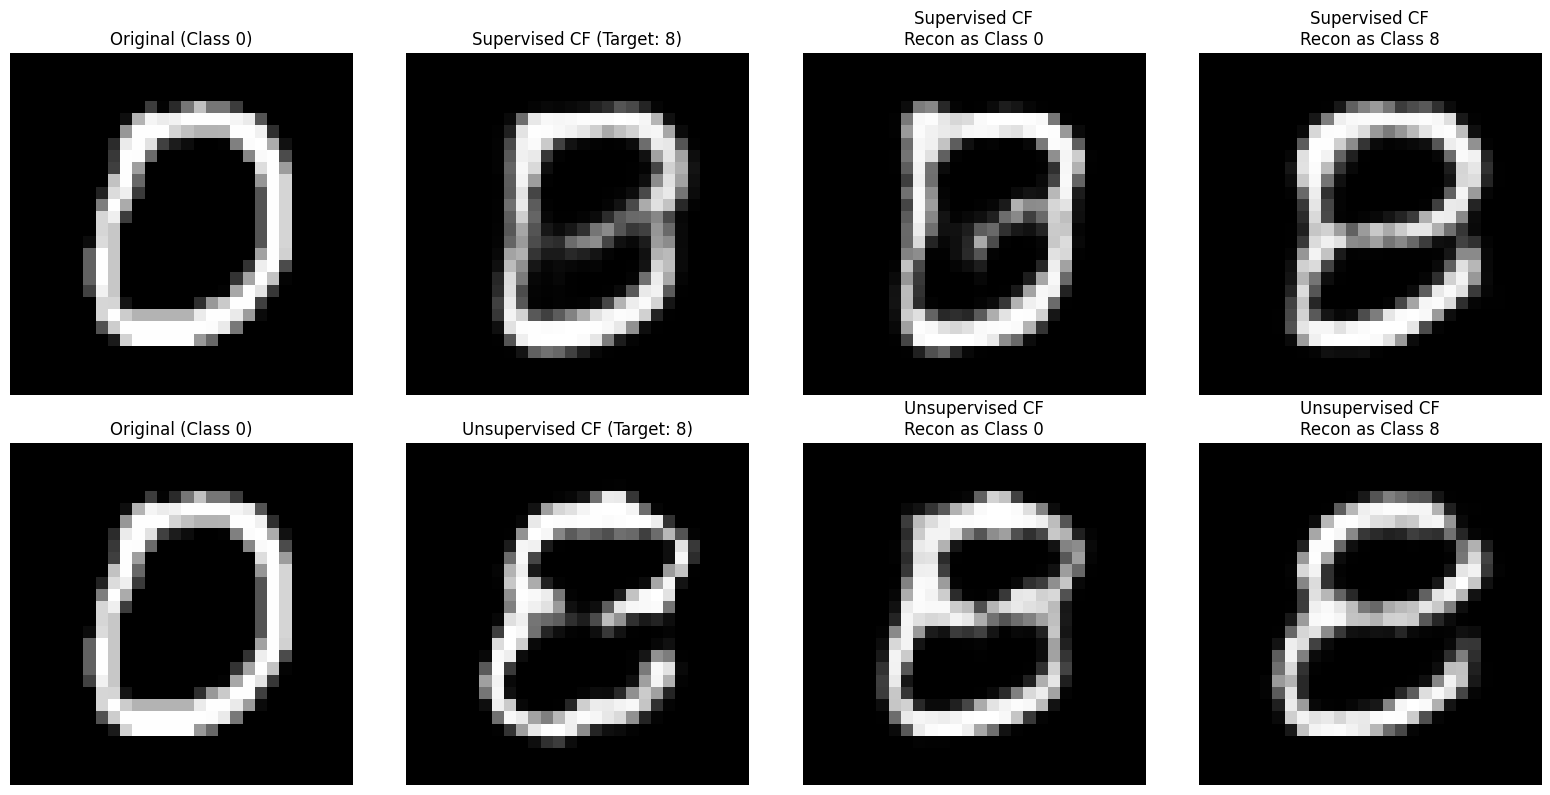

In [71]:
# Import the counterfactual scorer
import models.counterfactual_scorer
importlib.reload(models.counterfactual_scorer)
from models.counterfactual_scorer import MNISTClassAutoencoders

# Initialize the class autoencoders with the correct model path
models_dir = '../model_saves/im1_autoencoders'
class_autoencoders = MNISTClassAutoencoders(latent_dim=32, device=cfg.device, models_dir=models_dir)

# Load the pre-trained models
try:
    class_autoencoders.load_models()
    print("Class-specific autoencoder models loaded successfully from", models_dir)
except Exception as e:
    print(f"Error loading class autoencoder models: {e}")
    print("Some models may not be initialized")

# Calculate IM1 score for both counterfactual images
original_img = image.unsqueeze(0).to(cfg.device)

# Compare supervised and unsupervised counterfactuals
supervised_cf = supervised_results['counterfactual_image'].to(cfg.device)
unsupervised_cf = unsupervised_results['counterfactual_image'].to(cfg.device)

# Calculate IM1 scores (lower is better, indicates a more realistic counterfactual)
supervised_im1 = class_autoencoders.calculate_im1(
    supervised_cf, 
    original_class=label, 
    counterfactual_class=target_class
)

unsupervised_im1 = class_autoencoders.calculate_im1(
    unsupervised_cf, 
    original_class=label, 
    counterfactual_class=target_class
)

print(f"Original class: {label}")
print(f"Counterfactual class: {target_class}")
print(f"Supervised IM1 Score: {supervised_im1:.6f} (lower is better)")
print(f"Unsupervised IM1 Score: {unsupervised_im1:.6f} (lower is better)")

# Get reconstructions from both class-specific autoencoders for both counterfactuals
supervised_orig_recon = class_autoencoders.get_reconstruction(supervised_cf, label)
supervised_cf_recon = class_autoencoders.get_reconstruction(supervised_cf, target_class)

unsupervised_orig_recon = class_autoencoders.get_reconstruction(unsupervised_cf, label)
unsupervised_cf_recon = class_autoencoders.get_reconstruction(unsupervised_cf, target_class)

# Visualize the original, counterfactuals, and their reconstructions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original image
axes[0, 0].imshow(original_img.cpu().squeeze().numpy(), cmap='gray')
axes[0, 0].set_title(f"Original (Class {label})")
axes[0, 0].axis('off')

# Supervised counterfactual
axes[0, 1].imshow(supervised_cf.cpu().squeeze().numpy(), cmap='gray')
axes[0, 1].set_title(f"Supervised CF (Target: {target_class})")
axes[0, 1].axis('off')

# Supervised reconstructions
axes[0, 2].imshow(supervised_orig_recon.cpu().squeeze().numpy(), cmap='gray')
axes[0, 2].set_title(f"Supervised CF\nRecon as Class {label}")
axes[0, 2].axis('off')

axes[0, 3].imshow(supervised_cf_recon.cpu().squeeze().numpy(), cmap='gray')
axes[0, 3].set_title(f"Supervised CF\nRecon as Class {target_class}")
axes[0, 3].axis('off')

# Unsupervised counterfactual
axes[1, 0].imshow(original_img.cpu().squeeze().numpy(), cmap='gray')
axes[1, 0].set_title(f"Original (Class {label})")
axes[1, 0].axis('off')

axes[1, 1].imshow(unsupervised_cf.cpu().squeeze().numpy(), cmap='gray')
axes[1, 1].set_title(f"Unsupervised CF (Target: {target_class})")
axes[1, 1].axis('off')

# Unsupervised reconstructions
axes[1, 2].imshow(unsupervised_orig_recon.cpu().squeeze().numpy(), cmap='gray')
axes[1, 2].set_title(f"Unsupervised CF\nRecon as Class {label}")
axes[1, 2].axis('off')

axes[1, 3].imshow(unsupervised_cf_recon.cpu().squeeze().numpy(), cmap='gray')
axes[1, 3].set_title(f"Unsupervised CF\nRecon as Class {target_class}")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


### Test multiple

In [72]:
# Get 50 random images from the test set
import random
import torch

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

# Number of images to select
num_images = 50

# Get random indices from the test set
random_indices = random.sample(range(len(testset)), num_images)

# Get the images and their true labels
random_images = []
true_labels = []

for idx in random_indices:
    img, label = testset[idx]
    random_images.append(img.unsqueeze(0))  # Add batch dimension
    true_labels.append(label)

# Stack images into a single tensor
random_images = torch.cat(random_images, dim=0)

# Generate random target labels that are different from the true labels
target_labels = []
for true_label in true_labels:
    # Get all possible labels except the true one
    possible_labels = list(range(10))  # Assuming 10 classes (0-9) for MNIST
    possible_labels.remove(true_label)
    # Randomly select one of the remaining labels
    target_label = random.choice(possible_labels)
    target_labels.append(target_label)

print(f"Selected {num_images} random images with their true labels:")
print(f"True labels: {true_labels}")
print(f"Target labels: {target_labels}")



Selected 50 random images with their true labels:
True labels: [2, 1, 2, 4, 6, 6, 4, 9, 1, 1, 2, 8, 9, 0, 1, 2, 8, 8, 9, 6, 2, 9, 3, 2, 2, 3, 6, 2, 4, 4, 5, 3, 7, 3, 1, 1, 3, 1, 8, 8, 3, 9, 9, 5, 1, 3, 3, 0, 3, 7]
Target labels: [5, 6, 4, 1, 0, 3, 5, 1, 4, 2, 7, 4, 7, 6, 3, 6, 5, 3, 4, 1, 3, 8, 4, 3, 8, 7, 4, 9, 3, 6, 0, 4, 0, 6, 7, 5, 1, 4, 5, 3, 8, 6, 7, 2, 5, 2, 4, 9, 9, 4]


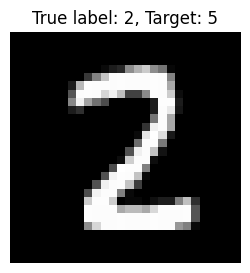

In [73]:
# Display the first random image
plt.figure(figsize=(3, 3))
plt.imshow(random_images[0].squeeze().cpu().numpy(), cmap='gray')
plt.title(f"True label: {true_labels[0]}, Target: {target_labels[0]}")
plt.axis('off')
plt.show()

Run multiple clue to test

bayesian version first

Final target class probability: 0.0000, Distance: 0.2506
Final target class probability: 1.0000, Distance: 55.0282
Final target class probability: 0.9884, Distance: 61.6475
Final target class probability: 0.9849, Distance: 67.4003
Final target class probability: 0.9815, Distance: 66.8677
Final target class probability: 0.9999, Distance: 65.1640
Final target class probability: 0.9901, Distance: 69.7184
Final target class probability: 0.9911, Distance: 84.7799
Final target class probability: 1.0000, Distance: 52.0052
Final target class probability: 1.0000, Distance: 50.1951
Final target class probability: 1.0000, Distance: 57.9271
Final target class probability: 0.9985, Distance: 55.7174
Final target class probability: 0.9999, Distance: 53.6841
Final target class probability: 0.9838, Distance: 64.3011
Final target class probability: 0.9999, Distance: 55.5621
Final target class probability: 0.9847, Distance: 64.7761
Final target class probability: 0.9901, Distance: 49.4179
Final target cl

/Users/conor/Documents/College terms/College/Thesis/ReportsAndCode/Bayesian-CE/MyImplementation/clue/evaluate_CLUE.py:703: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


Final target class probability: 0.9795, Distance: 60.1552
Final target class probability: 0.9618, Distance: 61.5188
Final target class probability: 0.9939, Distance: 57.7752
Final target class probability: 0.9910, Distance: 57.6682
Final target class probability: 0.9965, Distance: 64.7177
Final target class probability: 0.9994, Distance: 59.2888
Final target class probability: 0.9739, Distance: 61.4993
Final target class probability: 0.9999, Distance: 74.4879
Final target class probability: 0.9900, Distance: 67.2242
Final target class probability: 0.9874, Distance: 70.5876
Final target class probability: 0.9735, Distance: 59.7955
Final target class probability: 0.9720, Distance: 74.6550
Final target class probability: 0.9999, Distance: 63.8615
Final target class probability: 0.9796, Distance: 52.8630
Final target class probability: 1.0000, Distance: 50.7053
Final target class probability: 0.9798, Distance: 70.7034
Final target class probability: 1.0000, Distance: 55.9715
Final target c

KeyboardInterrupt: 

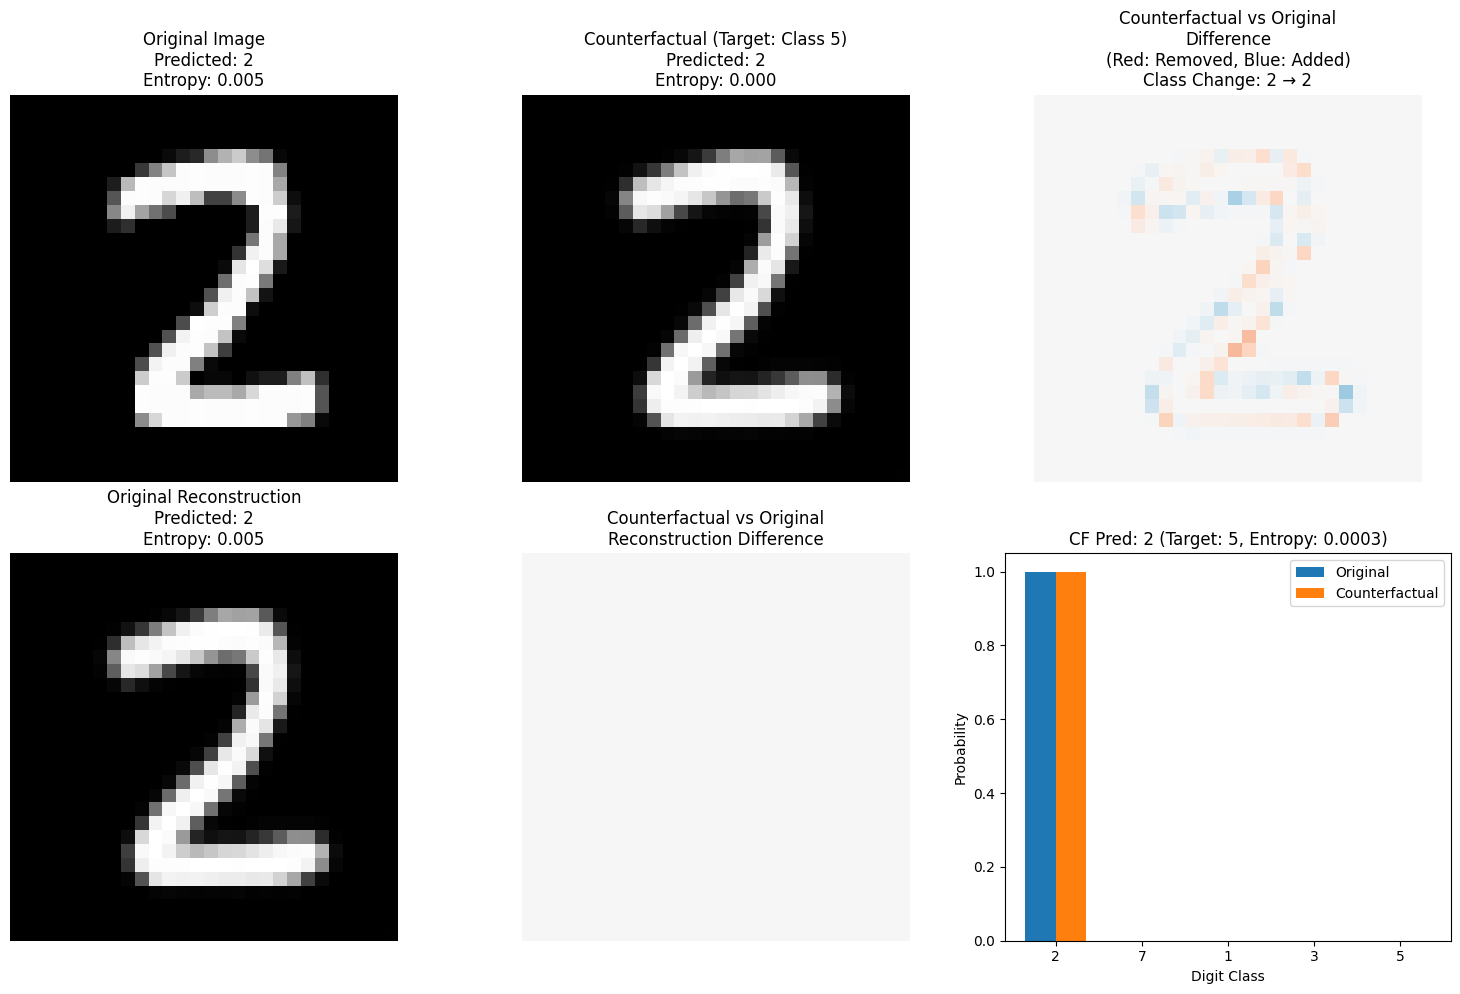

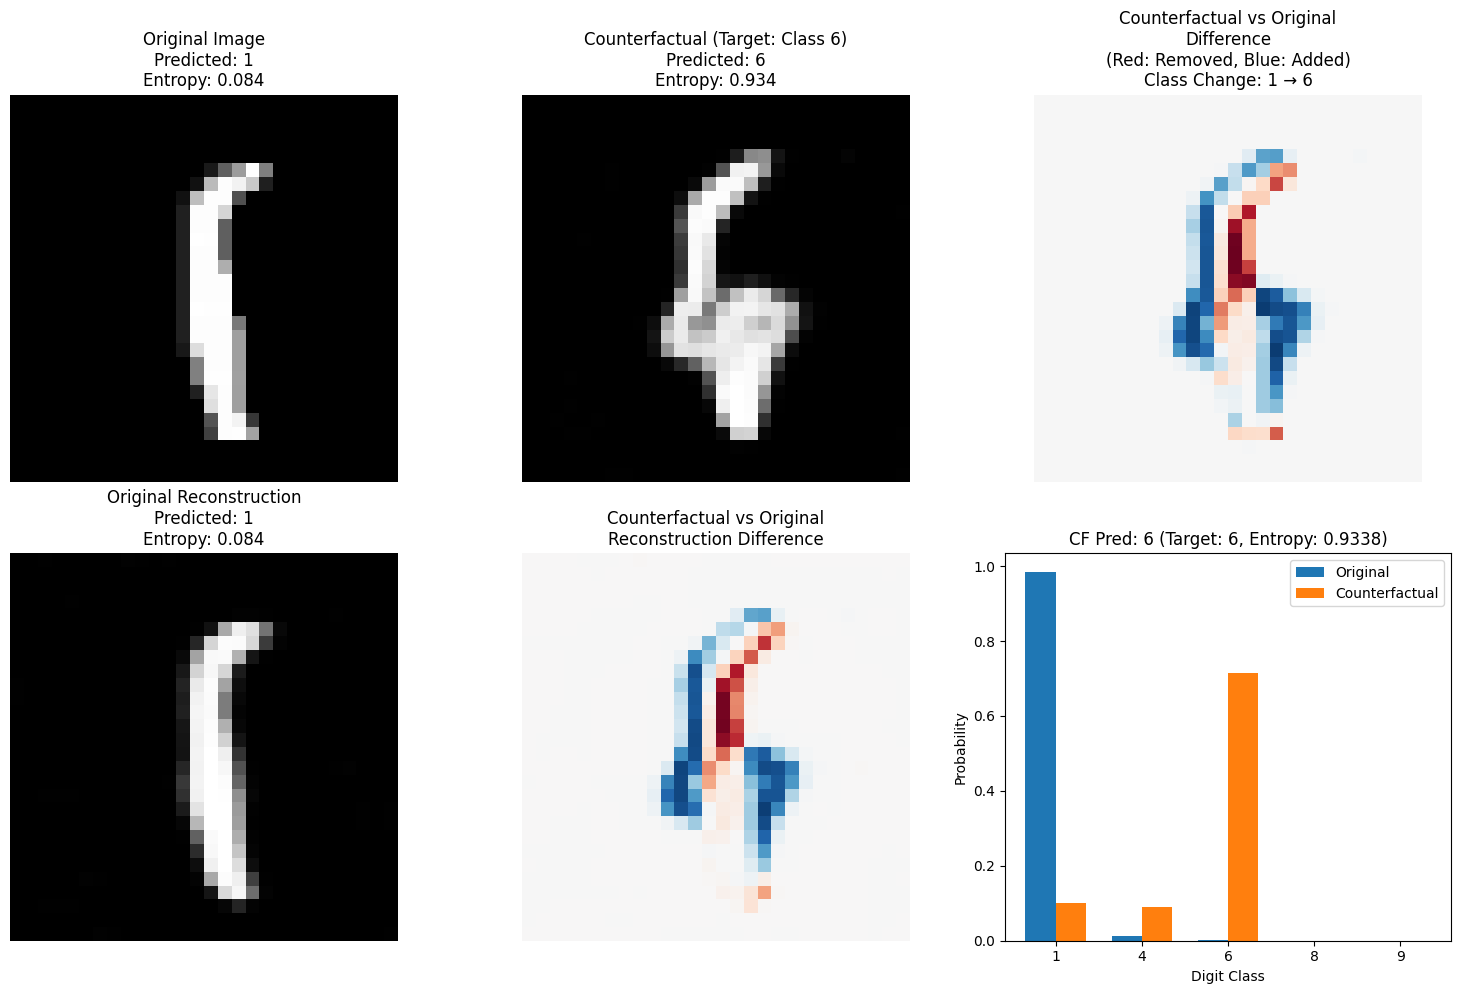

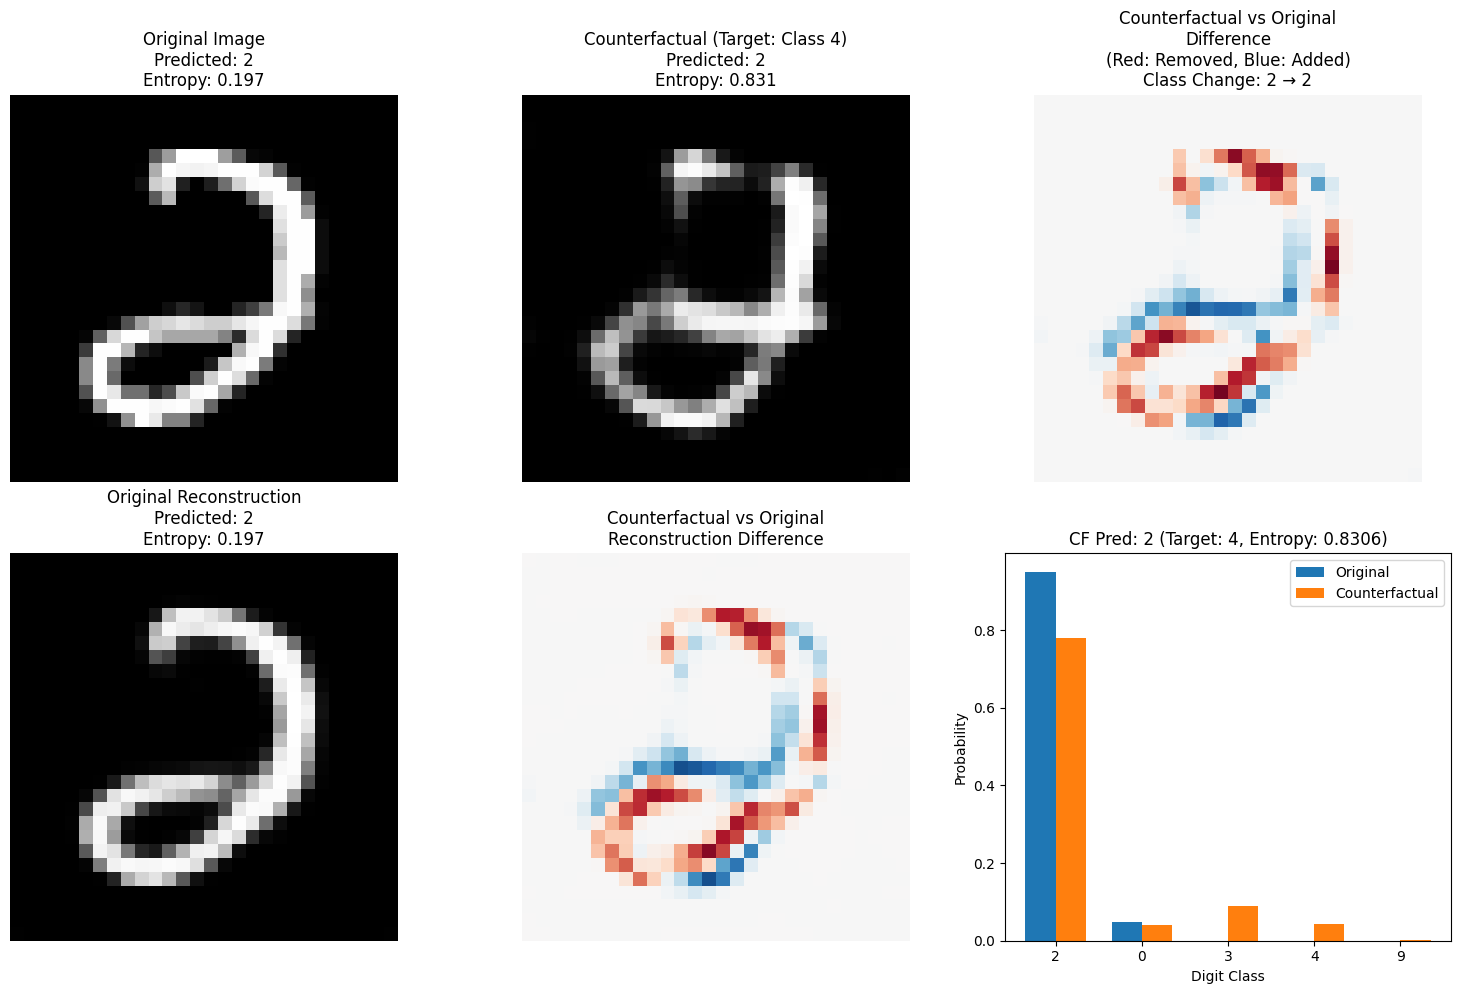

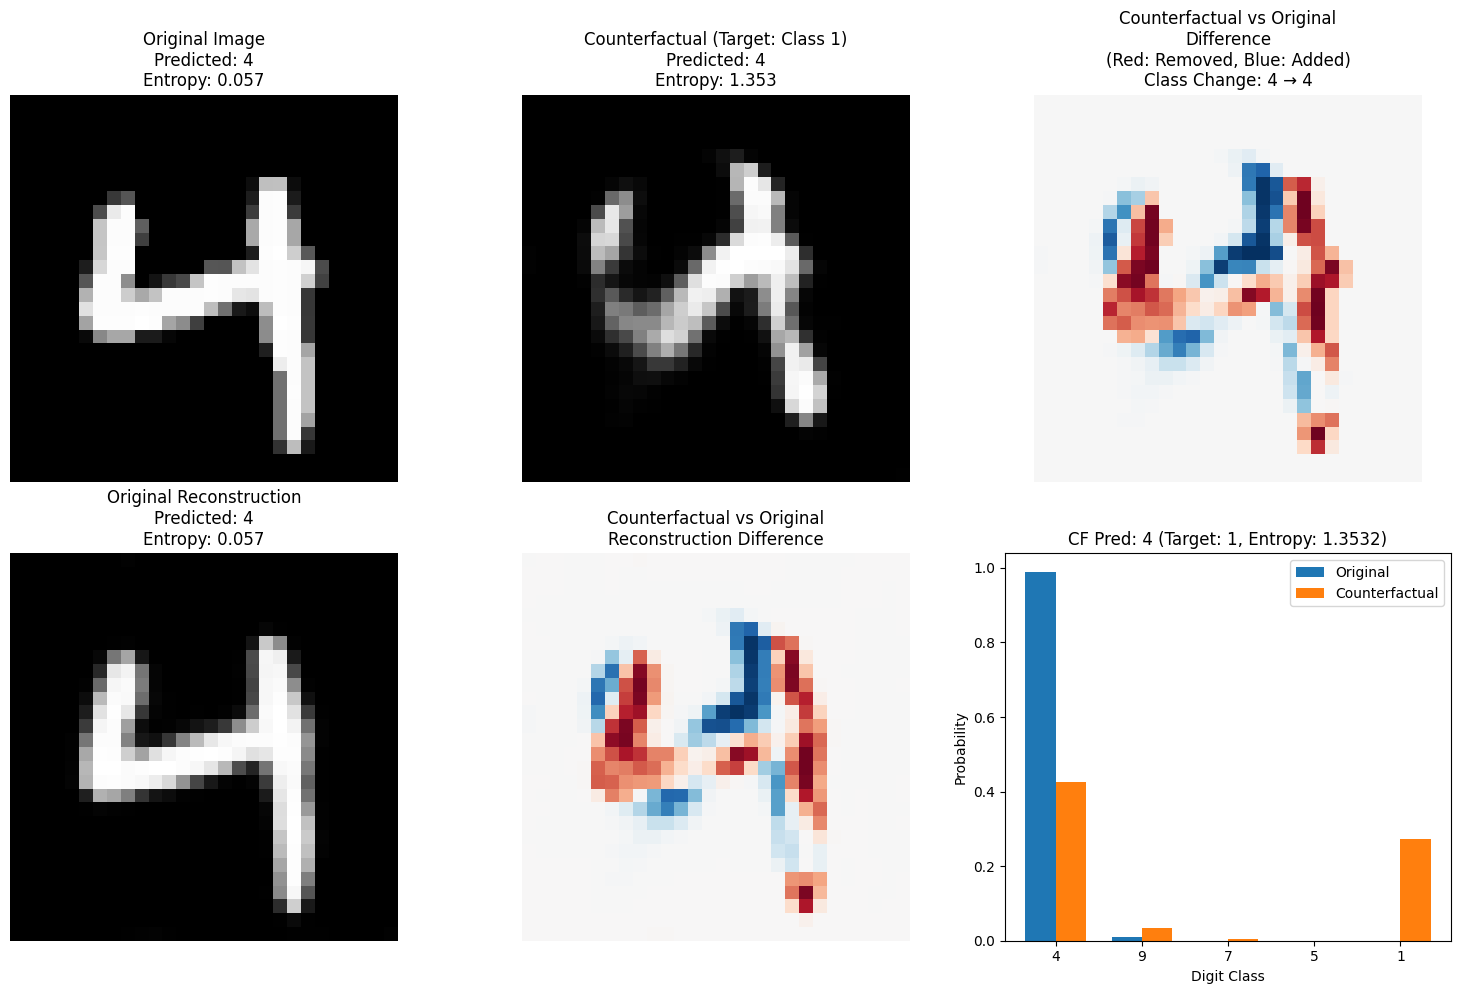

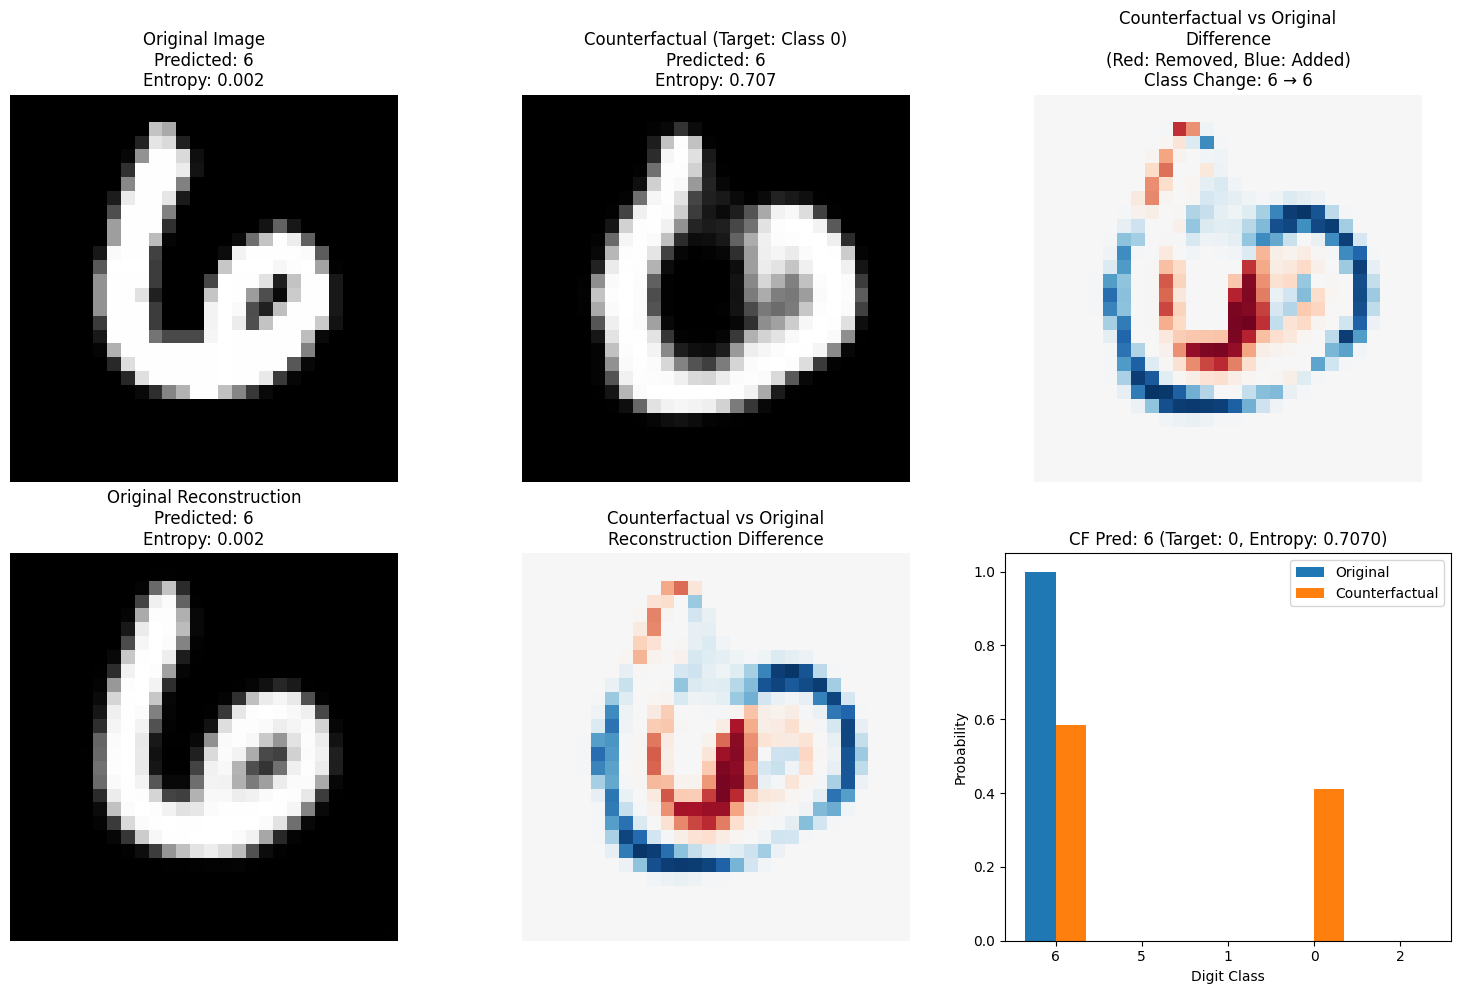

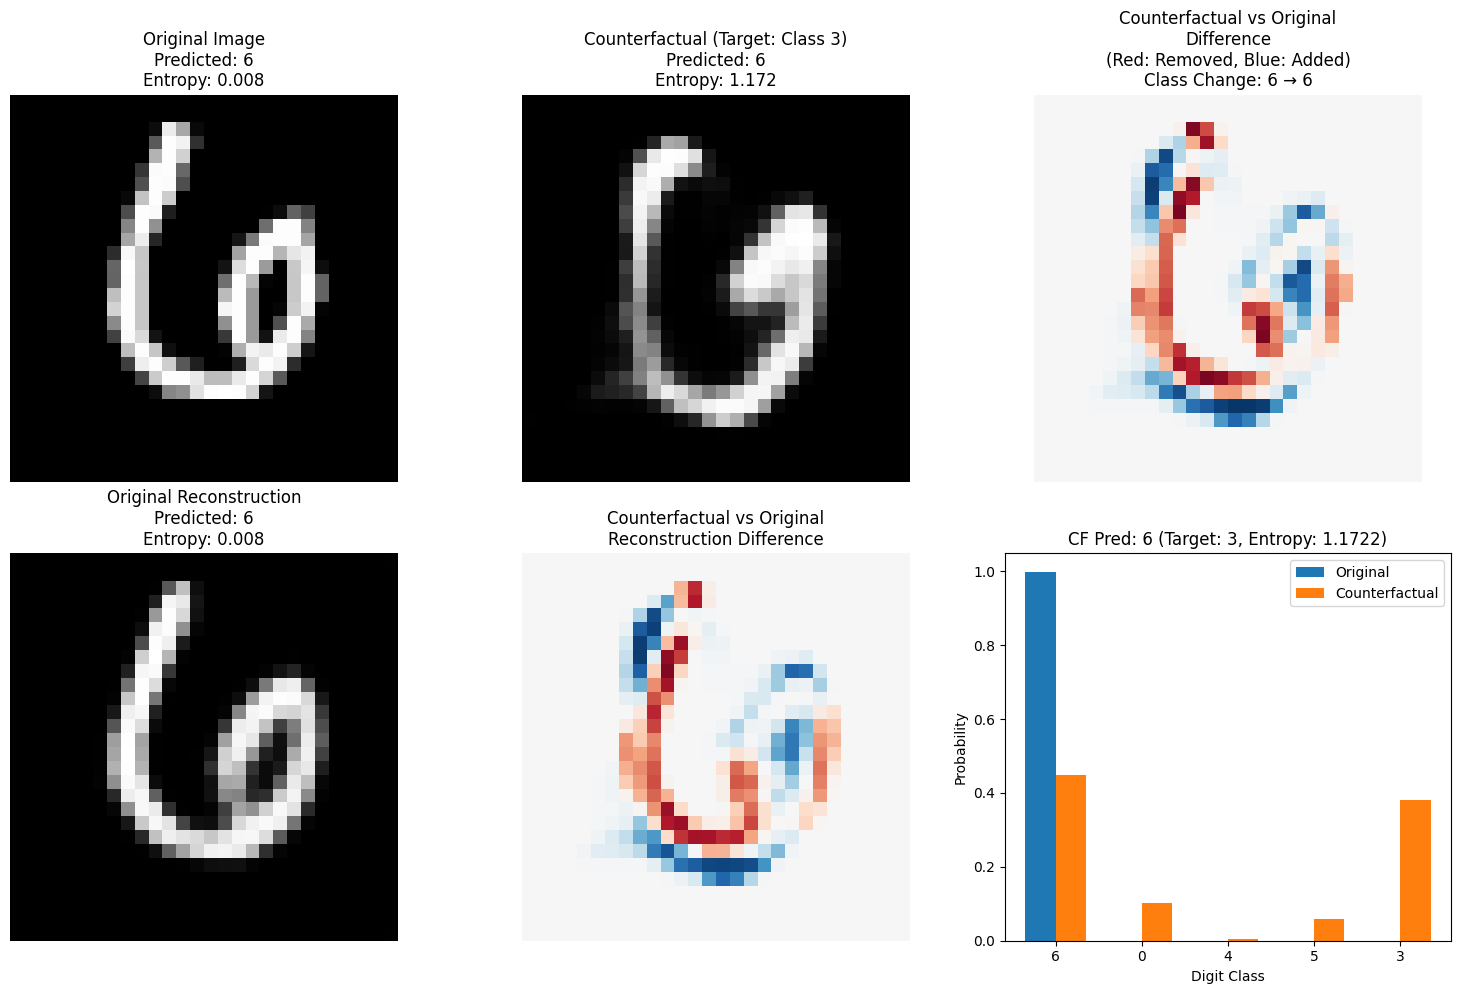

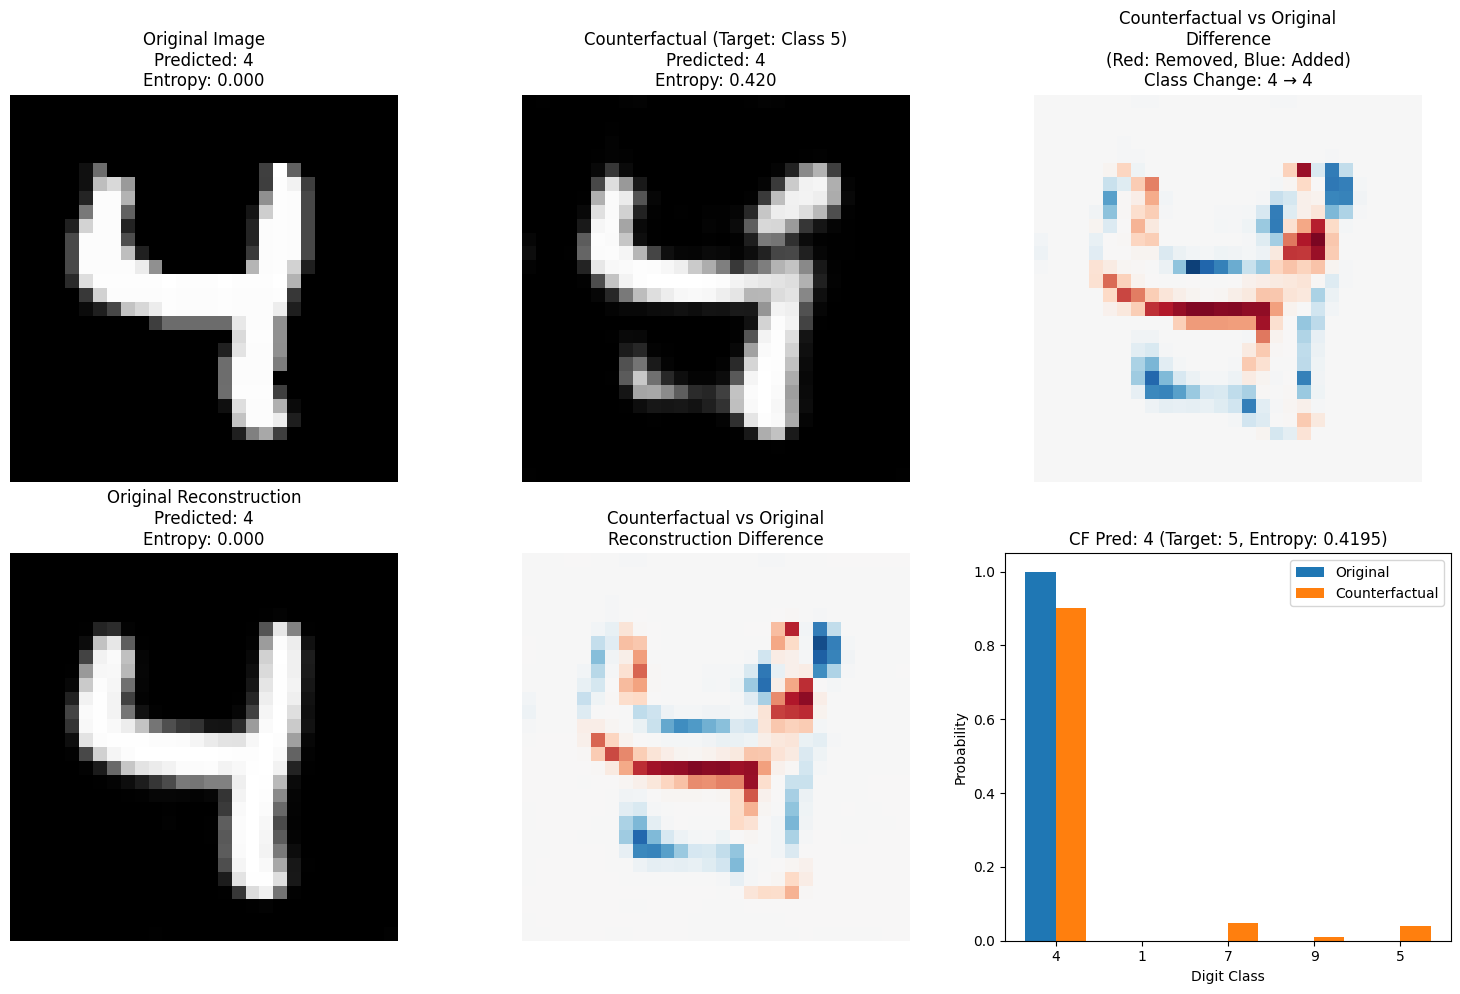

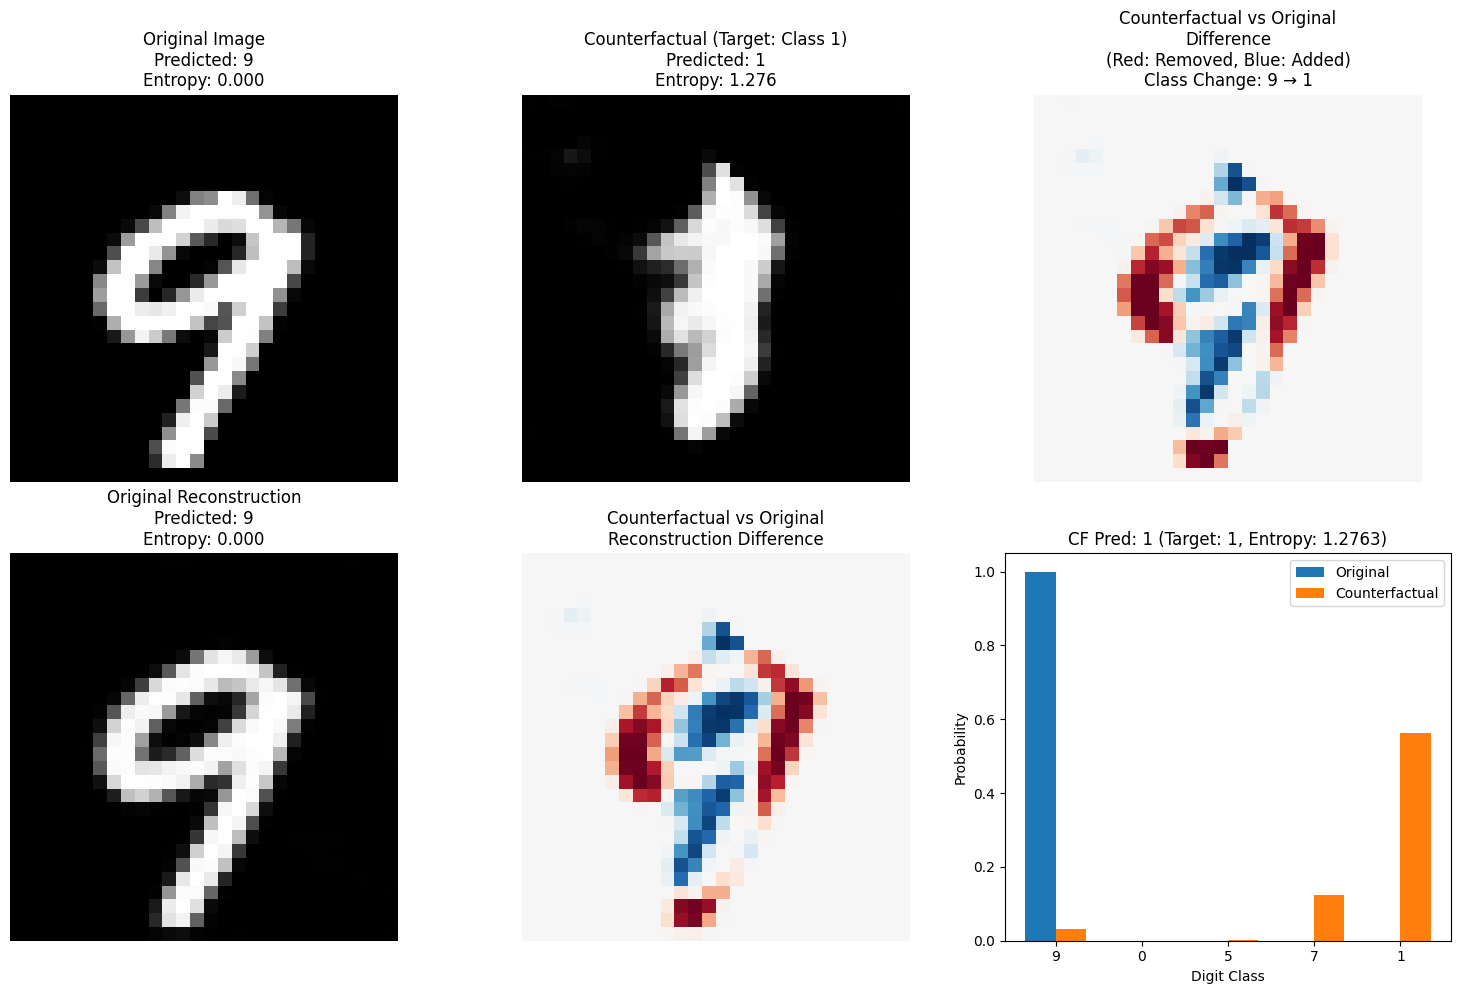

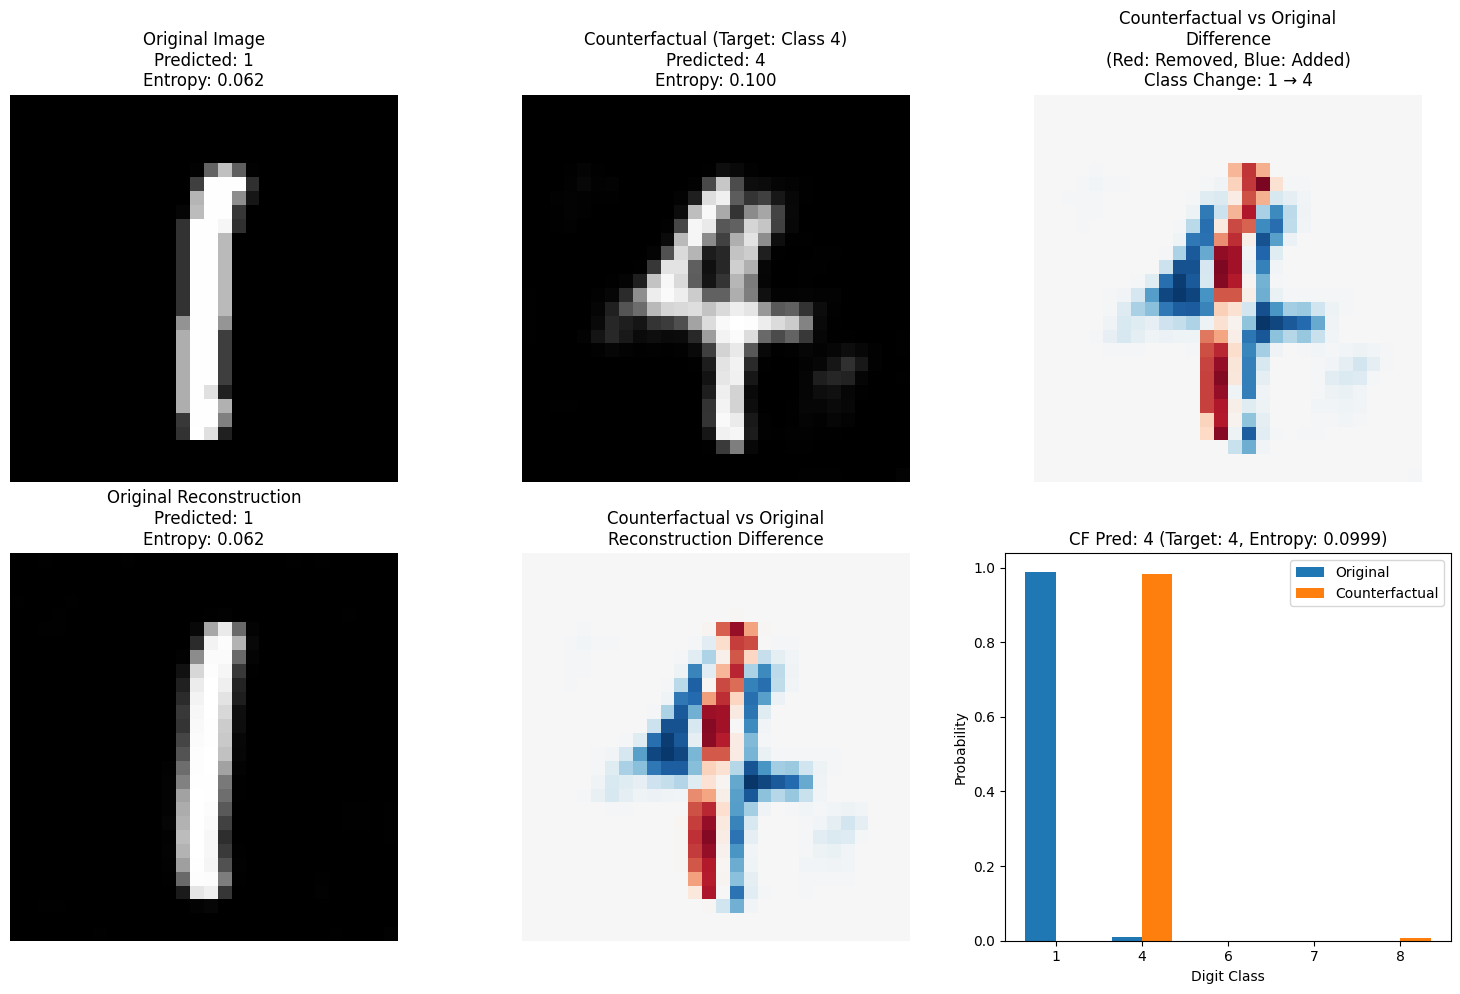

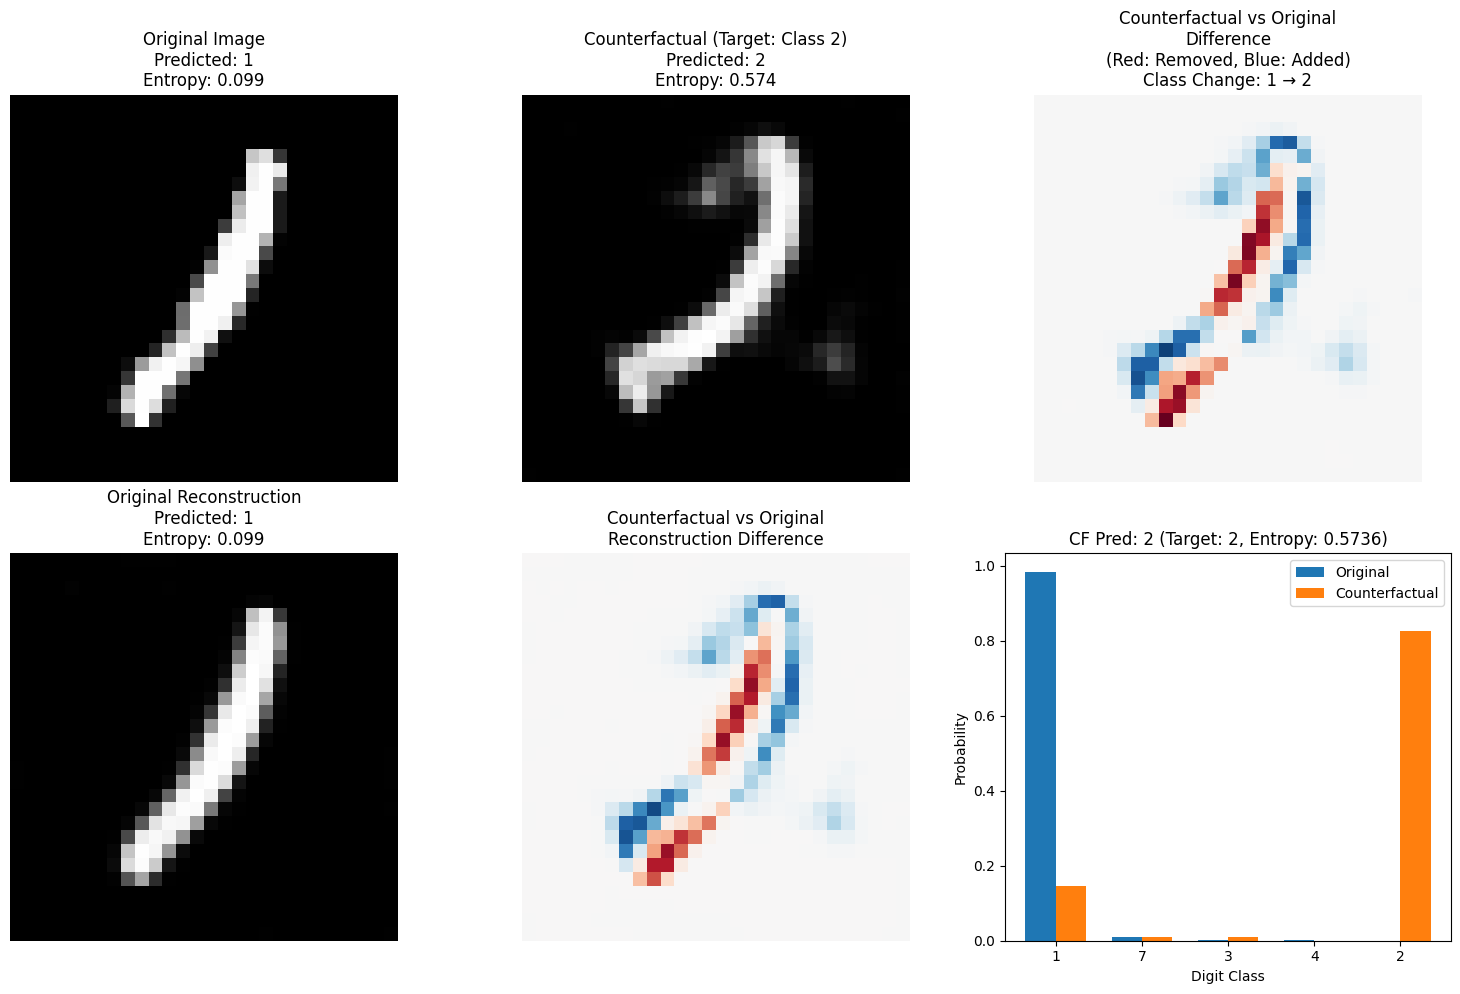

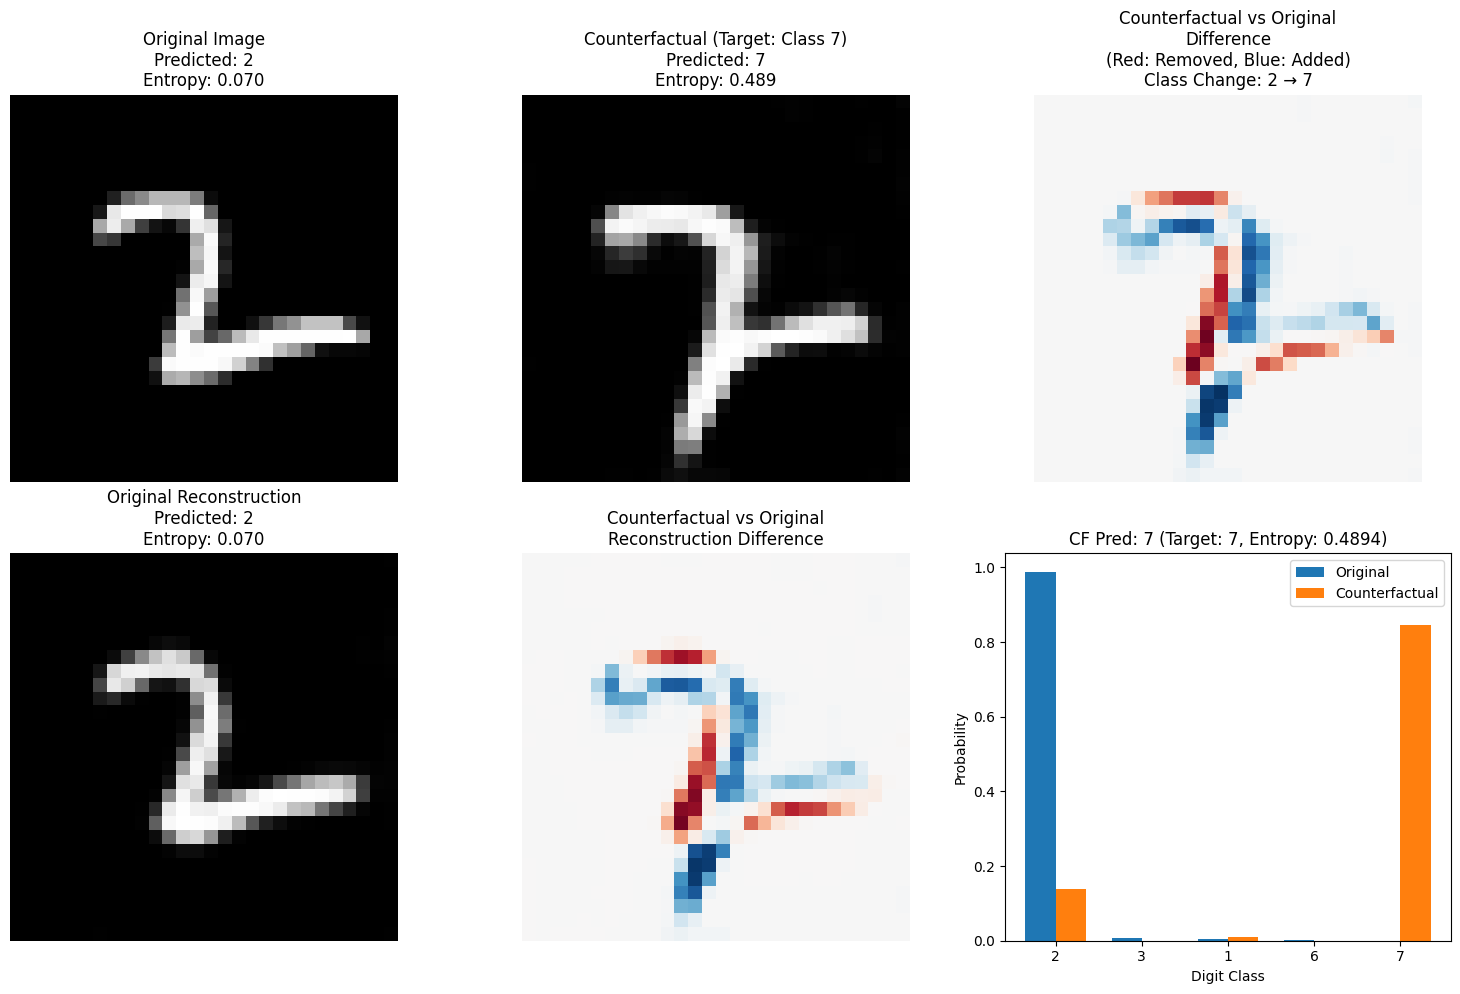

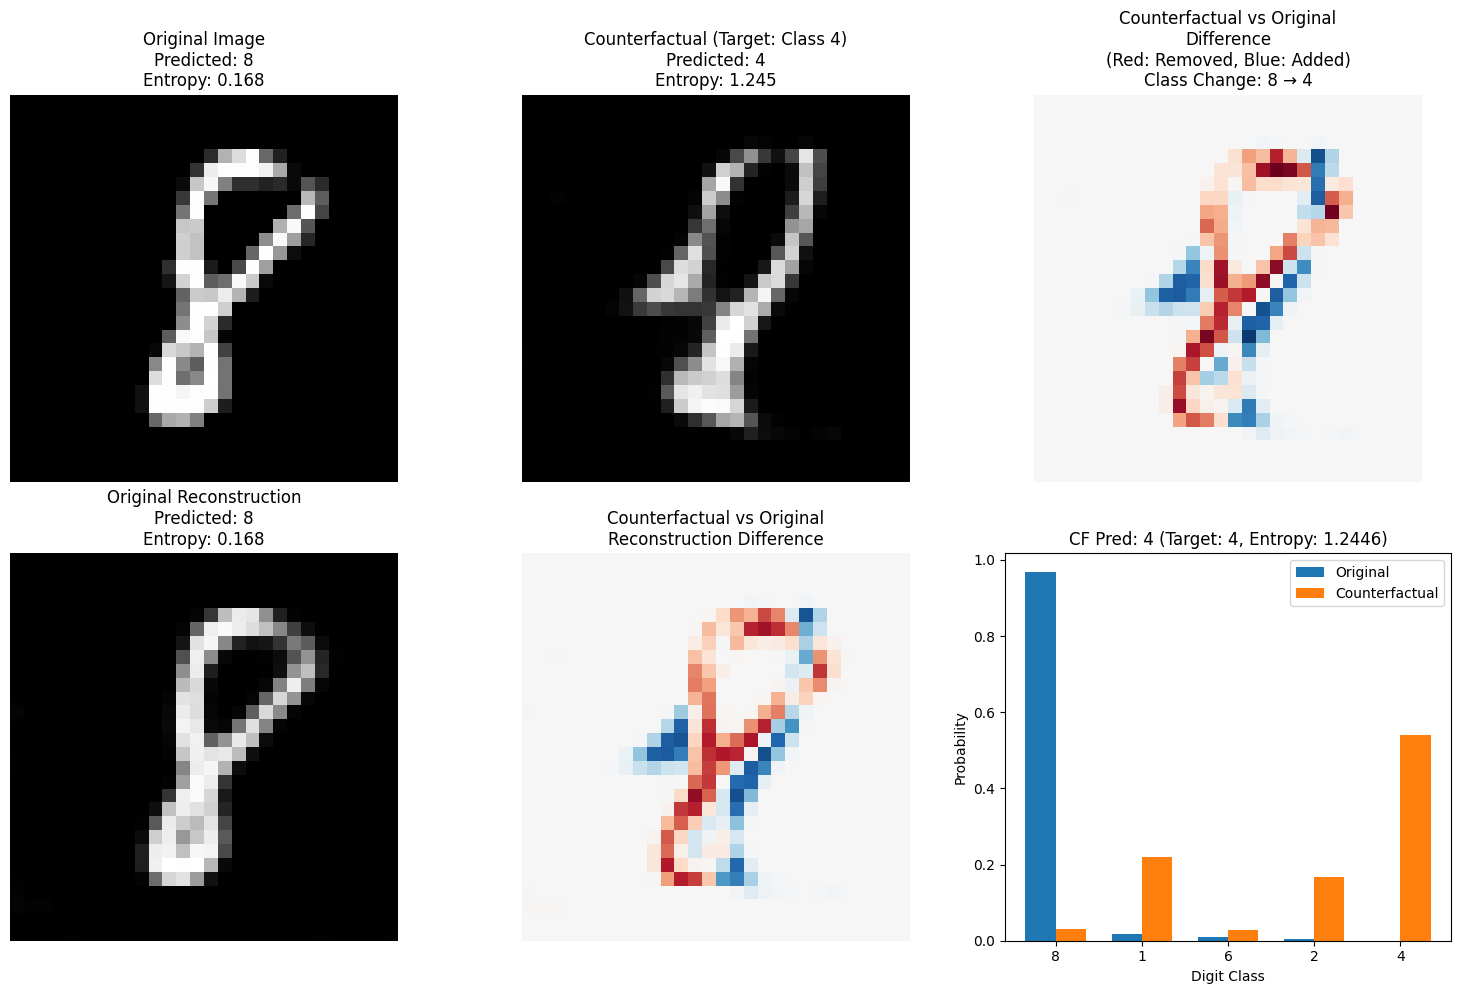

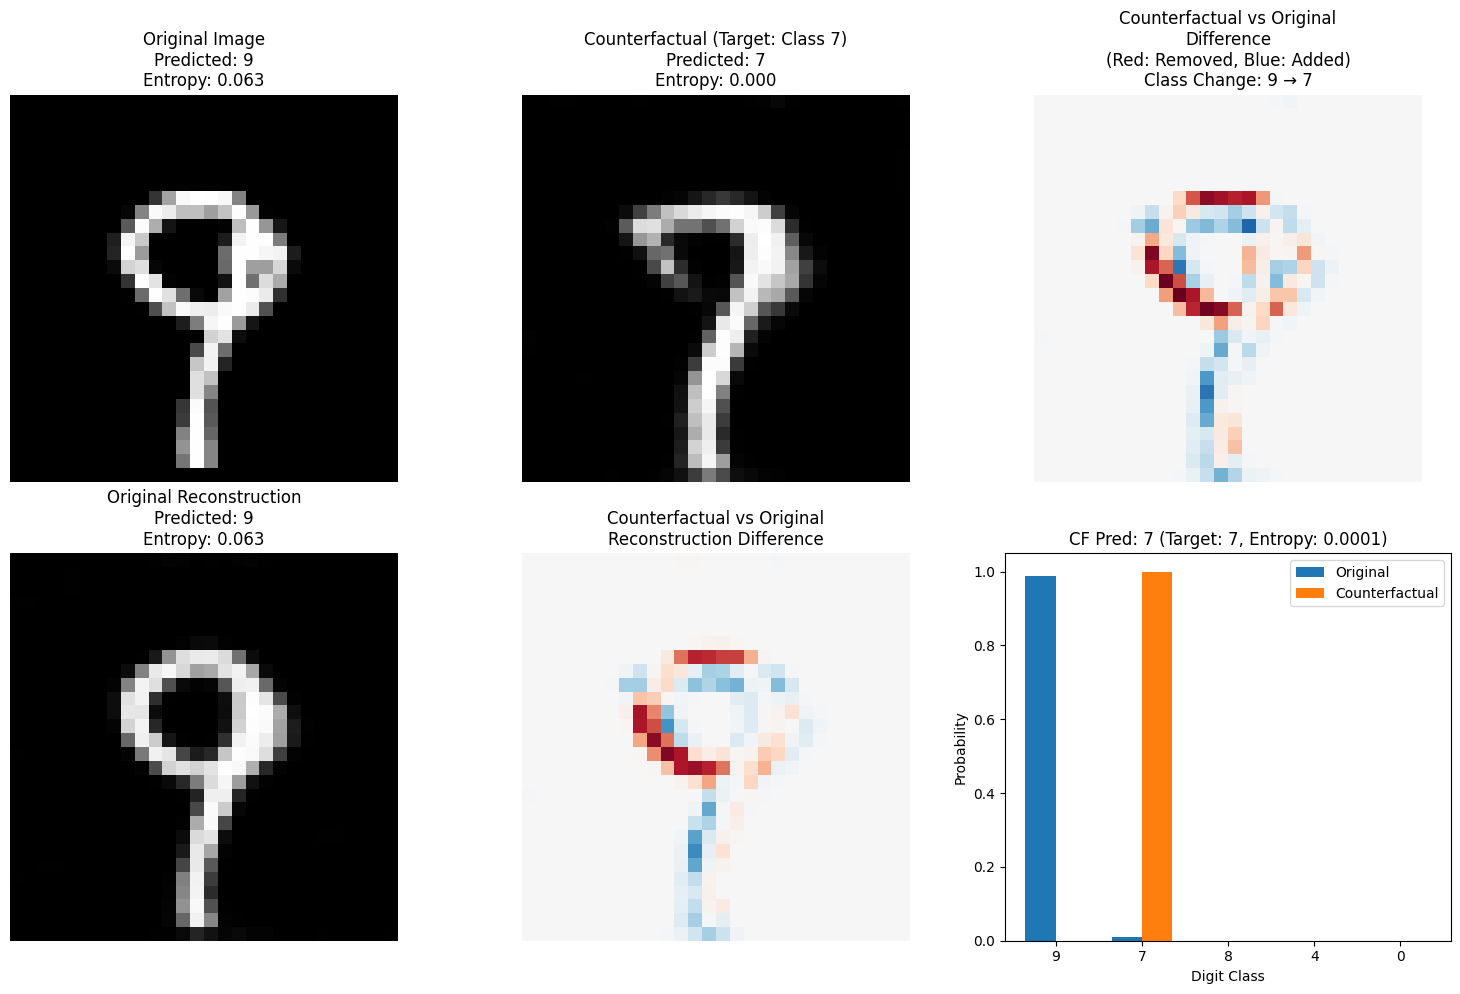

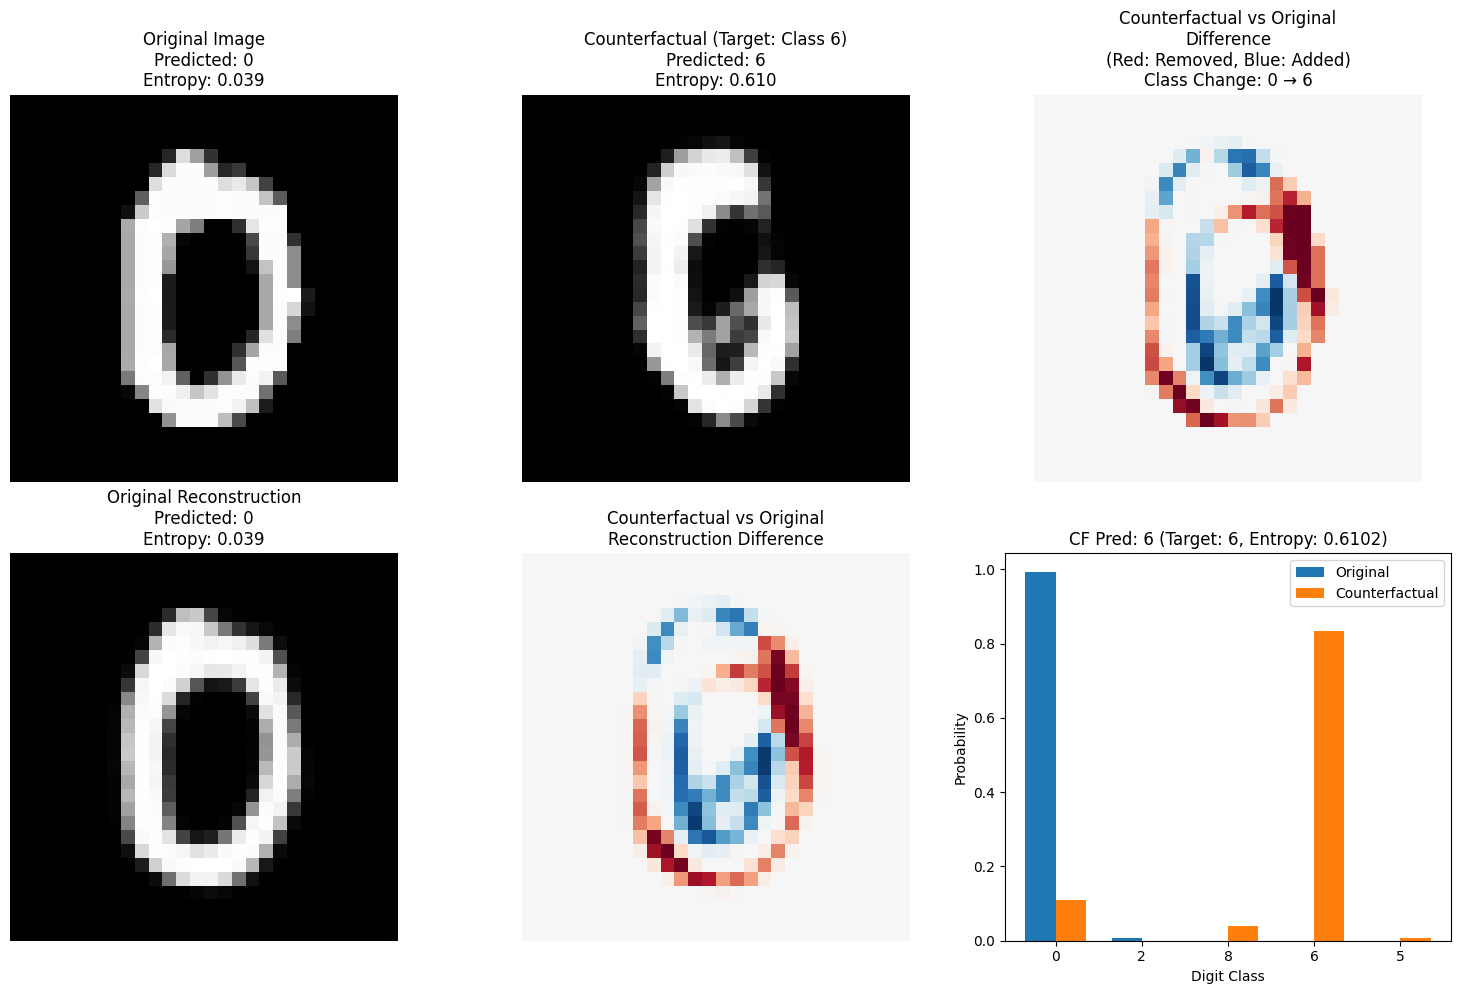

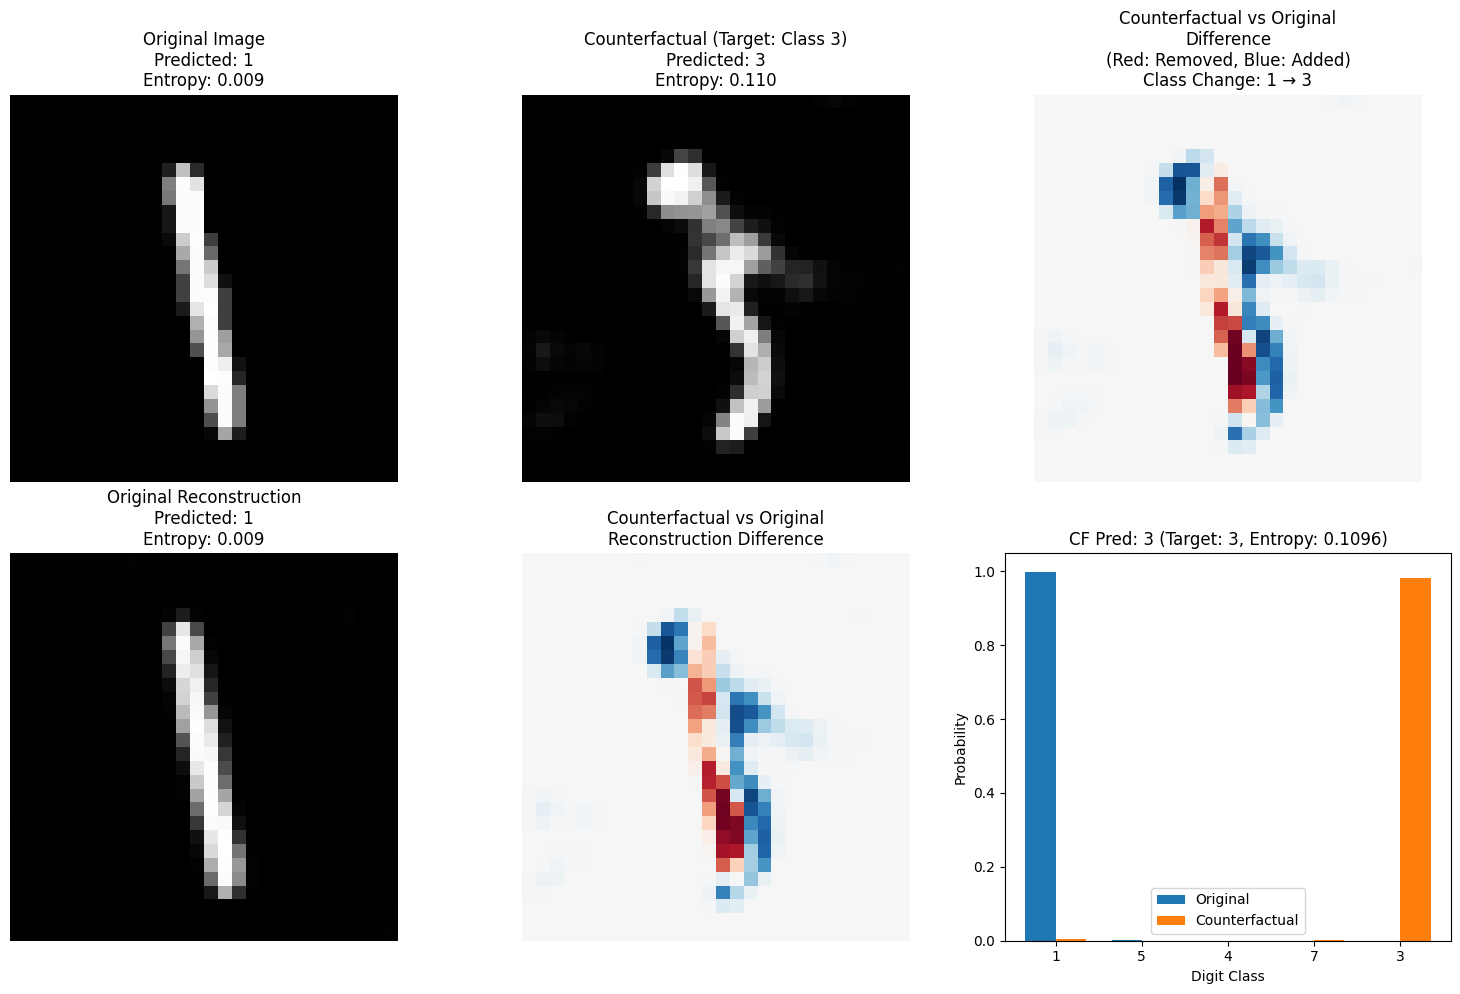

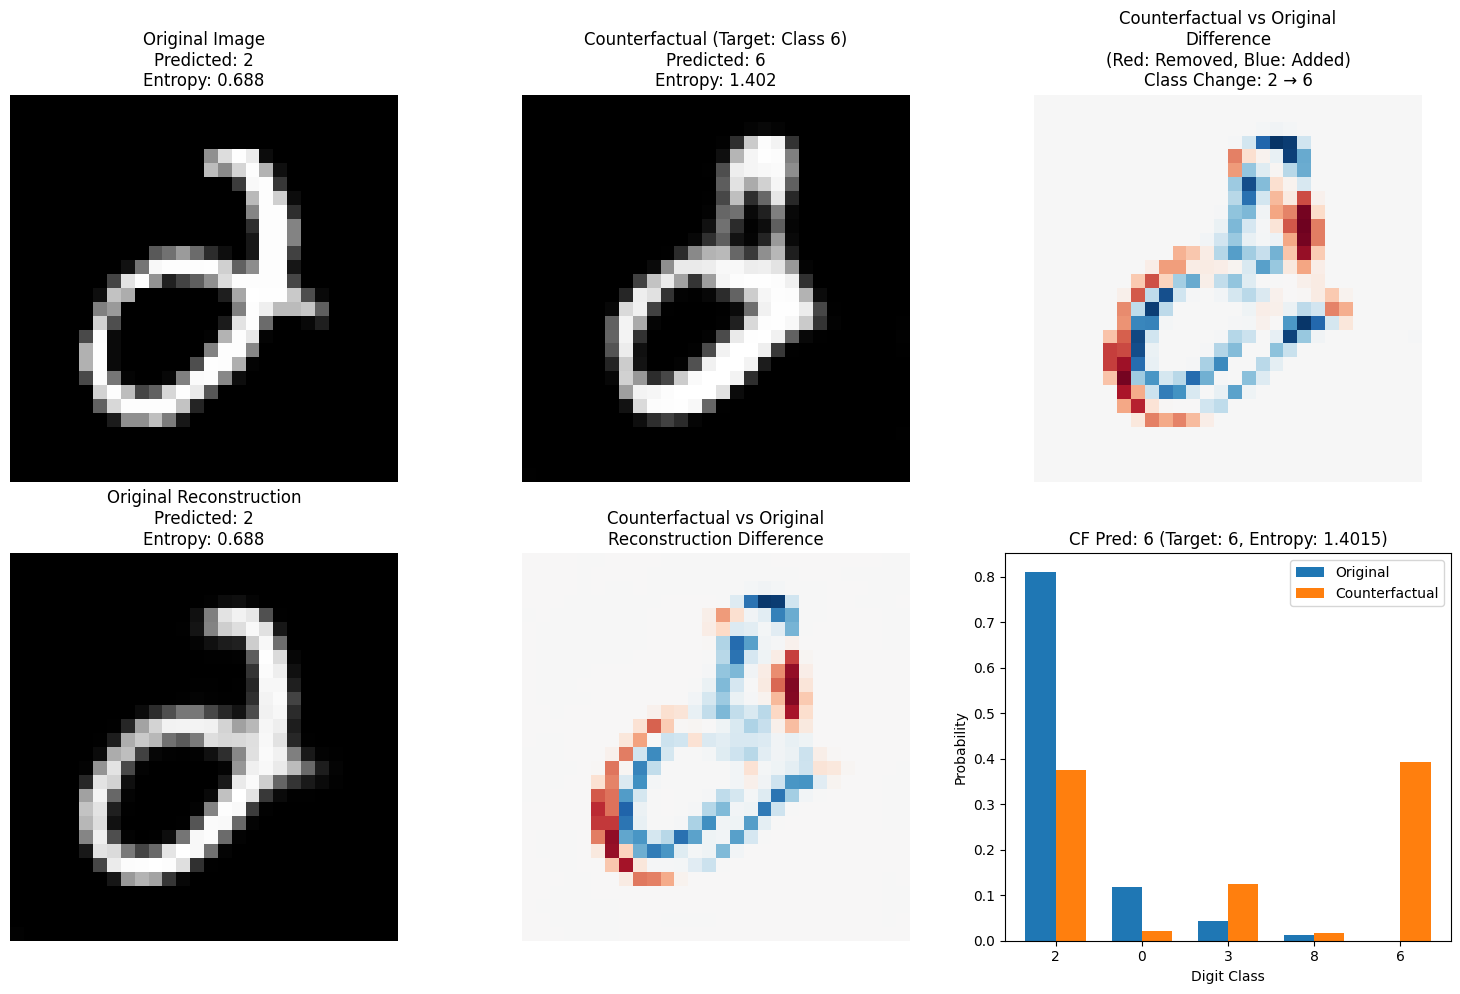

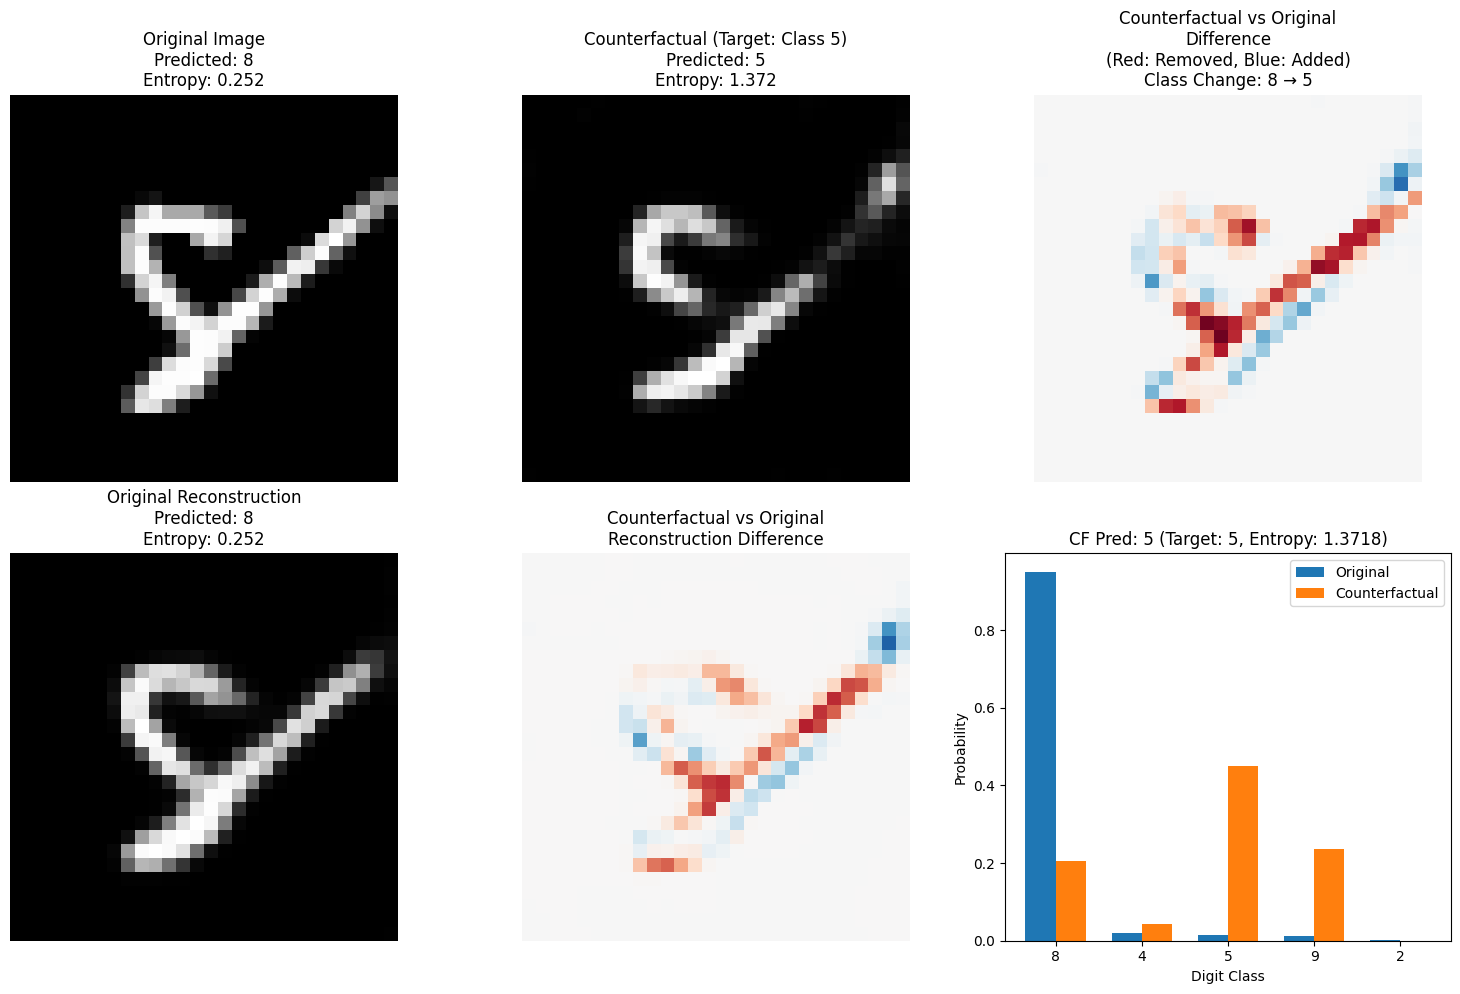

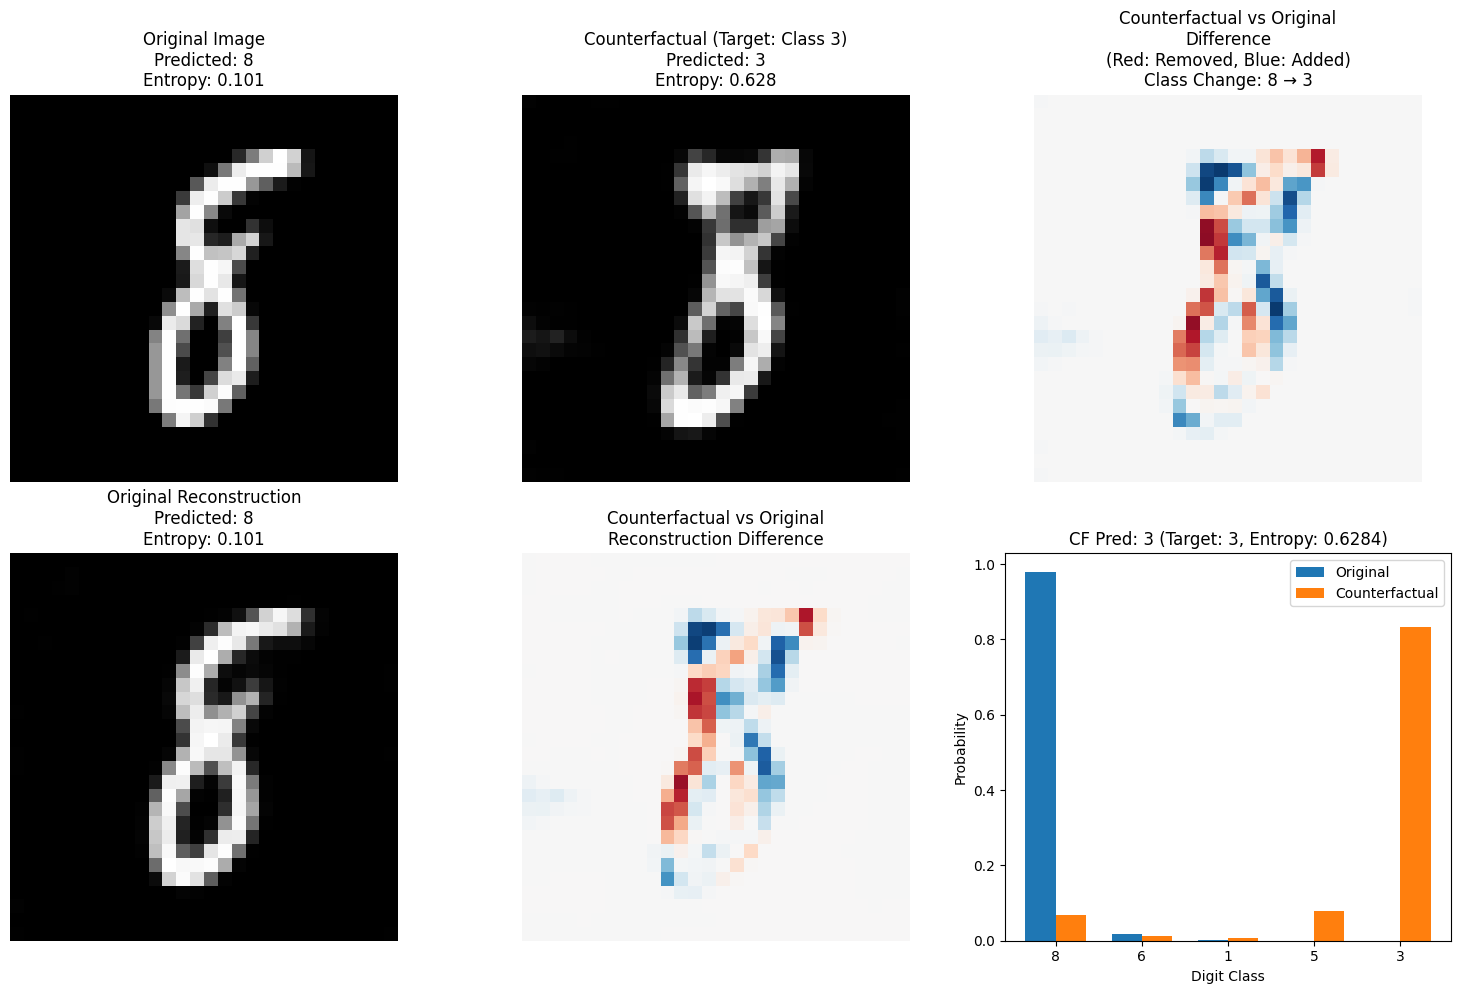

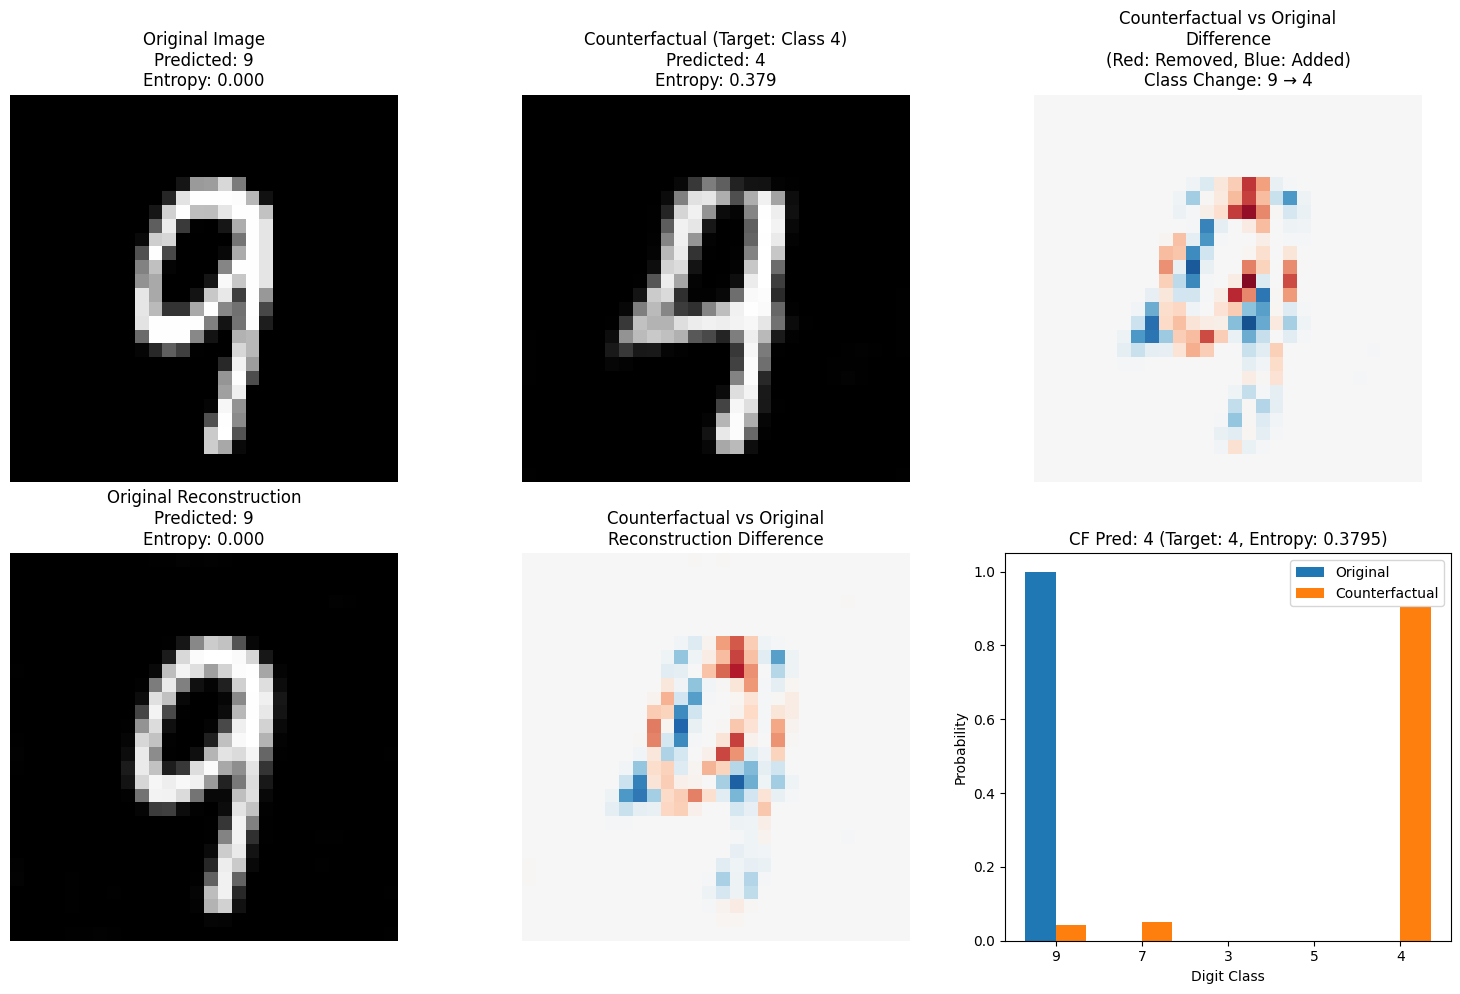

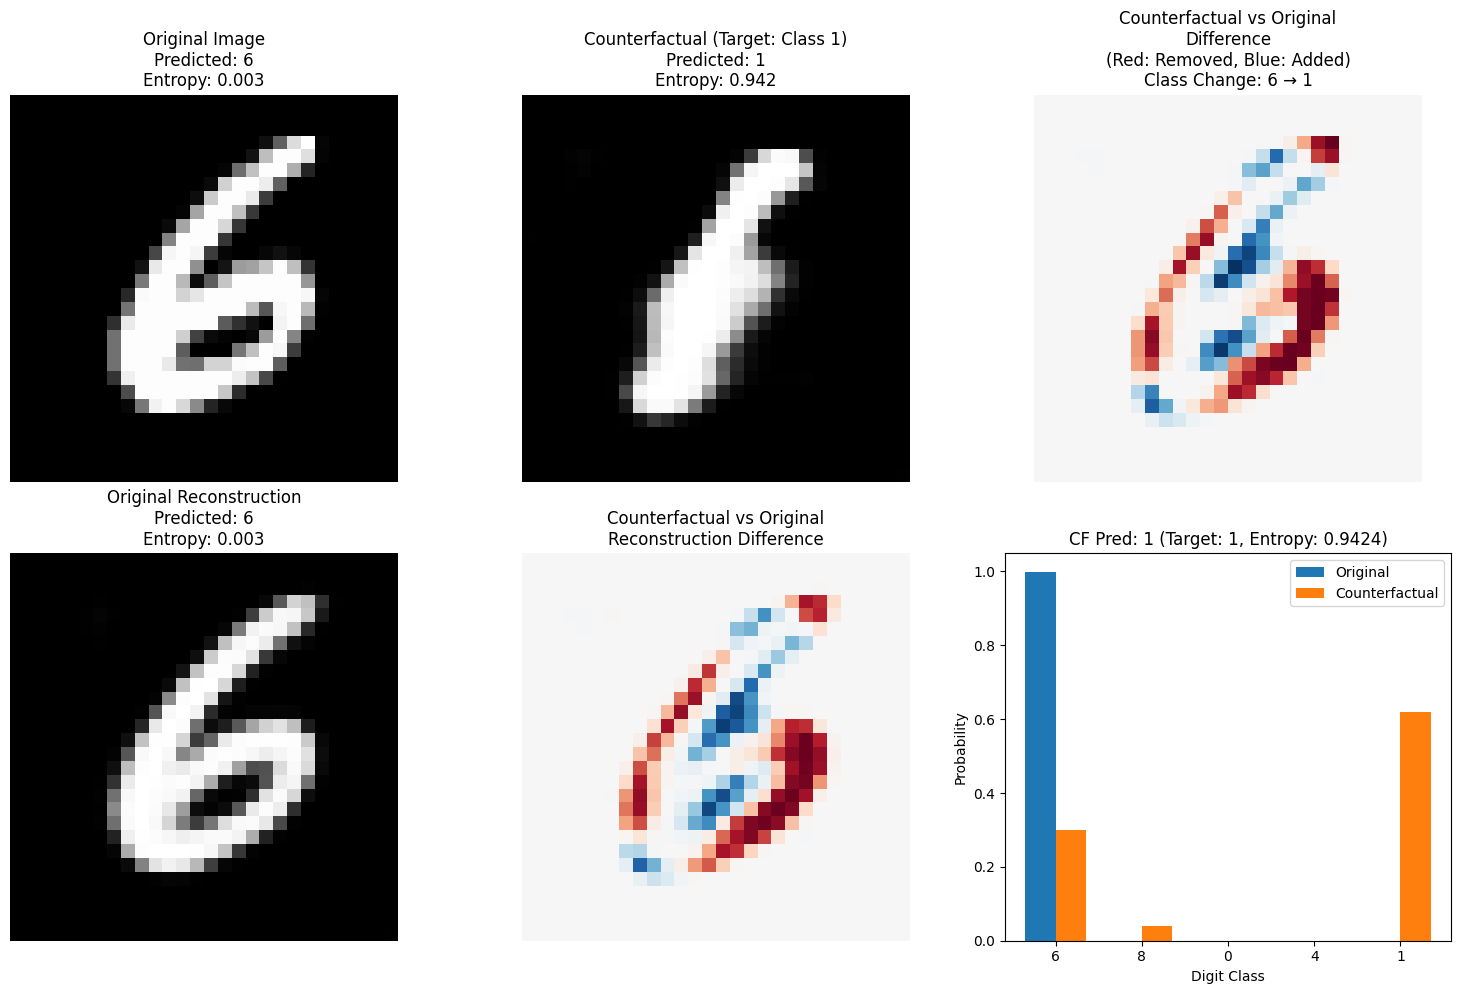

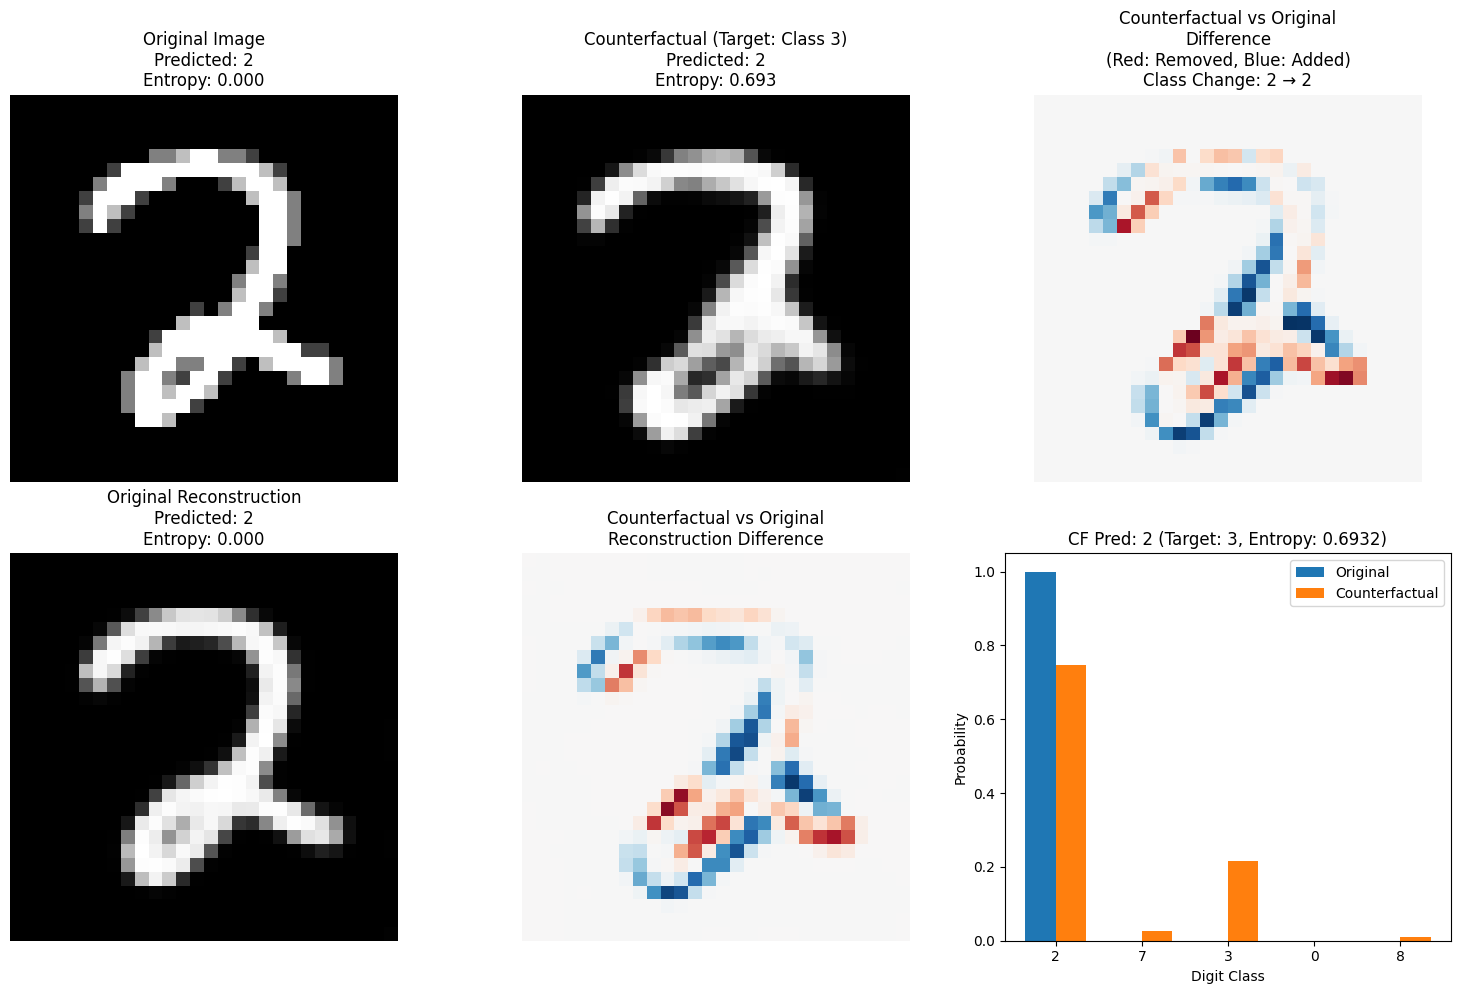

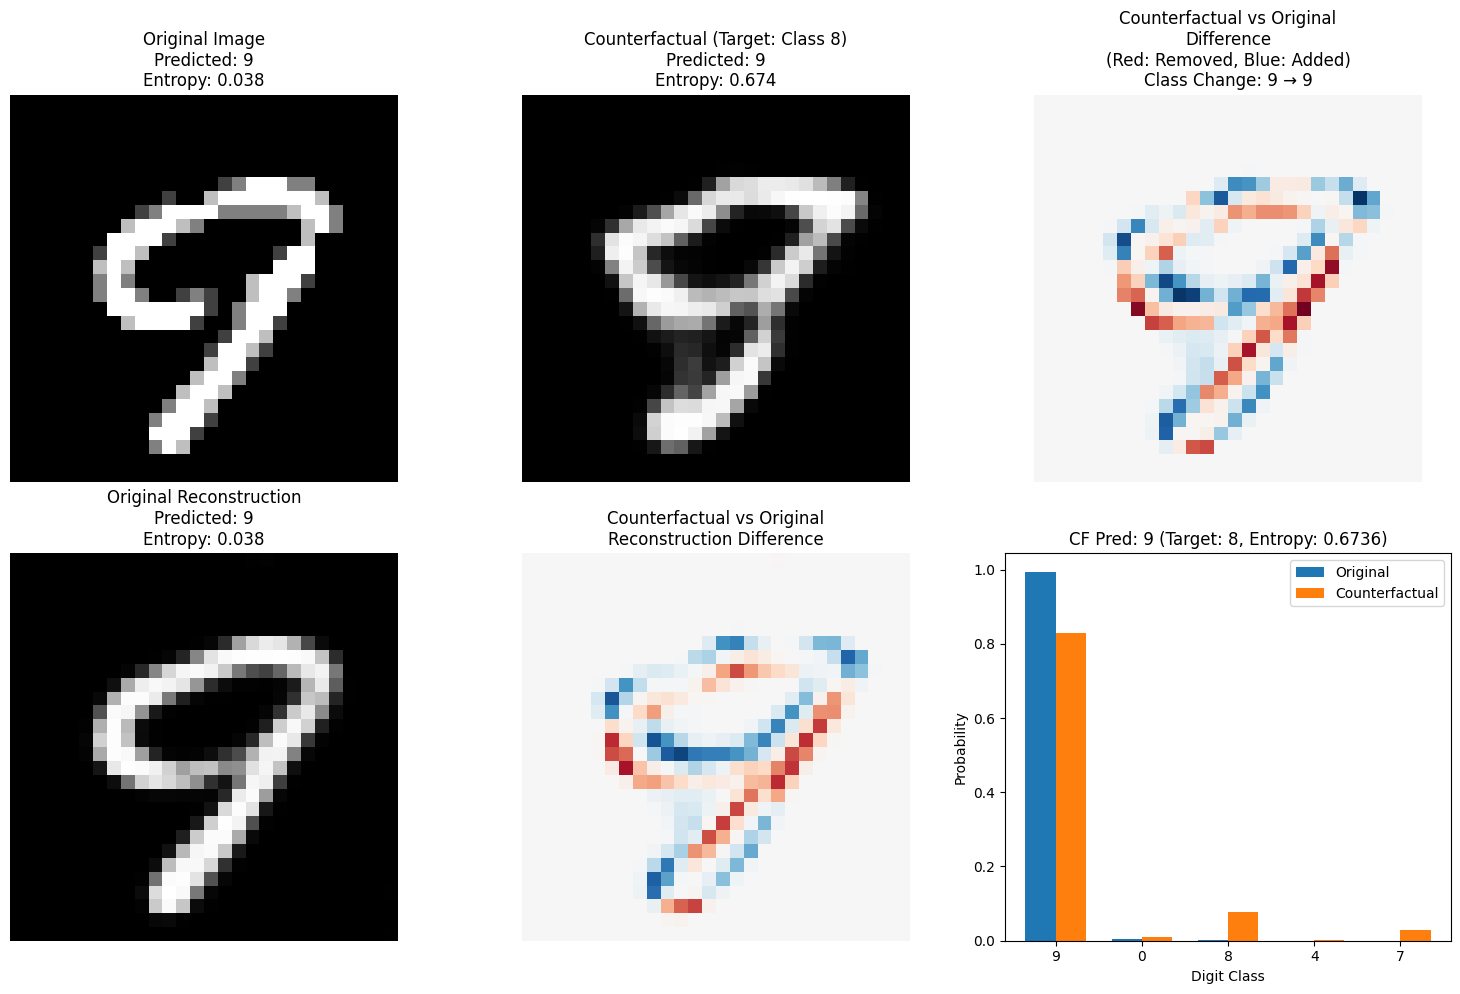

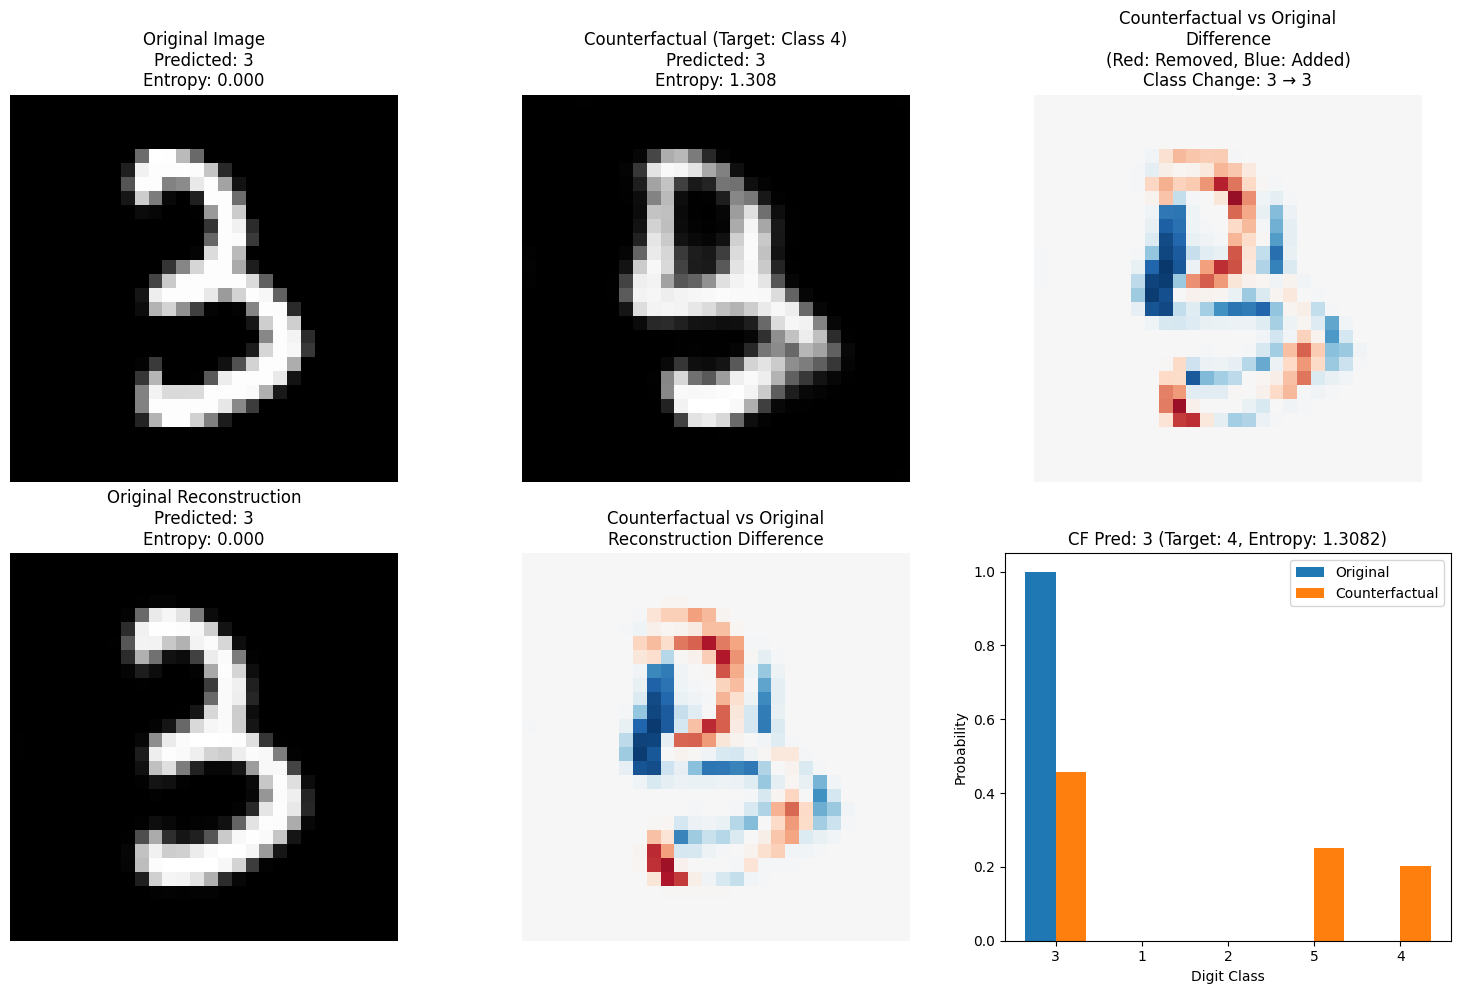

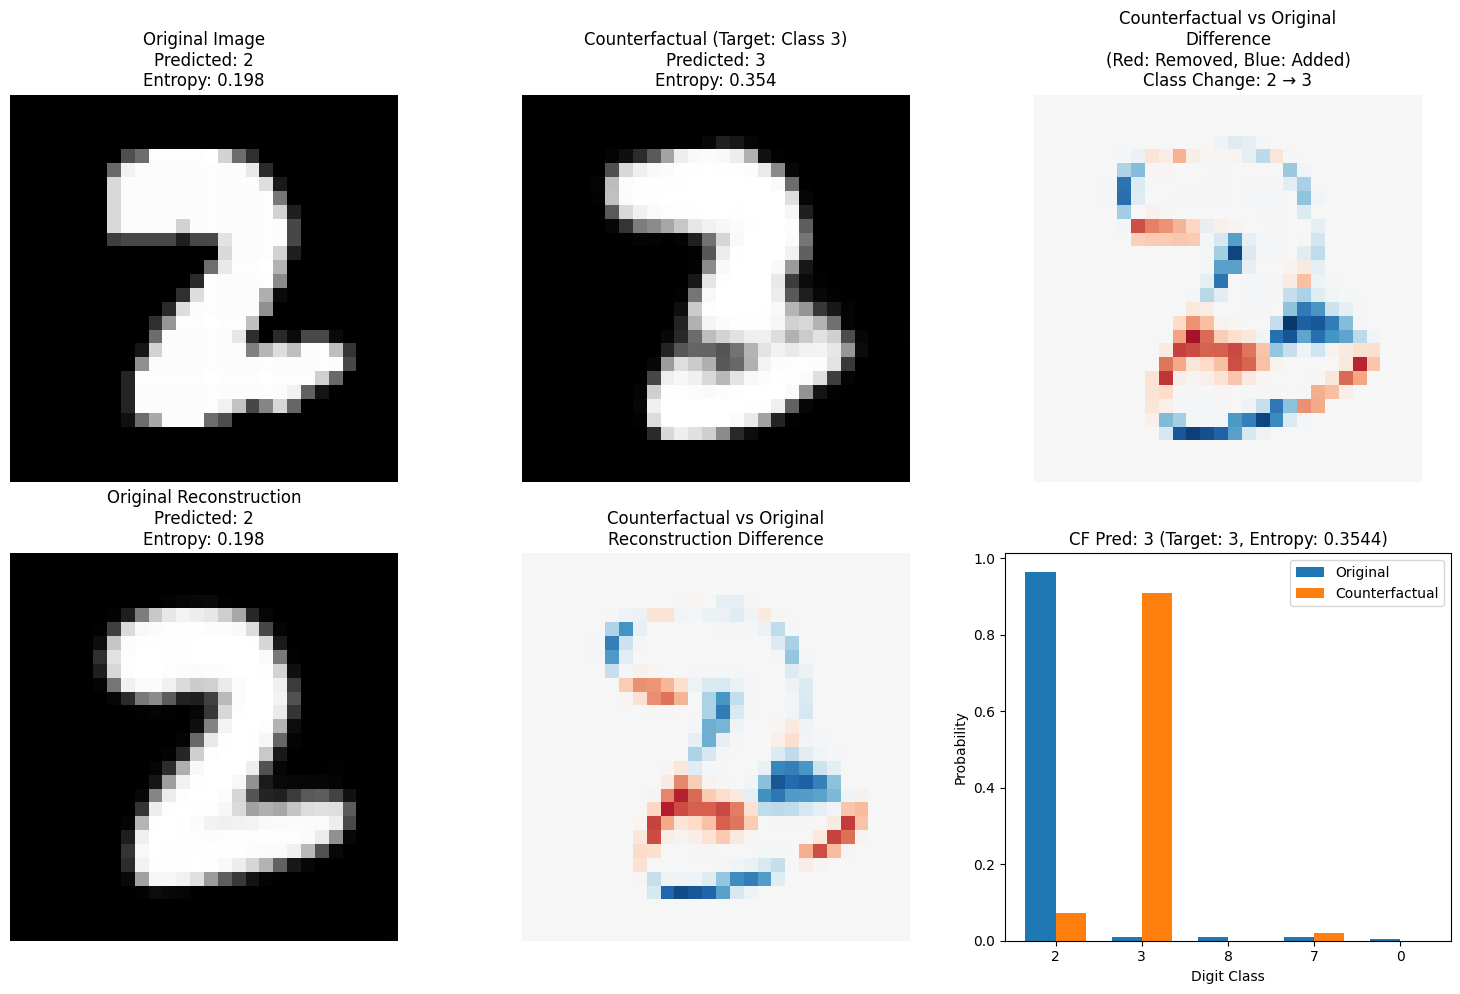

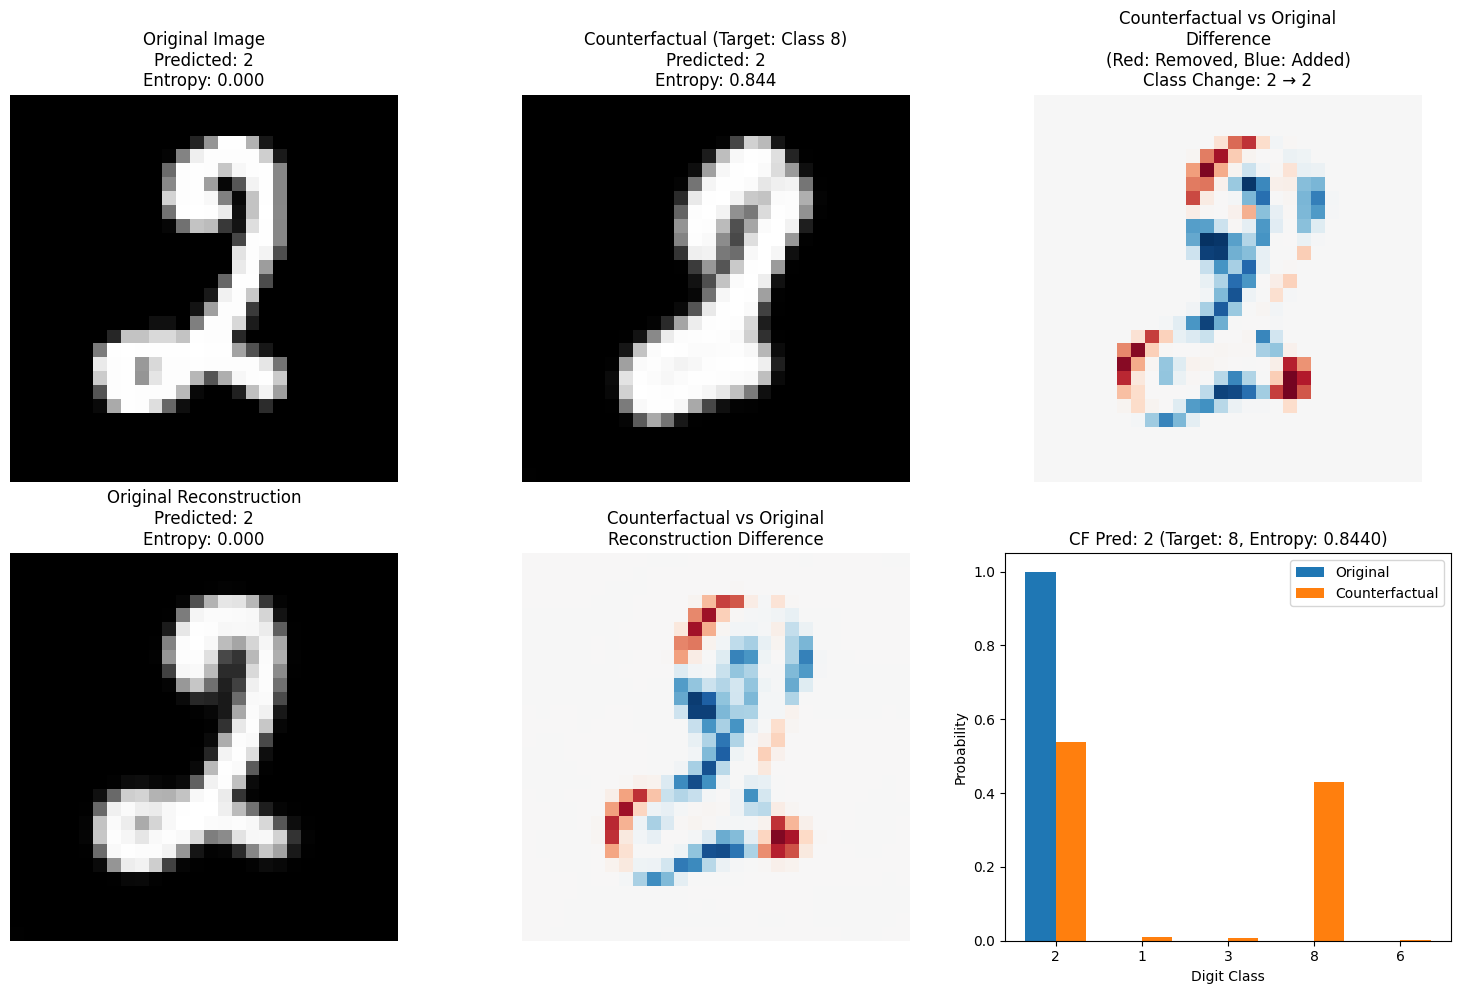

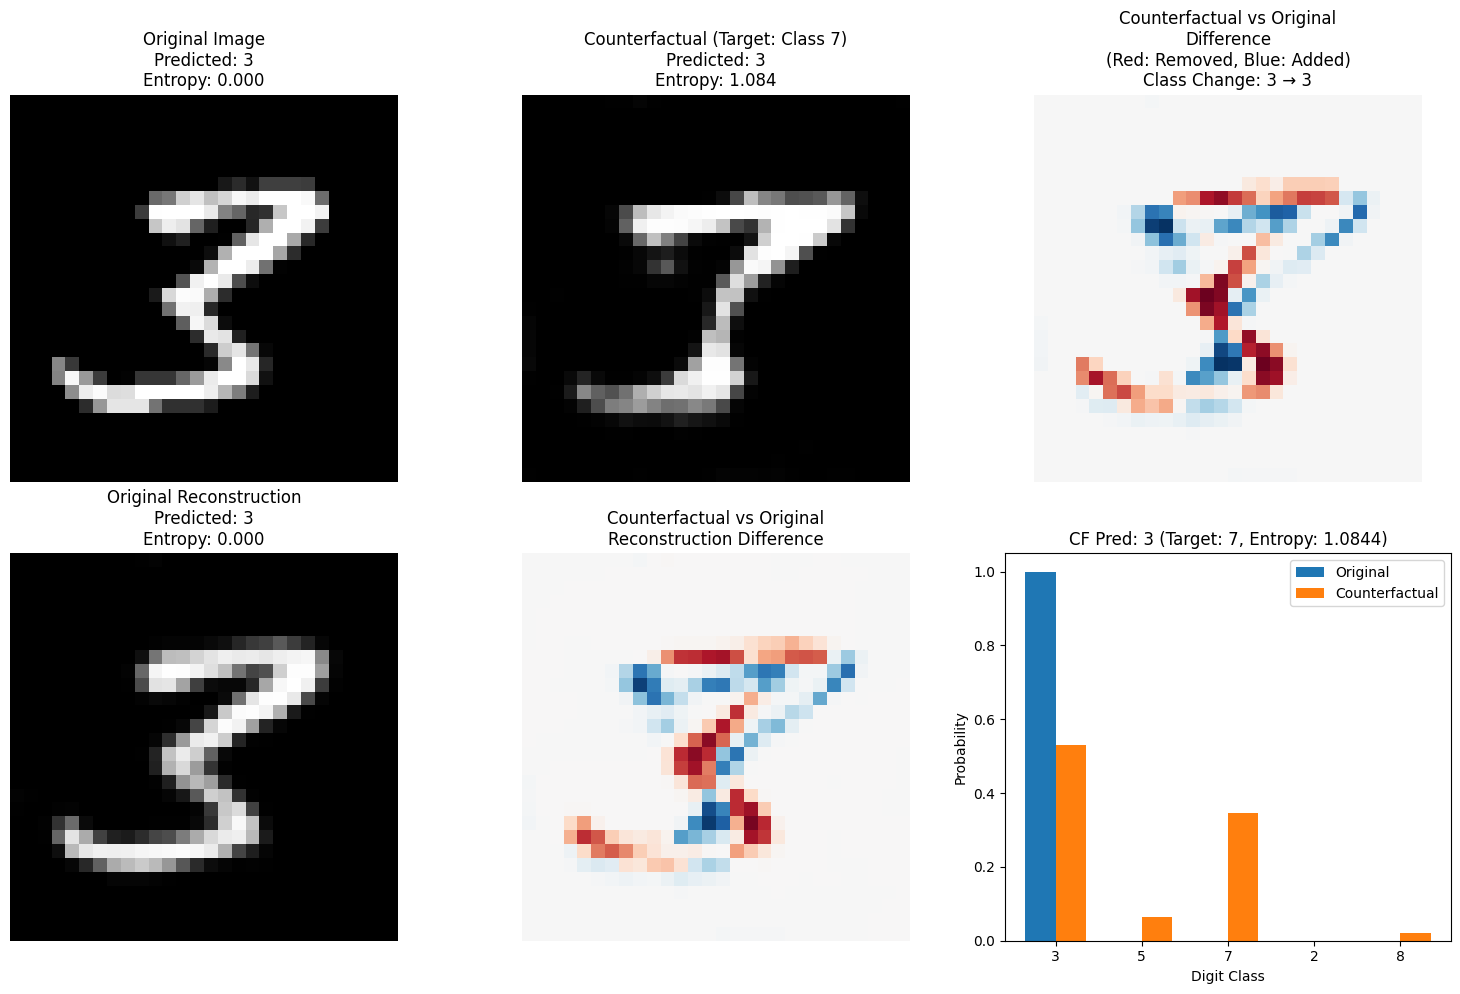

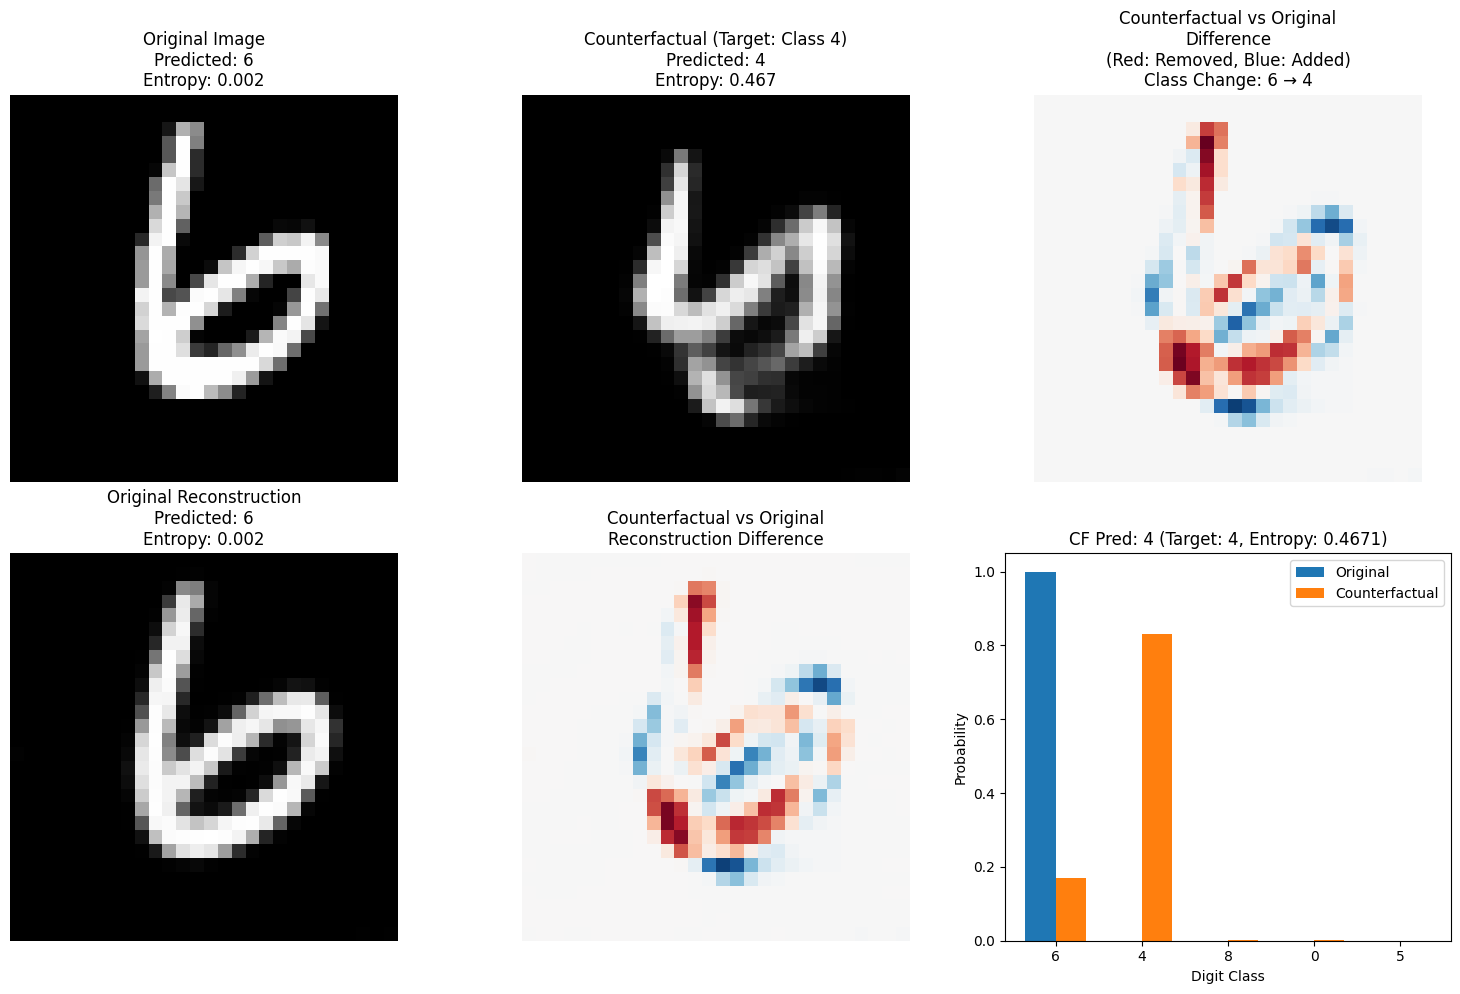

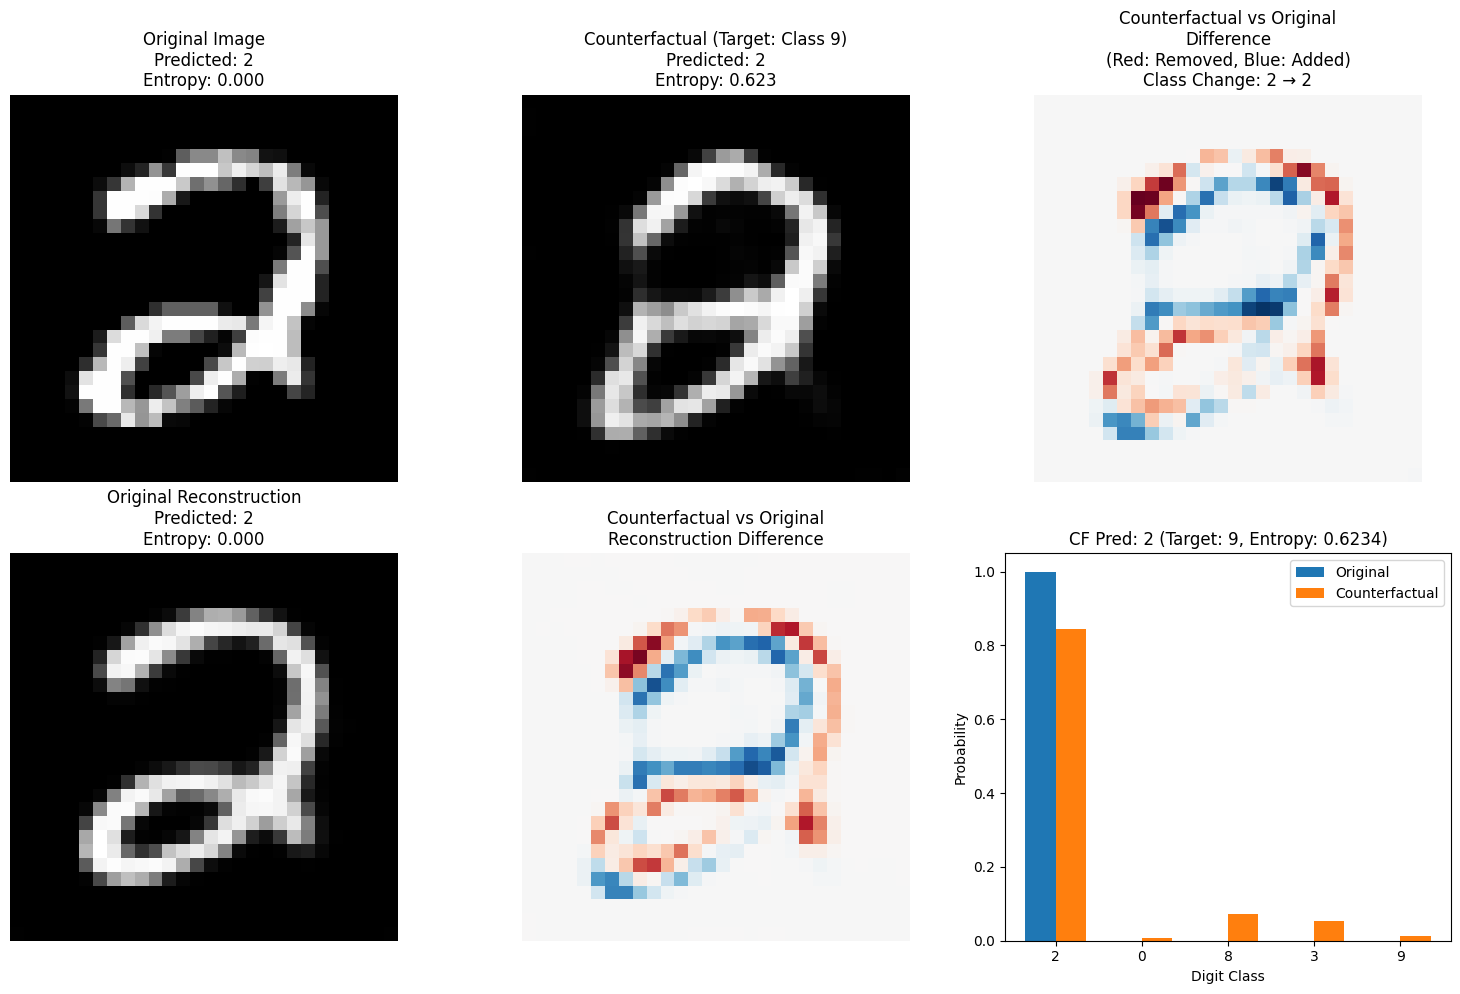

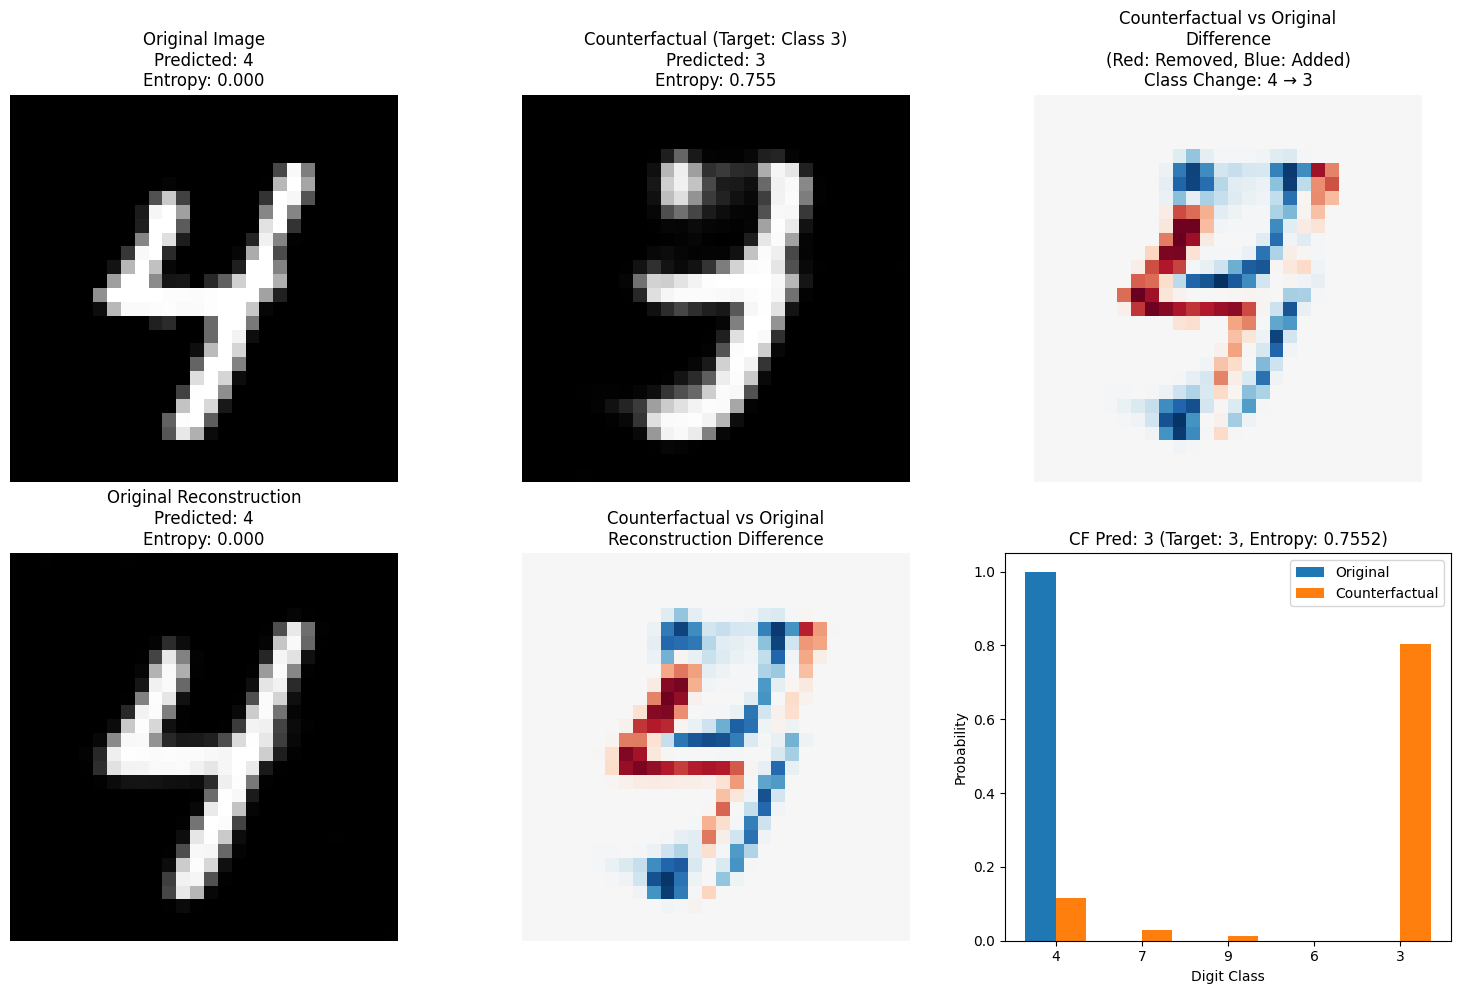

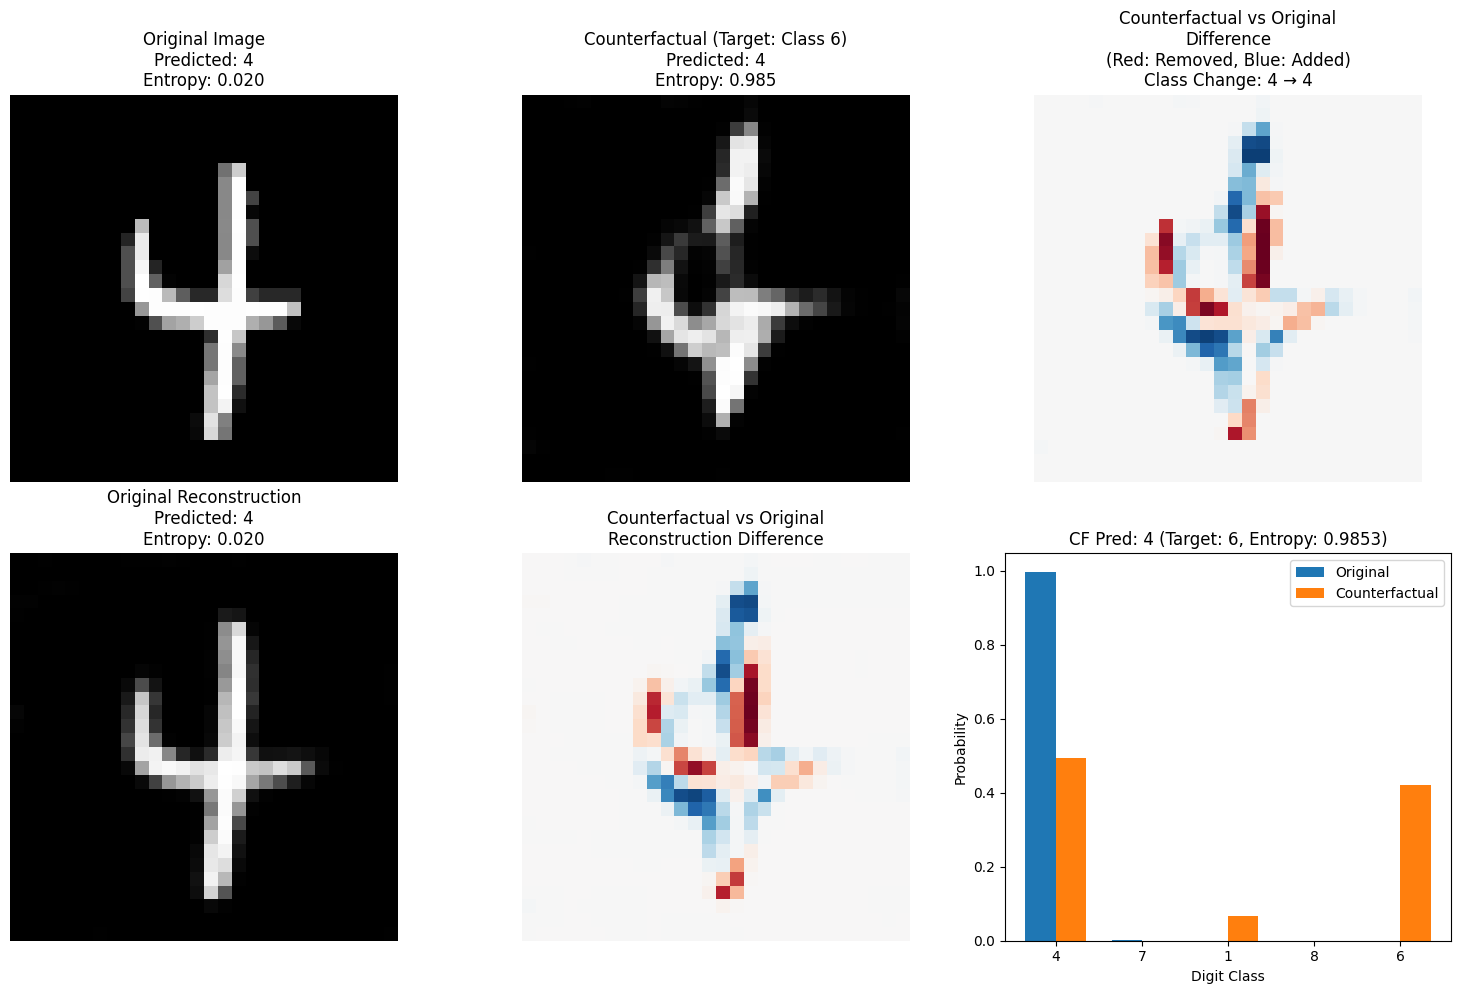

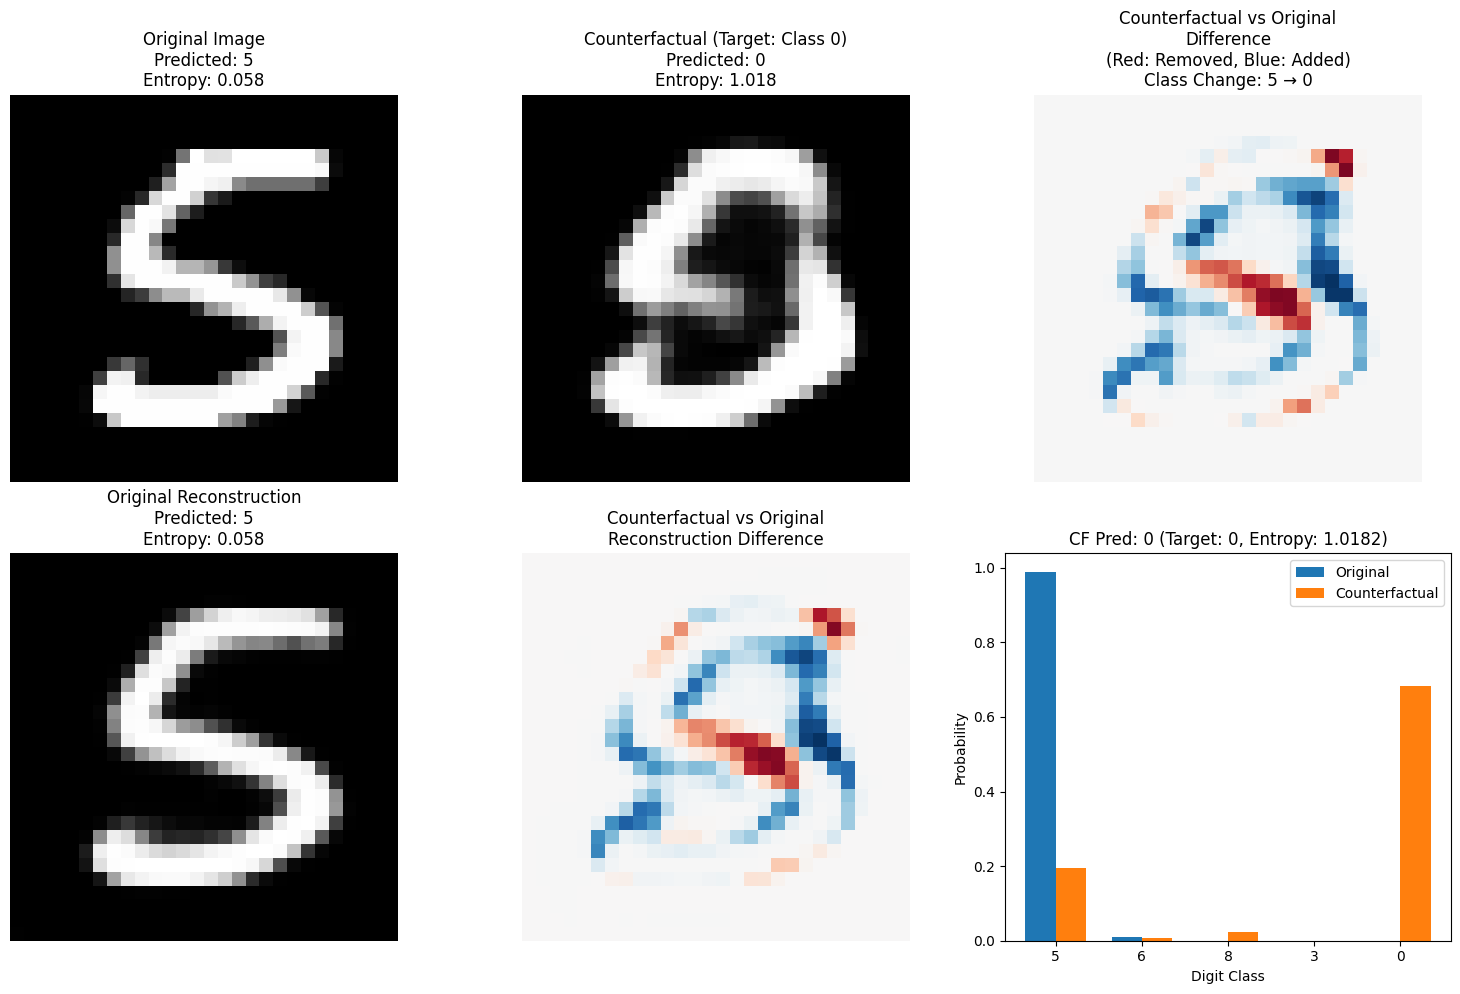

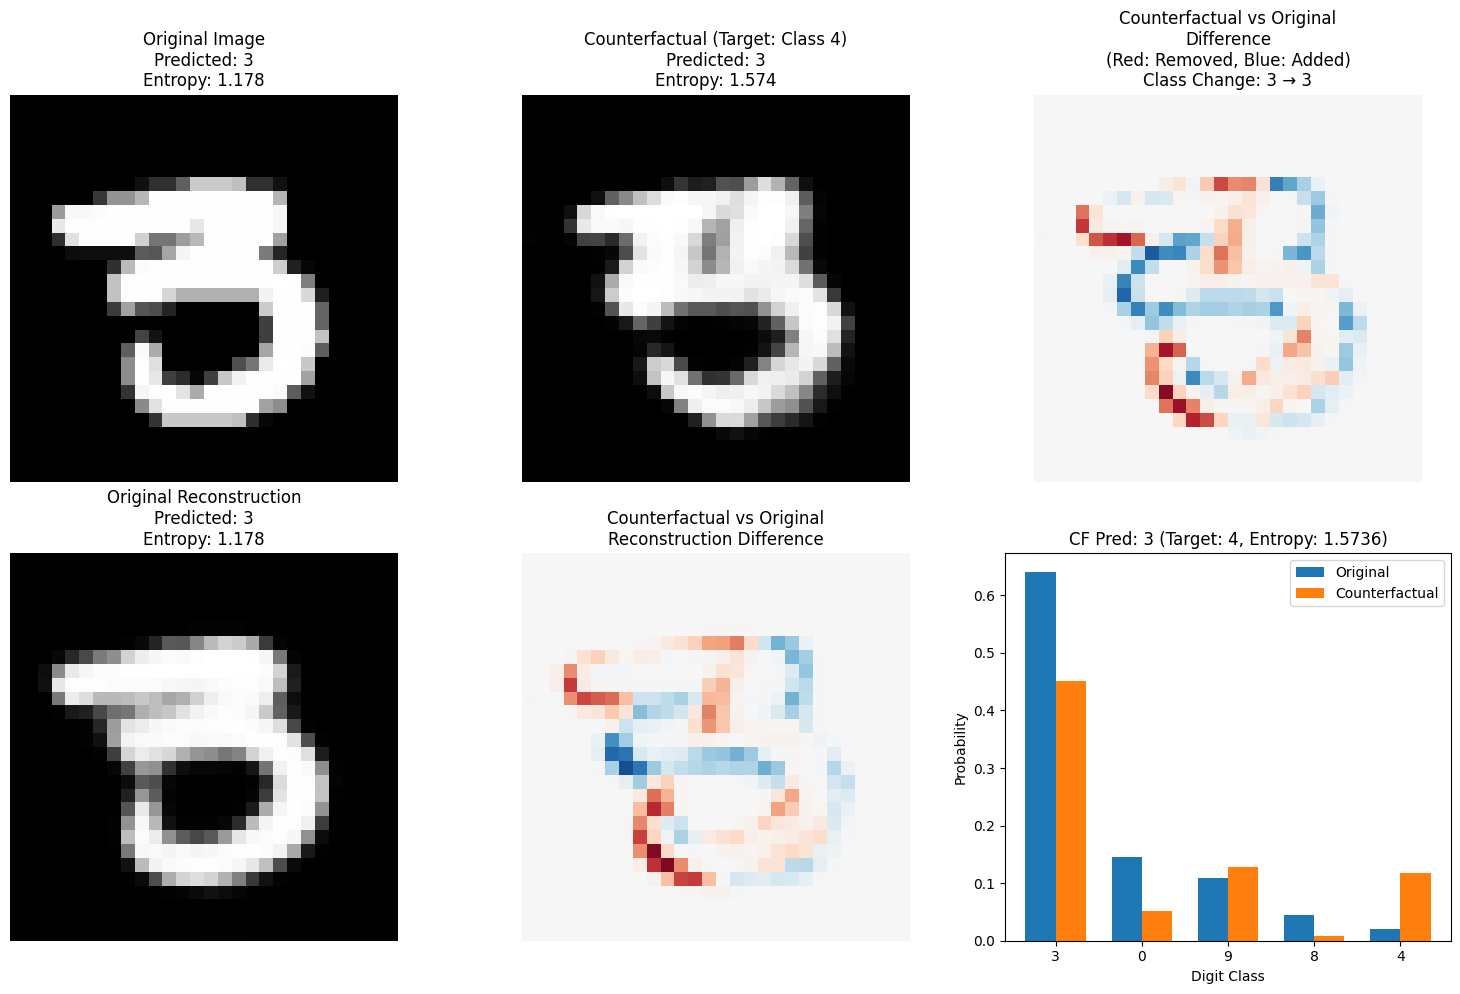

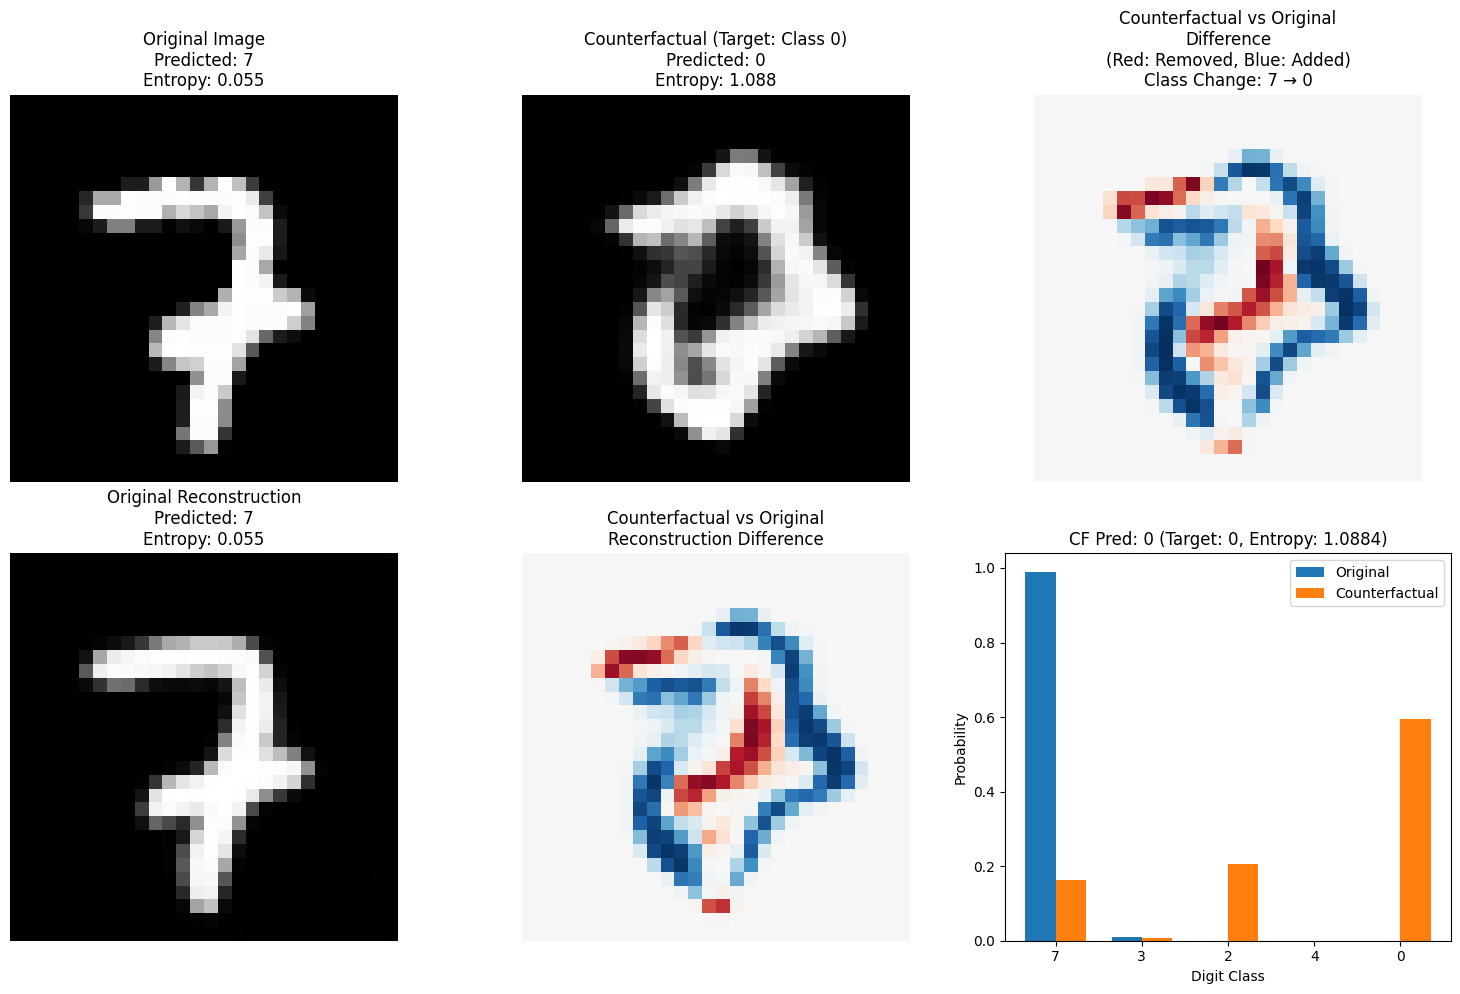

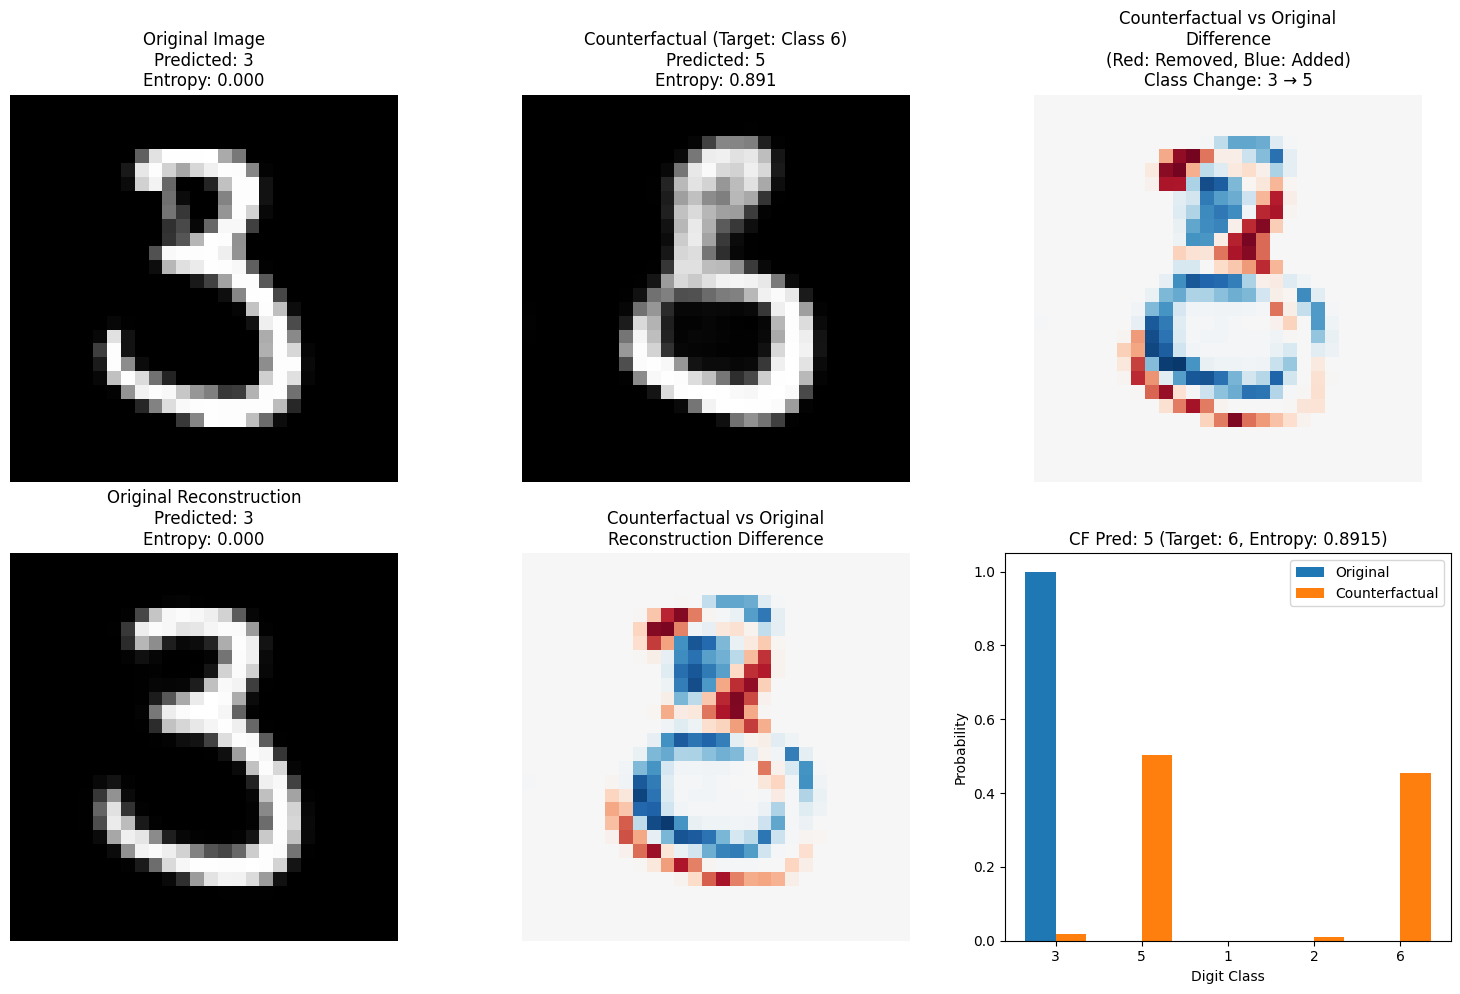

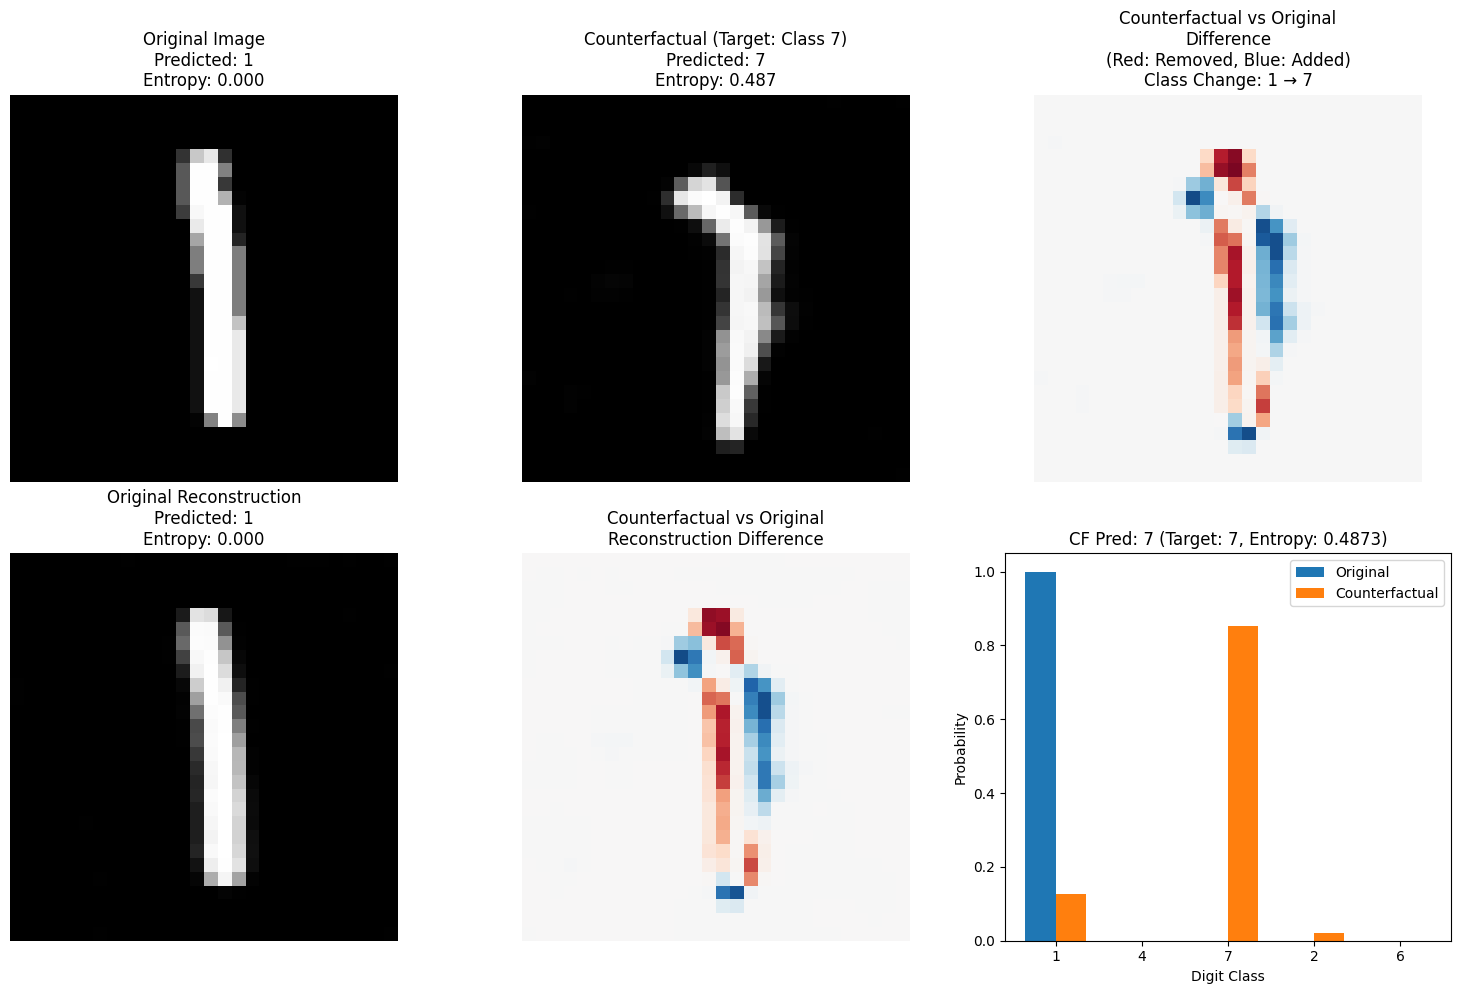

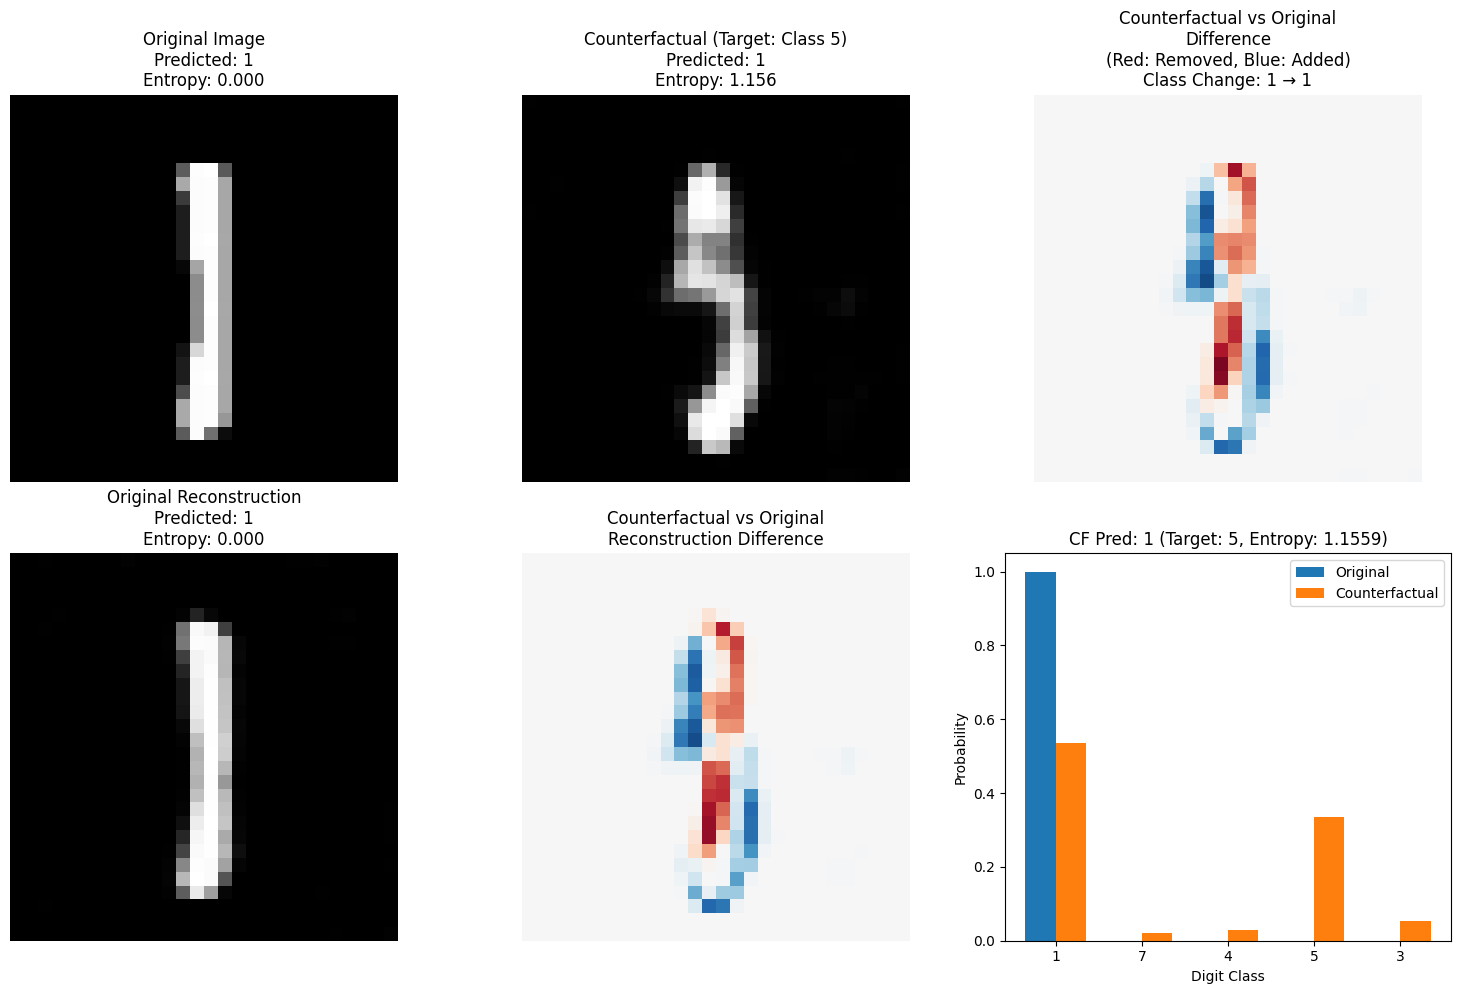

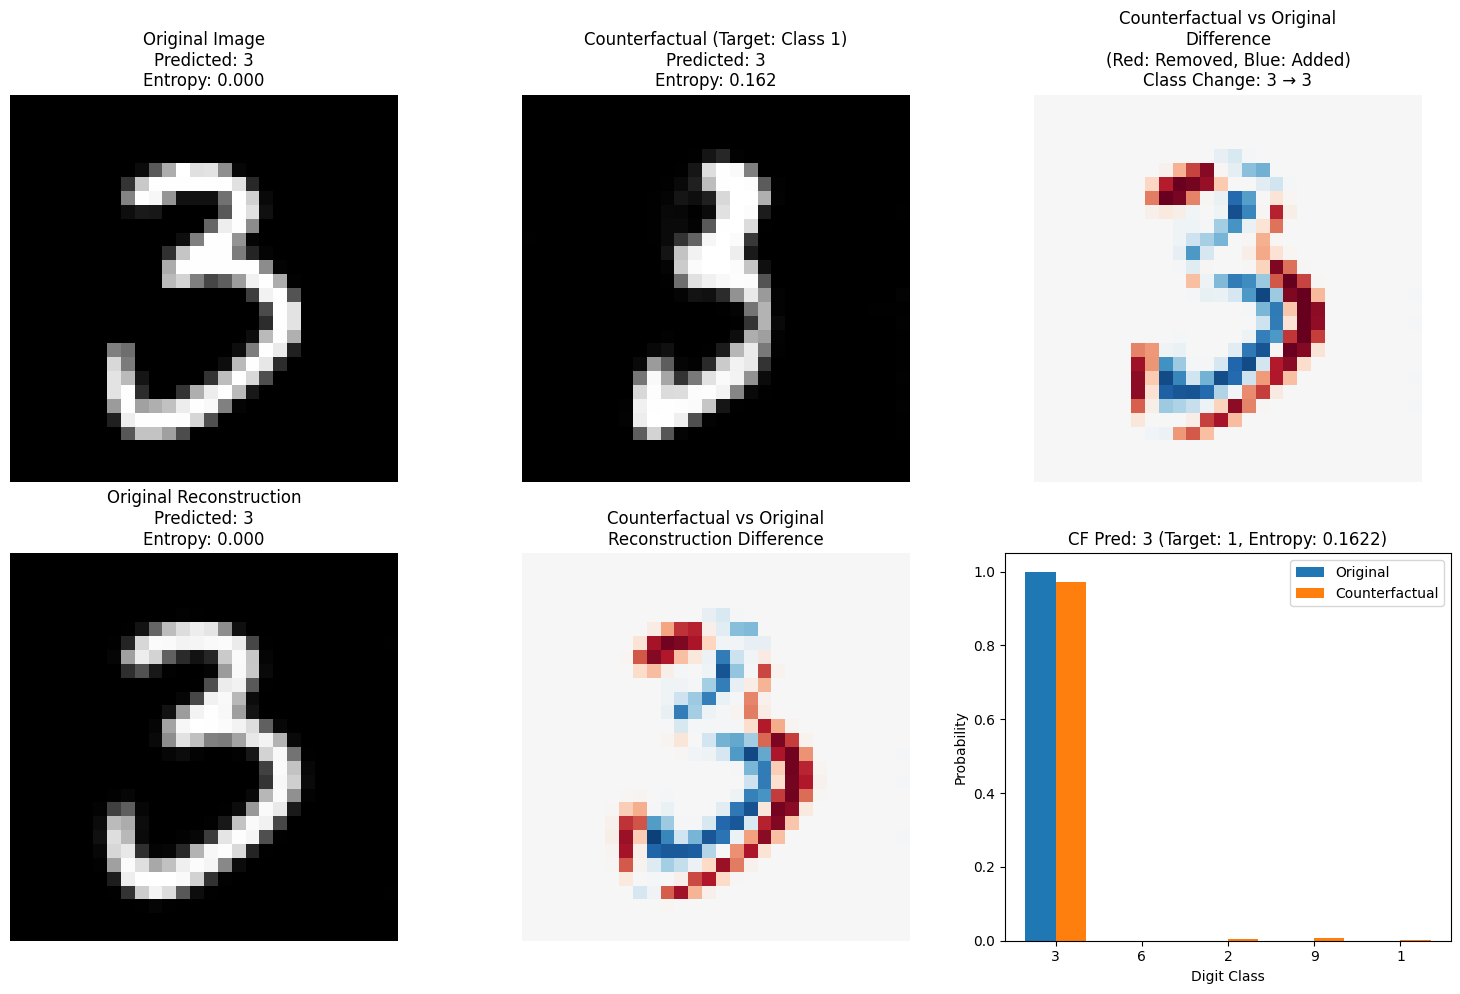

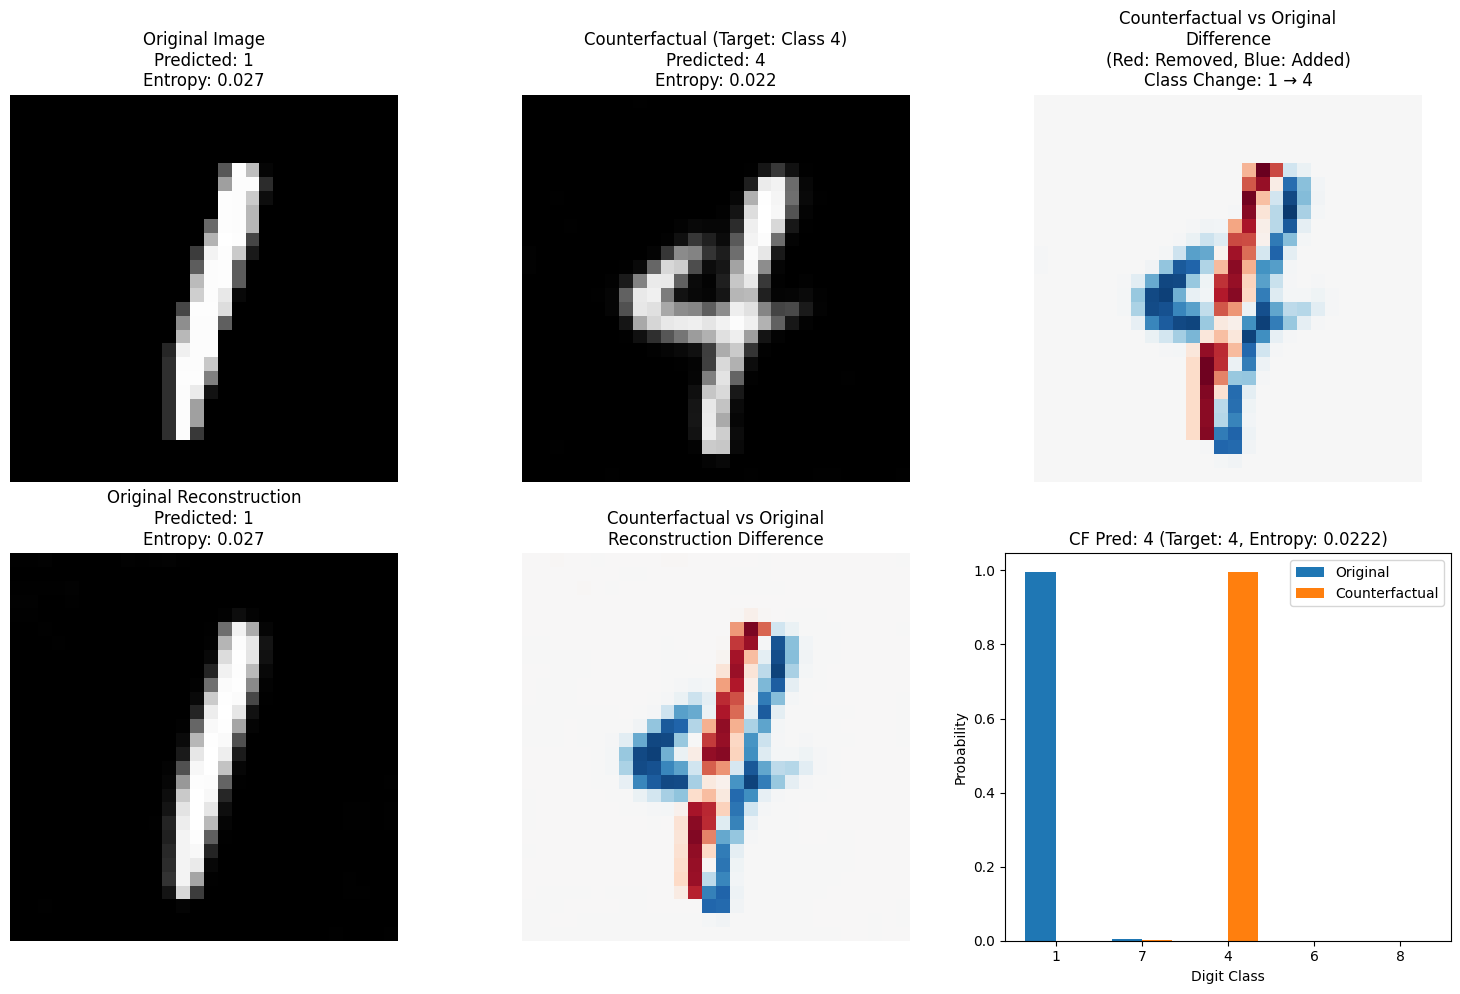

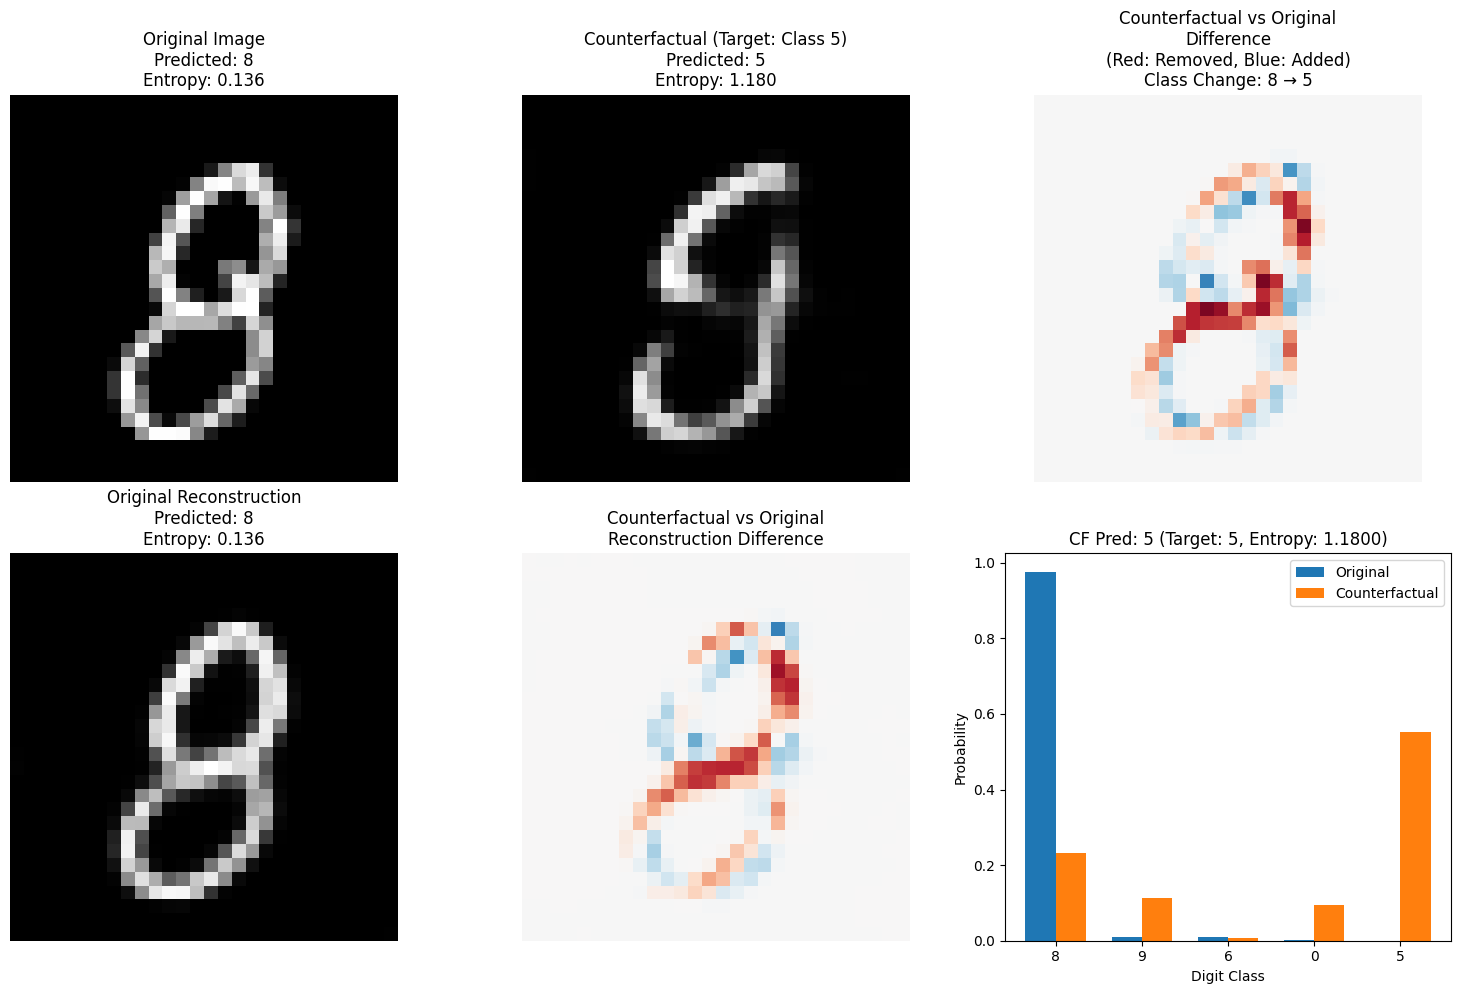

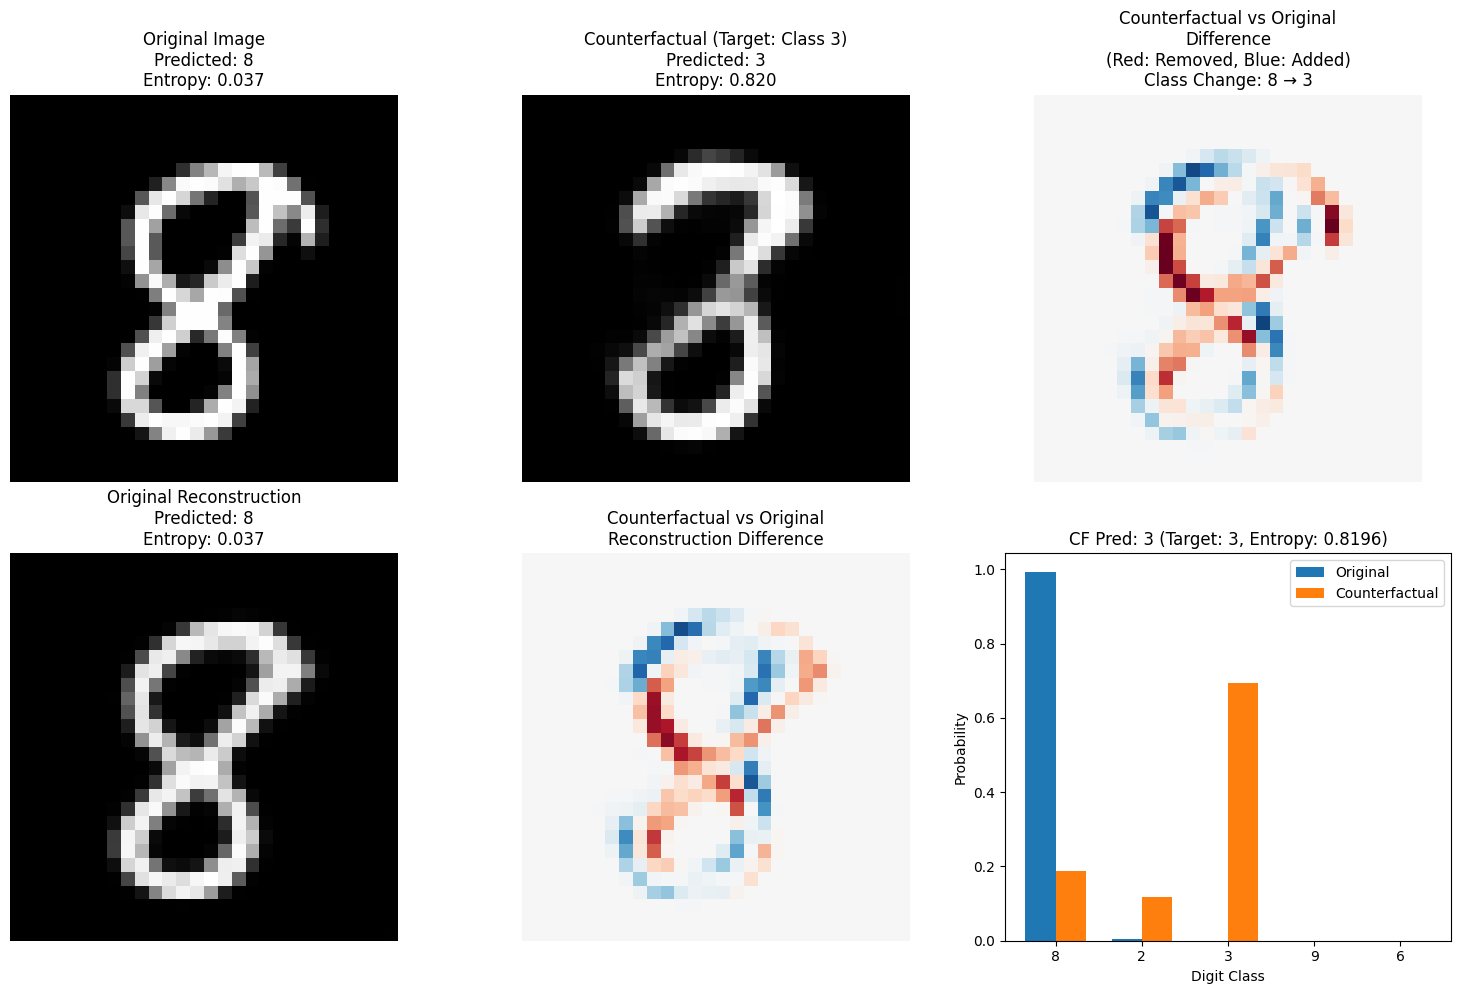

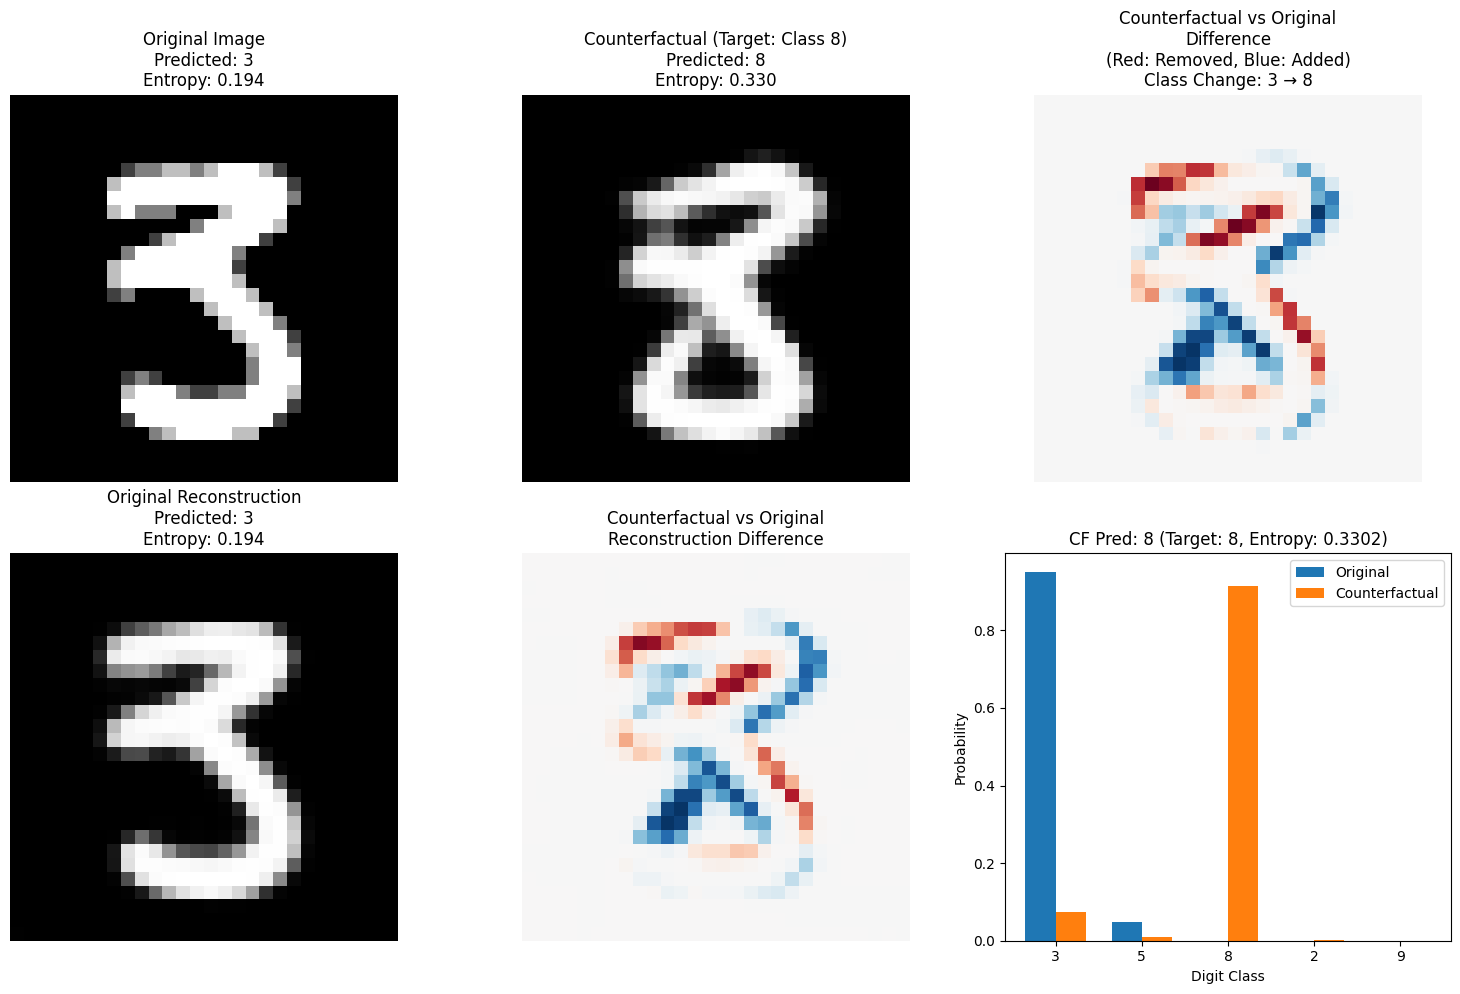

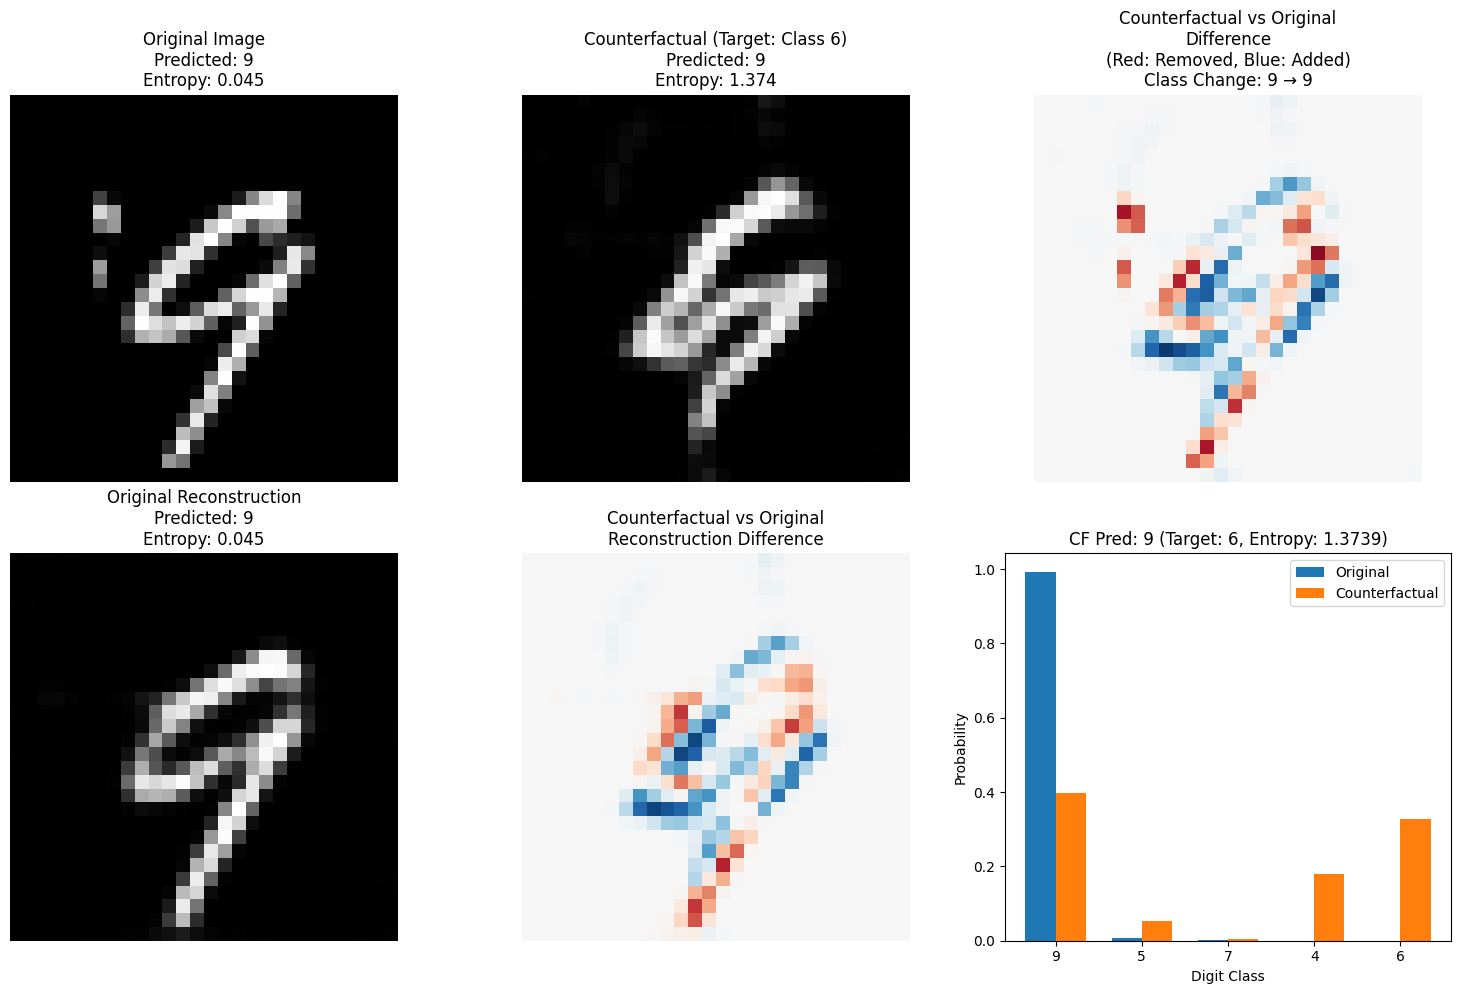

In [117]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import evaluate_class_counterfactuals

bayesian = True
use_auxiliary = False

if bayesian:
    model = bll_vi
else:
    model = backbone

if use_auxiliary:
    ae = autoencoder
else:
    ae = None

results = evaluate_class_counterfactuals(
    random_images,
    model,
    decoder,
    vae,
    device=cfg.device,
    steps=150,
    lr=0.4,
    distance_weight=0.001,
    bayesian=bayesian,
    target_classes=target_labels,
    autoencoder=ae,
    counterfactual_scorer=class_autoencoders
)

In [113]:
avg_realism_score_diff = results['avg_realism_score_difference']
avg_im1_score = results['avg_im1_score']

print(f"Average Realism Score Difference: {avg_realism_score_diff:.6f}")
print(f"Average IM1 Score: {avg_im1_score:.6f}")


Average Realism Score Difference: 0.005442
Average IM1 Score: 14.722184


In [115]:
avg_realism_score_diff = results['avg_realism_score_difference']
avg_im1_score = results['avg_im1_score']

print(f"Average Realism Score Difference: {avg_realism_score_diff:.6f}")
print(f"Average IM1 Score: {avg_im1_score:.6f}")


Average Realism Score Difference: 0.008226
Average IM1 Score: 10.605409



Aggregate Results over 50 images:
Average target class confidence: 0.560
Average latent distance: 27.358
Average log likelihood difference: 18.913
Average realism score difference: 0.008


Example 1 (Image Index: 18):
Target class confidence: 1.000
Latent distance: 48.496
Log likelihood difference: 19.255
Original class prediction: 9
Target class: 4


IndexError: invalid index to scalar variable.

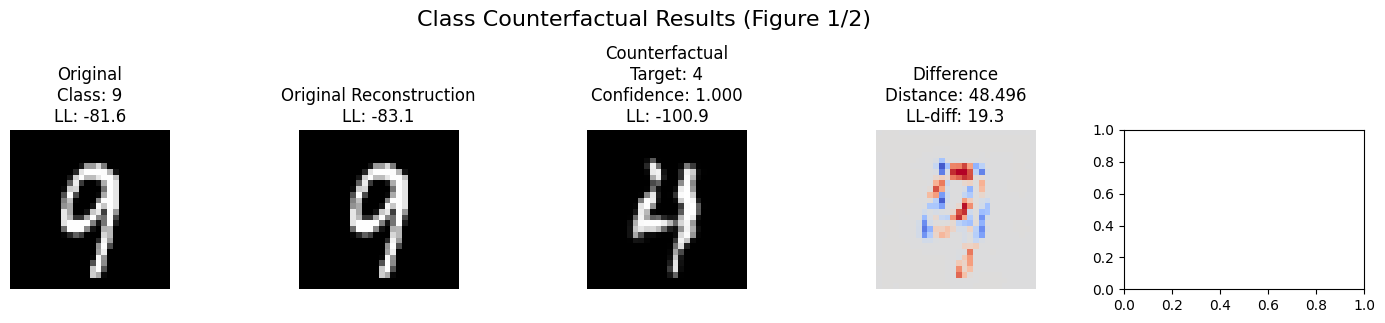

In [103]:
from clue.evaluate_CLUE import visualize_class_counterfactual_results
visualize_class_counterfactual_results(results, n=10)

In [91]:
from clue.evaluate_CLUE import save_class_counterfactual_results_to_csv
save_class_counterfactual_results_to_csv(results, output_dir=results_dir, suffix='test_bayesian_random_images_lower_lr')

Individual results saved to: ../results/new_regene_models/test_bayesian_random_images_lower_lr_2025-03-10_19-14-54/individual_results.csv
Aggregate results saved to: ../results/new_regene_models/test_bayesian_random_images_lower_lr_2025-03-10_19-14-54/aggregate_results.csv


('../results/new_regene_models/test_bayesian_random_images_lower_lr_2025-03-10_19-14-54/individual_results.csv',
 '../results/new_regene_models/test_bayesian_random_images_lower_lr_2025-03-10_19-14-54/aggregate_results.csv')

In [102]:
importlib.reload(clue.evaluate_CLUE)
from clue.evaluate_CLUE import save_class_counterfactual_images
save_class_counterfactual_images(results, output_dir=results_dir)

Saved 50 counterfactual visualizations to ../results/new_regene_models_20250310_202348


['../results/new_regene_models_20250310_202348/counterfactual_001_img0000_target5.png',
 '../results/new_regene_models_20250310_202348/counterfactual_002_img0001_target6.png',
 '../results/new_regene_models_20250310_202348/counterfactual_003_img0002_target4.png',
 '../results/new_regene_models_20250310_202348/counterfactual_004_img0003_target1.png',
 '../results/new_regene_models_20250310_202348/counterfactual_005_img0004_target0.png',
 '../results/new_regene_models_20250310_202348/counterfactual_006_img0005_target3.png',
 '../results/new_regene_models_20250310_202348/counterfactual_007_img0006_target5.png',
 '../results/new_regene_models_20250310_202348/counterfactual_008_img0007_target1.png',
 '../results/new_regene_models_20250310_202348/counterfactual_009_img0008_target4.png',
 '../results/new_regene_models_20250310_202348/counterfactual_010_img0009_target2.png',
 '../results/new_regene_models_20250310_202348/counterfactual_011_img0010_target7.png',
 '../results/new_regene_models_2